# Arvin Baghal Asl - STD ID: 403105793

# Part 1: Book Genre Classification

In this notebook, build a complete text classification pipeline for predicting the genre of a book from its description.

The assignment compares two text representations:

1. **TF-IDF**, which represents descriptions using weighted word counts.
2. **Sentence embeddings**, which represent descriptions using dense semantic vectors from the `description_emb` column.

You will train and compare several classifiers:

- **Naive Bayes**
- **k-Nearest Neighbors**
- **Logistic Regression**
- **Multi-Layer Perceptron**

The notebook also studies class imbalance. First, train a baseline model. Then test different imbalance-handling strategies and choose the best one using the development set. Use the selected strategy for the remaining experiments.

The final model is evaluated only once on the test set. Analyze its behavior using model comparison plots, a confusion matrix, per-class scores, and error examples.

## 0. Setup

Run the setup cell before starting the assignment. Scikit-learn is installed only because PCA is used for visualization. Do not use scikit-learn classifiers, vectorizers, scalers, splitters, or metrics in this assignment.

In [1]:
!pip install -q pandas numpy scipy scikit-learn matplotlib tqdm


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import ast
import json
import math
import re
import time
import warnings
from collections import Counter, defaultdict
import gdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

from IPython.display import display
from tqdm.auto import tqdm


from sklearn.decomposition import PCA

tqdm.pandas()
warnings.filterwarnings("ignore")

# Dataset
This is the dataset you worked with in Phase 1.
Each row in the dataset represents one book. The main fields used in this assignment are:

- `description`: the text used for classification.
- `genres`: the source of the target label.
- `description_emb`: a precomputed embedding of the description.

The `description_emb` column was added before this notebook using `BAAI/bge-large-en-v1.5`. This model creates 1024-dimensional dense vectors designed to capture semantic similarity between texts.


### Run this cell if you are using colab to download the dataset automatically

In [ ]:
url = "https://drive.google.com/file/d/1KGPZ7lKkxkPR4azBRLxEoG7ngo8EXrDC/view?usp=drive_link"
output = "books.csv"

gdown.download(url, output, quiet=False, fuzzy=True)

## 1. Configuration

Set the input and output paths. The input CSV must already contain a `description_emb` column.

In [3]:
# =========================
# File paths
# =========================
CSV_PATH = "books_with_description_emb.csv"
OUTPUT_DEV_RESULTS_CSV = "classification_dev_results.csv"
OUTPUT_TEST_RESULTS_CSV = "classification_test_results.csv"
OUTPUT_TEST_PREDICTIONS_CSV = "classification_test_predictions.csv"

# =========================
# Column names
# =========================
DESCRIPTION_COLUMN = "description"
EMBEDDING_COLUMN = "description_emb"
GENRES_COLUMN = "genres"
TITLE_COLUMN = "title"

# =========================
# Dataset settings
# =========================
RANDOM_STATE = 42
TOP_N_CLASSES = 10
MIN_SAMPLES_PER_CLASS = 100

# Keep the test set untouched until final evaluation.
TRAIN_SIZE = 0.70
DEV_SIZE = 0.15
TEST_SIZE = 0.15

# =========================
# TF-IDF settings
# =========================
MAX_TFIDF_FEATURES = 5000
NGRAM_RANGE = (1, 2)
MIN_DF = 2
MAX_DF = 0.8

# =========================
# Scratch model settings
# =========================
KNN_NEIGHBORS = 5

LR_MAX_EPOCHS = 100
LR_IMBALANCE_EPOCHS = 80
LR_LEARNING_RATE = 0.5
LR_BATCH_SIZE = 256
LR_ALPHA = 1e-4

# MLPs need dense input. For TF-IDF, select a compact subset of TF-IDF features first.
DENSE_TFIDF_FEATURES_FOR_MLP = 3000
MLP_HIDDEN_DIM = 128                
MLP_MAX_EPOCHS = 50                 
MLP_LEARNING_RATE = 0.01            
MLP_BATCH_SIZE = 128                 
MLP_ALPHA = 1e-4

# =========================
# Imbalance handling settings
# =========================
IMBALANCE_STRATEGIES = [
    "none",               # baseline: keep the original training distribution
    "random_oversample",  # duplicate minority-class rows until all classes match the largest class
    "random_undersample", # sample majority-class rows down to the smallest class
    "median_resample",    # move every class toward the median class size
]

# =========================
# Visualization settings
# =========================
MAX_POINTS_FOR_PCA_PLOT = 3000
FIG_DPI = 140

## 2. Visualization utilities

Use the following plotting helpers throughout the notebook. Do not change them unless you want to improve the visual design consistently across all plots.

In [4]:
def set_research_plot_style():
    # Use a clean, publication-friendly style while keeping Matplotlib defaults for colors.
    plt.rcParams.update({
        "figure.dpi": FIG_DPI,
        "savefig.dpi": FIG_DPI,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.8,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
    })


set_research_plot_style()


def add_value_labels_to_bars(ax, fmt="{:.3f}", padding=3, fontsize=8):
    for container in ax.containers:
        labels = []
        for bar in container:
            value = bar.get_height()
            if np.isnan(value):
                labels.append("")
            elif abs(value) >= 100:
                labels.append(f"{value:,.0f}")
            else:
                labels.append(fmt.format(value))
        ax.bar_label(container, labels=labels, padding=padding, fontsize=fontsize)


def plot_horizontal_count_distribution(counts, title, xlabel="Number of examples", show_percent=True):
    counts = pd.Series(counts).sort_values(ascending=True)
    total = counts.sum()

    fig_height = max(4.5, 0.42 * len(counts) + 1.5)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    bars = ax.barh(counts.index.astype(str), counts.values)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Class")
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

    x_max = counts.max() if len(counts) else 1
    ax.set_xlim(0, x_max * 1.18)

    for bar, value in zip(bars, counts.values):
        if show_percent and total > 0:
            label = f"{value:,}  ({value / total:.1%})"
        else:
            label = f"{value:,}"
        ax.text(
            bar.get_width() + x_max * 0.015,
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()


def plot_grouped_metric_bars(df_plot, category_col, metric_cols, title, ylabel, sort_by=None, rotation=45):
    plot_df = df_plot.copy()
    if sort_by is not None:
        plot_df = plot_df.sort_values(sort_by, ascending=False).reset_index(drop=True)

    labels = plot_df[category_col].astype(str).tolist()
    x = np.arange(len(labels))
    width = 0.78 / max(1, len(metric_cols))

    fig_width = max(11, 0.65 * len(labels) + 4)
    fig, ax = plt.subplots(figsize=(fig_width, 5.8))

    for i, metric in enumerate(metric_cols):
        offset = (i - (len(metric_cols) - 1) / 2) * width
        ax.bar(x + offset, plot_df[metric].astype(float).values, width, label=metric)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=rotation, ha="right")
    ax.set_ylim(0, min(1.05, max(0.05, plot_df[metric_cols].to_numpy().max() * 1.15)))
    ax.legend(loc="best")
    ax.grid(axis="y")
    ax.grid(axis="x", visible=False)

    add_value_labels_to_bars(ax, fmt="{:.3f}", padding=2, fontsize=7)
    plt.tight_layout()
    plt.show()


def plot_metric_heatmap(matrix_df, title, xlabel, ylabel, value_format=".3f"):
    matrix_df = matrix_df.copy()
    fig_width = max(7.5, 0.75 * matrix_df.shape[1] + 4)
    fig_height = max(4.5, 0.45 * matrix_df.shape[0] + 2)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    values = matrix_df.to_numpy(dtype=float)
    im = ax.imshow(values, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(np.arange(matrix_df.shape[1]))
    ax.set_yticks(np.arange(matrix_df.shape[0]))
    ax.set_xticklabels(matrix_df.columns.astype(str), rotation=45, ha="right")
    ax.set_yticklabels(matrix_df.index.astype(str))

    for i in range(matrix_df.shape[0]):
        for j in range(matrix_df.shape[1]):
            value = values[i, j]
            if np.isfinite(value):
                ax.text(j, i, format(value, value_format), ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.grid(False)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_professional(y_true, y_pred, class_names, title):
    cm_counts = scratch_confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    cm_norm = scratch_confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)), normalize="true")
    cm_norm = np.nan_to_num(cm_norm)

    fig_width = max(8, 0.75 * len(class_names) + 4)
    fig_height = max(7, 0.65 * len(class_names) + 3)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    im = ax.imshow(cm_norm, aspect="auto")

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            count = int(cm_counts[i, j])
            pct = cm_norm[i, j]
            if count > 0:
                label = f"{count}\n{pct:.0%}"
            else:
                label = ""
            ax.text(j, i, label, ha="center", va="center", fontsize=7)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Row-normalized proportion")
    ax.grid(False)
    plt.tight_layout()
    plt.show()


def plot_per_class_f1(report_df, title):
    plot_df = report_df.copy().sort_values("f1-score", ascending=True)

    fig_height = max(4.8, 0.45 * len(plot_df) + 1.5)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    bars = ax.barh(plot_df.index.astype(str), plot_df["f1-score"].astype(float).values)

    ax.set_title(title)
    ax.set_xlabel("F1-score")
    ax.set_ylabel("Class")
    ax.set_xlim(0, 1.05)
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

    for bar, (_, row) in zip(bars, plot_df.iterrows()):
        label = f"F1={row['f1-score']:.3f}, n={int(row['support'])}"
        ax.text(
            min(bar.get_width() + 0.015, 1.01),
            bar.get_y() + bar.get_height() / 2,
            label,
            va="center",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()


def plot_pca_projection(X, y, class_names, title, max_points=3000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    sample_idx = np.arange(n)

    if n > max_points:
        sample_idx = rng.choice(sample_idx, size=max_points, replace=False)

    X_sample = X[sample_idx]
    y_sample = y[sample_idx]

    pca = PCA(n_components=2, random_state=random_state)
    coords = pca.fit_transform(X_sample)

    fig, ax = plt.subplots(figsize=(10, 7))

    for class_id, class_name in enumerate(class_names):
        mask = y_sample == class_id
        if np.any(mask):
            ax.scatter(
                coords[mask, 0],
                coords[mask, 1],
                s=16,
                alpha=0.65,
                label=class_name,
                linewidths=0,
            )

    explained = pca.explained_variance_ratio_ * 100
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({explained[0]:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({explained[1]:.1f}% variance)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="Genre")
    ax.grid(True)
    plt.tight_layout()
    plt.show()


def plot_confusion_pairs(errors_df, true_col="true_label", pred_col="predicted_label", top_n=12):
    if len(errors_df) == 0:
        print("No errors to visualize.")
        return

    pairs = (
        errors_df
        .groupby([true_col, pred_col])
        .size()
        .sort_values(ascending=False)
        .head(top_n)
    )

    labels = [f"{true} → {pred}" for true, pred in pairs.index]
    values = pairs.values

    fig_height = max(4.5, 0.4 * len(labels) + 1.5)
    fig, ax = plt.subplots(figsize=(11, fig_height))
    bars = ax.barh(labels[::-1], values[::-1])

    ax.set_title(f"Top {len(labels)} Confusion Pairs")
    ax.set_xlabel("Number of test examples")
    ax.set_ylabel("True → predicted")
    ax.grid(axis="x")
    ax.grid(axis="y", visible=False)

    x_max = values.max() if len(values) else 1
    ax.set_xlim(0, x_max * 1.18)
    for bar, value in zip(bars, values[::-1]):
        ax.text(
            bar.get_width() + x_max * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f"{value:,}",
            va="center",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()

## 3. Load the dataset


In [5]:
try:
    df = pd.read_csv(CSV_PATH)
except pd.errors.ParserError:
    # Use the slower Python parser if the CSV contains difficult quoted fields.
    df = pd.read_csv(CSV_PATH, engine='python')

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

required_columns = [DESCRIPTION_COLUMN, EMBEDDING_COLUMN, GENRES_COLUMN, TITLE_COLUMN]
missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

display(df.head())

Dataset shape: (3000, 25)
Columns:
['Unnamed: 0', 'bookId', 'title', 'author', 'series', 'description', 'genres', 'awards', 'characters', 'places', 'isbn', 'isbn13', 'language', 'first_publish_date', 'publish_date', 'num_pages', 'num_ratings', 'num_reviews', 'avg_rating', 'rated_1', 'rated_2', 'rated_3', 'rated_4', 'rated_5', 'description_emb']


,Unnamed: 0,bookId,title,author,series,description,genres,awards,characters,places,...,num_pages,num_ratings,num_reviews,avg_rating,rated_1,rated_2,rated_3,rated_4,rated_5,description_emb
0,4249,4255,Harry Potter and the Philosopher's Stone,J.K. Rowling,Harry Potter #1,When a letter arrives for unhappy but ordinary...,"Art,Biography,Business,Children's,Christian,Cl...",Mythopoeic Fantasy Award for Children's Litera...,"Draco Malfoy,Ron Weasley,Petunia Dursley,Verno...","London, England,Hogwarts School of Witchcraft ...",...,223.0,7437005,117859,4.48,126396,147247,627970,1694668,4840724,"[-0.0039046169258654118, -0.023151082918047905..."
1,2,3,Harry Potter and the Sorcerer's Stone,"J.K. Rowling,Mary GrandPré",Harry Potter #1,Harry Potter's life is miserable. His parents ...,"Art,Biography,Business,Children's,Christian,Cl...",Mythopoeic Fantasy Award for Children's Litera...,"Draco Malfoy,Ron Weasley,Petunia Dursley,Verno...","London, England,Hogwarts School of Witchcraft ...",...,309.0,7434783,117823,4.48,126344,147184,627803,1694206,4839246,"[0.006142752710729837, -0.03195742145180702, -..."
2,12110,12024,Twilight,Stephenie Meyer,The Twilight Saga #1,"About three things I was absolutely positive.,...","Art,Biography,Business,Children's,Christian,Cl...","Georgia Peach Book Award 2007,Buxtehuder Bulle...","Edward Cullen,Jacob Black,Laurent,Renee,Bella ...","Forks, Washington,Phoenix, Arizona,Washington ...",...,544.0,5173079,106718,3.61,562807,560978,1052619,1164865,1831810,"[0.055690325796604156, -0.03585127741098404, -..."
3,2656,2661,To Kill a Mockingbird,Harper Lee,To Kill a Mockingbird,Lawyer Atticus Finch defends the real mockingb...,"Art,Biography,Business,Children's,Christian,Cl...","Pulitzer Prize for Fiction 1961,Audie Award fo...","Scout Finch,Atticus Finch,Jem Finch,Arthur Rad...","Maycomb, Alabama,Alabama",...,323.0,4712812,94358,4.28,85019,156544,598802,1395089,2477358,"[0.056648898869752884, -0.02620820701122284, 0..."
4,2655,2660,To Kill a Mockingbird,Harper Lee,To Kill a Mockingbird,Harper Lee's classic novel of a lawyer in the ...,"Art,Biography,Business,Children's,Christian,Cl...","Pulitzer Prize for Fiction 1961,Audie Award fo...","Scout Finch,Atticus Finch,Jem Finch,Arthur Rad...","Maycomb, Alabama,Alabama",...,284.0,4712812,94358,4.28,85019,156544,598802,1395089,2477358,"[0.020673654973506927, -0.026255520060658455, ..."


## 4. Create one target genre

Map each book to one high-level genre. If a book has several genres, choose one target label using the priority list and repeated genre counts.

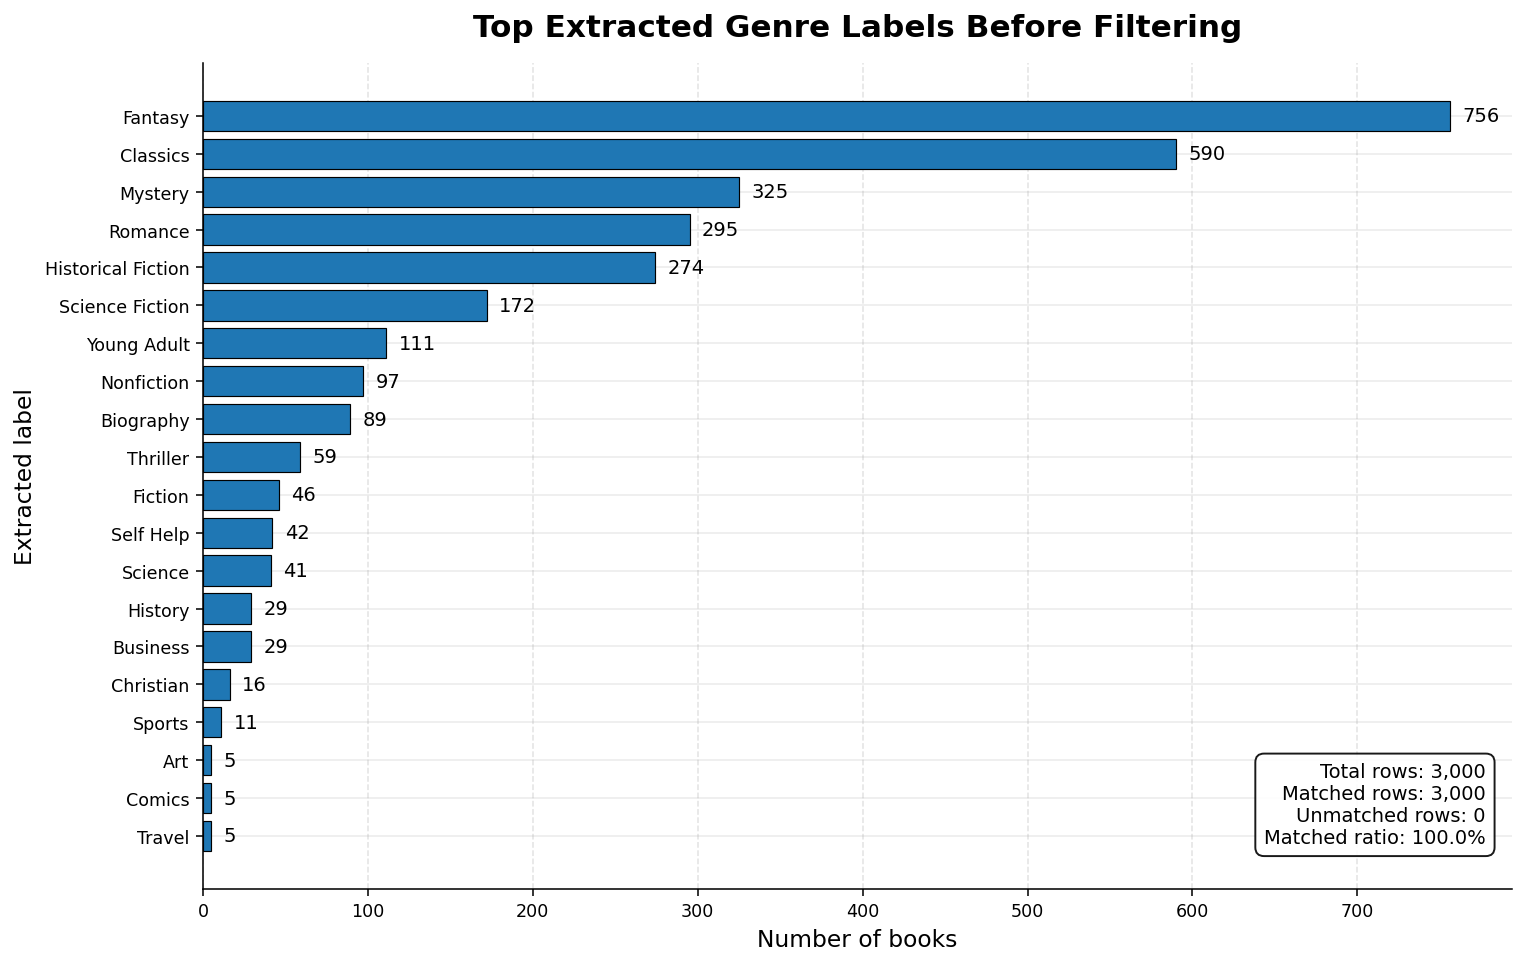

In [6]:
TARGET_GENRES = [
    "Fantasy",
    "Romance",
    "Mystery",
    "Thriller",
    "Science Fiction",
    "Historical Fiction",
    "Young Adult",
    "Classics",
    "Fiction",
    "Nonfiction",
    "History",
    "Biography",
    "Memoir",
    "Horror",
    "Children's",
    "Science",
    "Business",
    "Psychology",
    "Self Help",
    "Poetry",
    "Graphic Novels",
    "Comics",
    "Travel",
    "Sports",
    "Christian",
    "Cookbooks",
    "Music",
    "Art",
]

TARGET_GENRE_SET = set(TARGET_GENRES)
GENRE_PRIORITY = {genre: i for i, genre in enumerate(TARGET_GENRES)}


def split_genres(genres_value):
    # Split one raw genre cell into cleaned genre tokens.
    if genres_value is None:
        return []

    text = str(genres_value).strip()
    if not text:
        return []

    return [g.strip().strip('"').strip("'") for g in text.split(",") if g.strip()]


def choose_main_genre(genres_value):
    # Convert a multi-genre row into one supervised label.
    genres = split_genres(genres_value)
    candidates = [g for g in genres if g in TARGET_GENRE_SET]

    if not candidates:
        return None

    counts = Counter(candidates)
    return sorted(counts.keys(), key=lambda g: (-counts[g], GENRE_PRIORITY[g]))[0]


df["label"] = df[GENRES_COLUMN].apply(choose_main_genre)


# =========================
# Visualize extracted labels
# =========================

label_counts = (
    df["label"]
    .fillna("No selected target genre")
    .value_counts()
    .head(20)
    .sort_values()
)

total_rows = len(df)
matched_rows = df["label"].notna().sum()
unmatched_rows = total_rows - matched_rows

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    label_counts.index,
    label_counts.values,
    edgecolor="black",
    linewidth=0.6,
)

ax.set_title(
    "Top Extracted Genre Labels Before Filtering",
    fontsize=16,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Number of books", fontsize=12)
ax.set_ylabel("Extracted label", fontsize=12)

ax.grid(axis="x", linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

max_count = label_counts.max()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + max_count * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=10,
    )

summary_text = (
    f"Total rows: {total_rows:,}\n"
    f"Matched rows: {matched_rows:,}\n"
    f"Unmatched rows: {unmatched_rows:,}\n"
    f"Matched ratio: {matched_rows / total_rows:.1%}"
)

ax.text(
    0.98,
    0.05,
    summary_text,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.45",
        facecolor="white",
        edgecolor="black",
        alpha=0.9,
    ),
)

plt.tight_layout()
plt.show()

## 5. Clean rows and keep common classes

Keep rows with a usable description, a usable embedding, and one of the selected labels.

In [7]:
df[DESCRIPTION_COLUMN] = df[DESCRIPTION_COLUMN].fillna("")  # Replace blanks
df[DESCRIPTION_COLUMN] = df[DESCRIPTION_COLUMN].astype(str)  # Force text type
df[DESCRIPTION_COLUMN] = df[DESCRIPTION_COLUMN].str.strip()  # Trim extra spaces

df_model = df[
    (df[DESCRIPTION_COLUMN] != "") & 
    (df[EMBEDDING_COLUMN].notna()) & 
    (df["label"].notna())
].copy()

genre_counts = df_model["label"].value_counts()
eligible_genres = genre_counts[genre_counts >= MIN_SAMPLES_PER_CLASS]

# If the dataset is small, keep the notebook runnable instead of failing immediately.
if len(eligible_genres) < 2:
    print("MIN_SAMPLES_PER_CLASS is too strict. Falling back to classes with at least 5 examples.")
    eligible_genres = genre_counts[genre_counts >= 5].head(TOP_N_CLASSES)

selected_genres = eligible_genres.head(TOP_N_CLASSES).index

df_model = df_model[df_model["label"].isin(selected_genres)].copy()
df_model = df_model.reset_index(drop=True)

if df_model["label"].nunique() < 2:
    raise ValueError("Need at least two classes after filtering. Lower MIN_SAMPLES_PER_CLASS or TOP_N_CLASSES.")

print("Selected genres:")
print(selected_genres)
print()
print("Final dataset shape:", df_model.shape)

class_counts = df_model["label"].value_counts()
class_summary = pd.DataFrame({
    "count": class_counts,
    "proportion": class_counts / class_counts.sum(),
})

display(class_summary)

Selected genres:
Index(['Fantasy', 'Classics', 'Mystery', 'Romance', 'Historical Fiction',
       'Science Fiction', 'Young Adult'],
      dtype='str', name='label')

Final dataset shape: (2465, 26)


,count,proportion
label,,
Fantasy,737,0.298986
Classics,570,0.231237
Mystery,321,0.130223
Romance,290,0.117647
Historical Fiction,271,0.109939
Science Fiction,168,0.068154
Young Adult,108,0.043813


### Class distribution after filtering


classes who are rare may need special attention during evaluation.

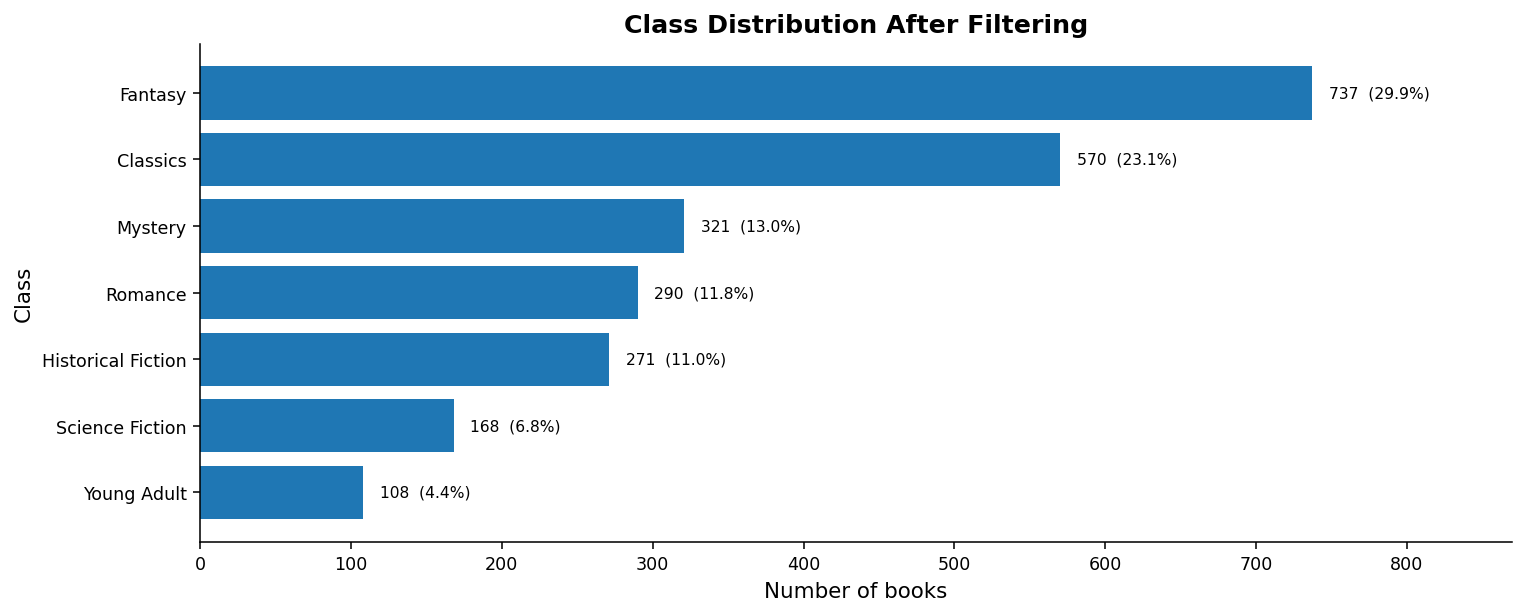

In [8]:
plot_horizontal_count_distribution(
    df_model["label"].value_counts(),
    title="Class Distribution After Filtering",
    xlabel="Number of books",
)

In [9]:
def parse_embedding(value):
    # Each cell should contain a JSON-style list of floats, e.g. "[0.1, -0.2, ...]".
    text = str(value).strip()

    if not text:
        return None

    try:
        parsed = json.loads(text)
    except json.JSONDecodeError:
        parsed = ast.literal_eval(text)

    arr = np.asarray(parsed, dtype=np.float32)

    if arr.ndim != 1 or arr.size == 0:
        return None

    return arr


parsed_embeddings = df_model[EMBEDDING_COLUMN].apply(parse_embedding)
valid_embedding_mask = parsed_embeddings.notna()

if not valid_embedding_mask.all():
    print("Dropping rows with invalid embeddings:", int((~valid_embedding_mask).sum()))
    df_model = df_model[valid_embedding_mask].copy()
    parsed_embeddings = parsed_embeddings[valid_embedding_mask]

embedding_matrix = np.vstack(parsed_embeddings.values)

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (2465, 1024)



## 6. Scratch implementations

Read these classes before running the experiments. These are the implementations that must be used throughout the notebook.

The goal is not to beat mature libraries. The goal is to make each method transparent enough to inspect, modify, and debug.


In [10]:

# ============================================================
# Utility helpers
# ============================================================

def as_1d_int_array(values):
    return np.asarray(values, dtype=int).ravel()


def stable_softmax(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)


def one_hot(y, n_classes):
    y = as_1d_int_array(y)
    Y = np.zeros((len(y), n_classes), dtype=np.float32)
    Y[np.arange(len(y)), y] = 1.0
    return Y


def safe_sparse_to_dense(X):
    if sparse.issparse(X):
        return X.toarray()
    return np.asarray(X)


def l2_normalize_rows(X, eps=1e-12):
    if sparse.issparse(X):
        row_norms = np.sqrt(np.asarray(X.multiply(X).sum(axis=1)).ravel())
        row_norms[row_norms < eps] = 1.0
        return X.multiply(1.0 / row_norms[:, None]).tocsr()

    X = np.asarray(X, dtype=np.float32)
    row_norms = np.linalg.norm(X, axis=1, keepdims=True)
    row_norms[row_norms < eps] = 1.0
    return X / row_norms


# ============================================================
# Label encoding and stratified splitting
# ============================================================

class ScratchLabelEncoder:
    def fit(self, labels):
        self.classes_ = np.array(sorted(pd.Series(labels).astype(str).unique()))
        self.class_to_id_ = {label: i for i, label in enumerate(self.classes_)}
        return self

    def transform(self, labels):
        return np.array([self.class_to_id_[str(label)] for label in labels], dtype=int)

    def fit_transform(self, labels):
        return self.fit(labels).transform(labels)

    def inverse_transform(self, ids):
        ids = as_1d_int_array(ids)
        return self.classes_[ids]


def stratified_train_dev_test_split(y, train_size=0.70, dev_size=0.15, test_size=0.15, random_state=42):
    # Preserve the class distribution in train/dev/test.
    y = as_1d_int_array(y)
    rng = np.random.default_rng(random_state)

    if not np.isclose(train_size + dev_size + test_size, 1.0):
        raise ValueError("train_size + dev_size + test_size must equal 1.")

    train_idx, dev_idx, test_idx = [], [], []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]
        rng.shuffle(class_indices)
        n = len(class_indices)

        n_train = int(np.floor(n * train_size))
        n_dev = int(np.floor(n * dev_size))
        n_test = n - n_train - n_dev

        if n >= 3:
            if n_dev == 0:
                n_dev = 1
                n_train = max(1, n_train - 1)
            if n_test == 0:
                n_test = 1
                n_train = max(1, n_train - 1)

        train_idx.extend(class_indices[:n_train])
        dev_idx.extend(class_indices[n_train:n_train + n_dev])
        test_idx.extend(class_indices[n_train + n_dev:])

    train_idx = np.array(train_idx, dtype=int)
    dev_idx = np.array(dev_idx, dtype=int)
    test_idx = np.array(test_idx, dtype=int)

    rng.shuffle(train_idx)
    rng.shuffle(dev_idx)
    rng.shuffle(test_idx)

    return train_idx, dev_idx, test_idx


# ============================================================
# TF-IDF from scratch
# ============================================================

class ScratchTfidfVectorizer:
    def __init__(
        self,
        lowercase=True,
        ngram_range=(1, 1),
        min_df=1,
        max_df=1.0,
        max_features=None,
        sublinear_tf=True,
        norm="l2",
    ):
        self.lowercase = lowercase
        self.ngram_range = ngram_range
        self.min_df = min_df
        self.max_df = max_df
        self.max_features = max_features
        self.sublinear_tf = sublinear_tf
        self.norm = norm
        self.token_pattern = re.compile(r"(?u)\b\w\w+\b")

    def _tokens(self, text):
        text = "" if text is None else str(text)
        if self.lowercase:
            text = text.lower()
        return self.token_pattern.findall(text)

    def _analyze(self, text):
        tokens = self._tokens(text)
        min_n, max_n = self.ngram_range

        terms = []
        for n in range(min_n, max_n + 1):
            if len(tokens) >= n:
                terms.extend([" ".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)])
        return terms

    def fit(self, documents):
        documents = list(documents)
        n_docs = len(documents)

        df_counter = Counter()
        tf_counter = Counter()

        for doc in tqdm(documents, desc="Fitting scratch TF-IDF"):
            terms = self._analyze(doc)
            tf_counter.update(terms)
            df_counter.update(set(terms))

        min_df_abs = self.min_df if isinstance(self.min_df, int) else int(math.ceil(self.min_df * n_docs))
        max_df_abs = self.max_df if isinstance(self.max_df, int) else int(math.floor(self.max_df * n_docs))

        candidate_terms = [
            term for term, df in df_counter.items()
            if df >= min_df_abs and df <= max_df_abs
        ]

        candidate_terms = sorted(candidate_terms, key=lambda term: (-tf_counter[term], term))
        if self.max_features is not None:
            candidate_terms = candidate_terms[:self.max_features]

        self.vocabulary_ = {term: i for i, term in enumerate(candidate_terms)}
        self.feature_names_ = np.array(candidate_terms, dtype=object)

        dfs = np.array([df_counter[term] for term in candidate_terms], dtype=np.float64)
        self.idf_ = np.log((1.0 + n_docs) / (1.0 + dfs)) + 1.0
        return self

    def transform(self, documents):
        if not hasattr(self, "vocabulary_"):
            raise ValueError("Vectorizer must be fitted before transform.")

        documents = list(documents)
        rows, cols, data = [], [], []

        for row_id, doc in enumerate(tqdm(documents, desc="Transforming with scratch TF-IDF")):
            counts = Counter(term for term in self._analyze(doc) if term in self.vocabulary_)

            for term, count in counts.items():
                col_id = self.vocabulary_[term]
                tf = 1.0 + math.log(count) if self.sublinear_tf else float(count)
                rows.append(row_id)
                cols.append(col_id)
                data.append(tf * self.idf_[col_id])

        X = sparse.csr_matrix(
            (data, (rows, cols)),
            shape=(len(documents), len(self.vocabulary_)),
            dtype=np.float32,
        )

        if self.norm == "l2":
            X = l2_normalize_rows(X)

        return X

    def fit_transform(self, documents):
        return self.fit(documents).transform(documents)

    def get_feature_names_out(self):
        return self.feature_names_


def select_top_sparse_columns_by_variance(X, max_features):
    # Convert only a selected subset of sparse TF-IDF features to dense form for the MLP.
    if not sparse.issparse(X):
        X = sparse.csr_matrix(X)

    n_features = X.shape[1]
    keep = min(max_features, n_features)

    mean = np.asarray(X.mean(axis=0)).ravel()
    mean_sq = np.asarray(X.power(2).mean(axis=0)).ravel()
    variance = mean_sq - mean ** 2

    selected = np.argsort(variance)[-keep:]
    selected = np.sort(selected)

    return selected


# ============================================================
# Scaling from scratch
# ============================================================

class ScratchStandardScaler:
    def __init__(self, eps=1e-8):
        self.eps = eps

    def fit(self, X):
        X = np.asarray(X, dtype=np.float32)
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ < self.eps] = 1.0
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)


class ScratchScaledClassifier:
    def __init__(self, estimator):
        self.estimator = estimator
        self.scaler = ScratchStandardScaler()

    def fit(self, X, y):
        X_scaled = self.scaler.fit_transform(safe_sparse_to_dense(X))
        self.estimator.fit(X_scaled, y)
        return self

    def predict(self, X):
        X_scaled = self.scaler.transform(safe_sparse_to_dense(X))
        return self.estimator.predict(X_scaled)


# ============================================================
# Metrics from scratch
# ============================================================

def scratch_confusion_matrix(y_true, y_pred, labels=None, normalize=None):
    y_true = as_1d_int_array(y_true)
    y_pred = as_1d_int_array(y_pred)

    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    labels = as_1d_int_array(labels)

    label_to_position = {label: i for i, label in enumerate(labels)}
    cm = np.zeros((len(labels), len(labels)), dtype=np.float64)

    for true_label, pred_label in zip(y_true, y_pred):
        if true_label in label_to_position and pred_label in label_to_position:
            cm[label_to_position[true_label], label_to_position[pred_label]] += 1

    if normalize == "true":
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm = cm / row_sums

    return cm


def per_class_metrics(y_true, y_pred, labels):
    cm = scratch_confusion_matrix(y_true, y_pred, labels=labels)
    rows = []

    for i, label in enumerate(labels):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        support = cm[i, :].sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        rows.append({
            "label": label,
            "precision": precision,
            "recall": recall,
            "f1-score": f1,
            "support": support,
        })

    return pd.DataFrame(rows)


def compute_metrics(y_true, y_pred):
    y_true = as_1d_int_array(y_true)
    y_pred = as_1d_int_array(y_pred)
    labels = np.unique(np.concatenate([y_true, y_pred]))

    class_df = per_class_metrics(y_true, y_pred, labels)
    accuracy = float(np.mean(y_true == y_pred))

    cm = scratch_confusion_matrix(y_true, y_pred, labels=labels)
    total_tp = float(np.trace(cm))
    total_fp = float(cm.sum(axis=0).sum() - total_tp)
    total_fn = float(cm.sum(axis=1).sum() - total_tp)

    micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    micro_f1 = (
        2 * micro_precision * micro_recall / (micro_precision + micro_recall)
        if (micro_precision + micro_recall) > 0
        else 0.0
    )

    return {
        "accuracy": accuracy,
        "macro_precision": float(class_df["precision"].mean()),
        "macro_recall": float(class_df["recall"].mean()),
        "macro_f1": float(class_df["f1-score"].mean()),
        "micro_precision": float(micro_precision),
        "micro_recall": float(micro_recall),
        "micro_f1": float(micro_f1),
    }


def classification_report_scratch(y_true, y_pred, target_names, digits=3, output_dict=False):
    labels = np.arange(len(target_names))
    class_df = per_class_metrics(y_true, y_pred, labels=labels)
    class_df["class_name"] = target_names

    metrics = compute_metrics(y_true, y_pred)
    accuracy = metrics["accuracy"]

    if output_dict:
        report = {}
        for _, row in class_df.iterrows():
            report[row["class_name"]] = {
                "precision": float(row["precision"]),
                "recall": float(row["recall"]),
                "f1-score": float(row["f1-score"]),
                "support": float(row["support"]),
            }

        report["accuracy"] = accuracy
        report["macro avg"] = {
            "precision": metrics["macro_precision"],
            "recall": metrics["macro_recall"],
            "f1-score": metrics["macro_f1"],
            "support": float(len(y_true)),
        }
        report["micro avg"] = {
            "precision": metrics["micro_precision"],
            "recall": metrics["micro_recall"],
            "f1-score": metrics["micro_f1"],
            "support": float(len(y_true)),
        }
        return report

    name_width = max(12, max(len(str(name)) for name in target_names) + 2)
    header = f"{'':>{name_width}} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}"
    lines = [header]

    for _, row in class_df.iterrows():
        lines.append(
            f"{row['class_name']:>{name_width}} "
            f"{row['precision']:>10.{digits}f} "
            f"{row['recall']:>10.{digits}f} "
            f"{row['f1-score']:>10.{digits}f} "
            f"{int(row['support']):>10d}"
        )

    lines.append("")
    lines.append(f"{'accuracy':>{name_width}} {'':>10} {'':>10} {accuracy:>10.{digits}f} {len(y_true):>10d}")
    lines.append(
        f"{'macro avg':>{name_width}} "
        f"{metrics['macro_precision']:>10.{digits}f} "
        f"{metrics['macro_recall']:>10.{digits}f} "
        f"{metrics['macro_f1']:>10.{digits}f} "
        f"{len(y_true):>10d}"
    )
    lines.append(
        f"{'micro avg':>{name_width}} "
        f"{metrics['micro_precision']:>10.{digits}f} "
        f"{metrics['micro_recall']:>10.{digits}f} "
        f"{metrics['micro_f1']:>10.{digits}f} "
        f"{len(y_true):>10d}"
    )

    return "\n".join(lines)


# ============================================================
# Classifiers from scratch
# ============================================================

class ScratchMultinomialNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        y = as_1d_int_array(y)
        X = X.tocsr() if sparse.issparse(X) else sparse.csr_matrix(X)

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X.shape[1]

        class_count = np.zeros(n_classes, dtype=np.float64)
        feature_count = np.zeros((n_classes, n_features), dtype=np.float64)

        for i, class_id in enumerate(self.classes_):
            mask = y == class_id
            class_count[i] = mask.sum()
            feature_count[i, :] = np.asarray(X[mask].sum(axis=0)).ravel()

        smoothed_fc = feature_count + self.alpha
        smoothed_cc = smoothed_fc.sum(axis=1, keepdims=True)

        self.class_log_prior_ = np.log(class_count / class_count.sum())
        self.feature_log_prob_ = np.log(smoothed_fc / smoothed_cc)
        self.coef_ = self.feature_log_prob_
        return self

    def predict(self, X):
        X = X.tocsr() if sparse.issparse(X) else sparse.csr_matrix(X)
        scores = X @ self.feature_log_prob_.T + self.class_log_prior_
        return self.classes_[np.asarray(scores).argmax(axis=1)]


class ScratchGaussianNB:
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        X = safe_sparse_to_dense(X).astype(np.float32)
        y = as_1d_int_array(y)

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X.shape[1]

        self.theta_ = np.zeros((n_classes, n_features), dtype=np.float32)
        self.var_ = np.zeros((n_classes, n_features), dtype=np.float32)
        self.class_prior_ = np.zeros(n_classes, dtype=np.float32)

        global_var = np.var(X, axis=0).max()
        eps = self.var_smoothing * global_var if global_var > 0 else self.var_smoothing

        for i, class_id in enumerate(self.classes_):
            X_c = X[y == class_id]
            self.theta_[i] = X_c.mean(axis=0)
            self.var_[i] = X_c.var(axis=0) + eps
            self.class_prior_[i] = len(X_c) / len(X)

        return self

    def predict(self, X):
        X = safe_sparse_to_dense(X).astype(np.float32)
        log_priors = np.log(self.class_prior_ + 1e-12)

        preds = []
        batch_size = 512

        for start in range(0, X.shape[0], batch_size):
            Xb = X[start:start + batch_size]
            log_prob = -0.5 * (
                np.log(2.0 * np.pi * self.var_[None, :, :])
                + ((Xb[:, None, :] - self.theta_[None, :, :]) ** 2) / self.var_[None, :, :]
            )
            scores = log_prob.sum(axis=2) + log_priors
            preds.extend(self.classes_[np.argmax(scores, axis=1)])

        return np.asarray(preds, dtype=int)


class ScratchKNNClassifier:
    def __init__(self, n_neighbors=5, metric="cosine", batch_size=256):
        self.n_neighbors = n_neighbors
        self.metric = metric
        self.batch_size = batch_size

    def fit(self, X, y):
        self.y_train_ = as_1d_int_array(y)
        self.classes_ = np.unique(self.y_train_)

        if self.metric != "cosine":
            raise ValueError("This assignment implementation supports cosine kNN.")

        self.X_train_ = l2_normalize_rows(X)
        return self

    def predict(self, X):
        X_eval = l2_normalize_rows(X)
        preds = []

        for start in range(0, X_eval.shape[0], self.batch_size):
            Xb = X_eval[start:start + self.batch_size]

            sims = Xb @ self.X_train_.T
            if sparse.issparse(sims):
                sims = sims.toarray()
            else:
                sims = np.asarray(sims)

            k = min(self.n_neighbors, sims.shape[1])
            neighbor_idx = np.argpartition(-sims, kth=k-1, axis=1)[:, :k]

            for row_neighbors in neighbor_idx:
                neighbor_labels = self.y_train_[row_neighbors]
                counts = np.bincount(neighbor_labels, minlength=int(self.classes_.max()) + 1)
                preds.append(np.argmax(counts))

        return np.asarray(preds, dtype=int)


class ScratchSoftmaxLogisticRegression:
    def __init__(
        self,
        learning_rate=0.5,
        max_epochs=60,
        batch_size=512,
        alpha=1e-4,
        random_state=42,
        verbose=False,
    ):
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.alpha = alpha
        self.random_state = random_state
        self.verbose = verbose

    def fit(self, X, y):
        y = as_1d_int_array(y)
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_samples, n_features = X.shape

        rng = np.random.default_rng(self.random_state)
        self.W_ = rng.normal(0, 0.01, size=(n_features, n_classes)).astype(np.float32)
        self.b_ = np.zeros(n_classes, dtype=np.float32)
        self.loss_history_ = []

        indices = np.arange(n_samples)

        for epoch in range(self.max_epochs):
            rng.shuffle(indices)

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                Xb = X[batch_idx]
                yb = y[batch_idx]

                logits = Xb @ self.W_ + self.b_
                logits = np.asarray(logits)
                probs = stable_softmax(logits)

                Yb = one_hot(yb, n_classes)
                error = (probs - Yb) / len(yb)

                if sparse.issparse(Xb):
                    grad_W = Xb.T @ error
                    grad_W = np.asarray(grad_W)
                else:
                    grad_W = Xb.T @ error

                grad_W += self.alpha * self.W_
                grad_b = error.sum(axis=0)

                self.W_ -= self.learning_rate * grad_W
                self.b_ -= self.learning_rate * grad_b

            if self.verbose or epoch == self.max_epochs - 1:
                loss = self._loss(X, y)
                self.loss_history_.append(loss)
                if self.verbose and (epoch % 10 == 0 or epoch == self.max_epochs - 1):
                    print(f"epoch={epoch + 1:03d}, loss={loss:.4f}")

        self.coef_ = self.W_.T
        self.intercept_ = self.b_
        return self

    def _loss(self, X, y):
        y = as_1d_int_array(y)
        logits = np.asarray(X @ self.W_ + self.b_)
        probs = stable_softmax(logits)
        n = len(y)
        ce = -np.log(probs[np.arange(n), y] + 1e-12).mean()
        reg = 0.5 * self.alpha * np.sum(self.W_ ** 2)
        return float(ce + reg)

    def predict_proba(self, X):
        logits = np.asarray(X @ self.W_ + self.b_)
        return stable_softmax(logits)

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]


class ScratchMLPClassifier:
    def __init__(
        self,
        hidden_dim=128,
        learning_rate=1e-3,
        max_epochs=35,
        batch_size=128,
        alpha=1e-4,
        random_state=42,
        verbose=False,
    ):
        self.hidden_dim = hidden_dim
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.alpha = alpha
        self.random_state = random_state
        self.verbose = verbose

    def fit(self, X, y):
        X = safe_sparse_to_dense(X).astype(np.float32)
        y = as_1d_int_array(y)

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_samples, n_features = X.shape

        rng = np.random.default_rng(self.random_state)

        self.W1_ = rng.normal(0, np.sqrt(2.0 / n_features), size=(n_features, self.hidden_dim)).astype(np.float32)
        self.b1_ = np.zeros(self.hidden_dim, dtype=np.float32)
        self.W2_ = rng.normal(0, np.sqrt(2.0 / self.hidden_dim), size=(self.hidden_dim, n_classes)).astype(np.float32)
        self.b2_ = np.zeros(n_classes, dtype=np.float32)

        self.loss_history_ = []
        indices = np.arange(n_samples)

        for epoch in range(self.max_epochs):
            rng.shuffle(indices)

            for start in range(0, n_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                Xb = X[batch_idx]
                yb = y[batch_idx]

                Z1 = Xb @ self.W1_ + self.b1_
                A1 = np.maximum(0, Z1)
                logits = A1 @ self.W2_ + self.b2_
                probs = stable_softmax(logits)

                Yb = one_hot(yb, n_classes)
                dlogits = (probs - Yb) / len(yb)

                dW2 = A1.T @ dlogits + self.alpha * self.W2_
                db2 = dlogits.sum(axis=0)

                dA1 = dlogits @ self.W2_.T
                dZ1 = dA1 * (Z1 > 0)

                dW1 = Xb.T @ dZ1 + self.alpha * self.W1_
                db1 = dZ1.sum(axis=0)

                self.W1_ -= self.learning_rate * dW1
                self.b1_ -= self.learning_rate * db1
                self.W2_ -= self.learning_rate * dW2
                self.b2_ -= self.learning_rate * db2

            if self.verbose or epoch == self.max_epochs - 1:
                loss = self._loss(X, y)
                self.loss_history_.append(loss)
                if self.verbose and (epoch % 10 == 0 or epoch == self.max_epochs - 1):
                    print(f"epoch={epoch + 1:03d}, loss={loss:.4f}")

        return self

    def _loss(self, X, y):
        probs = self.predict_proba(X)
        ce = -np.log(probs[np.arange(len(y)), y] + 1e-12).mean()
        reg = 0.5 * self.alpha * (np.sum(self.W1_ ** 2) + np.sum(self.W2_ ** 2))
        return float(ce + reg)

    def predict_proba(self, X):
        X = safe_sparse_to_dense(X).astype(np.float32)
        Z1 = X @ self.W1_ + self.b1_
        A1 = np.maximum(0, Z1)
        logits = A1 @ self.W2_ + self.b2_
        return stable_softmax(logits)

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[np.argmax(probs, axis=1)]


## 7. Encode labels and visualize sentence embeddings

Use PCA only for visualization.


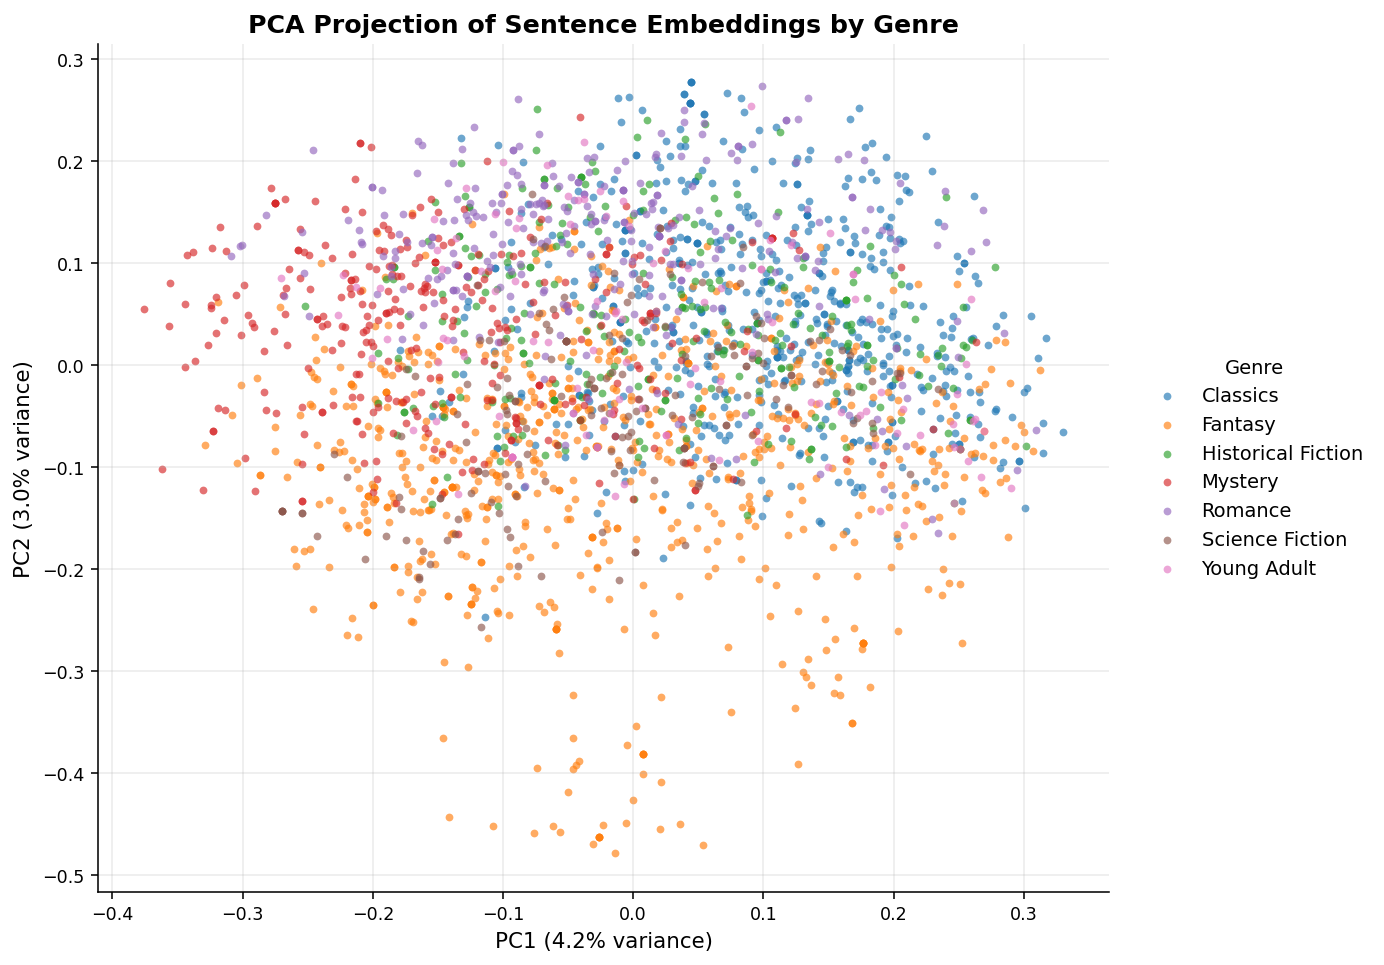

In [11]:
label_encoder = ScratchLabelEncoder()
y_all = label_encoder.fit_transform(df_model["label"])
class_names = label_encoder.classes_

plot_pca_projection(
    embedding_matrix,
    y_all,
    class_names,
    title="PCA Projection of Sentence Embeddings by Genre",
    max_points=MAX_POINTS_FOR_PCA_PLOT,
    random_state=RANDOM_STATE,
)

## 8. Create train/dev/test splits

Split the dataset into train, development, and test sets. Preserve the label distribution using stratified splits.

In [12]:
train_idx, dev_idx, test_idx = stratified_train_dev_test_split(
    y_all,
    train_size=TRAIN_SIZE,
    dev_size=DEV_SIZE,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

y_train = y_all[train_idx]
y_dev = y_all[dev_idx]
y_test = y_all[test_idx]

print("Train size:", len(train_idx))
print("Dev size:", len(dev_idx))
print("Test size:", len(test_idx))
print("Classes:", class_names.tolist())

Train size: 1722
Dev size: 367
Test size: 376
Classes: ['Classics', 'Fantasy', 'Historical Fiction', 'Mystery', 'Romance', 'Science Fiction', 'Young Adult']


### Split distributions

Check that the stratified split preserved the class proportions.

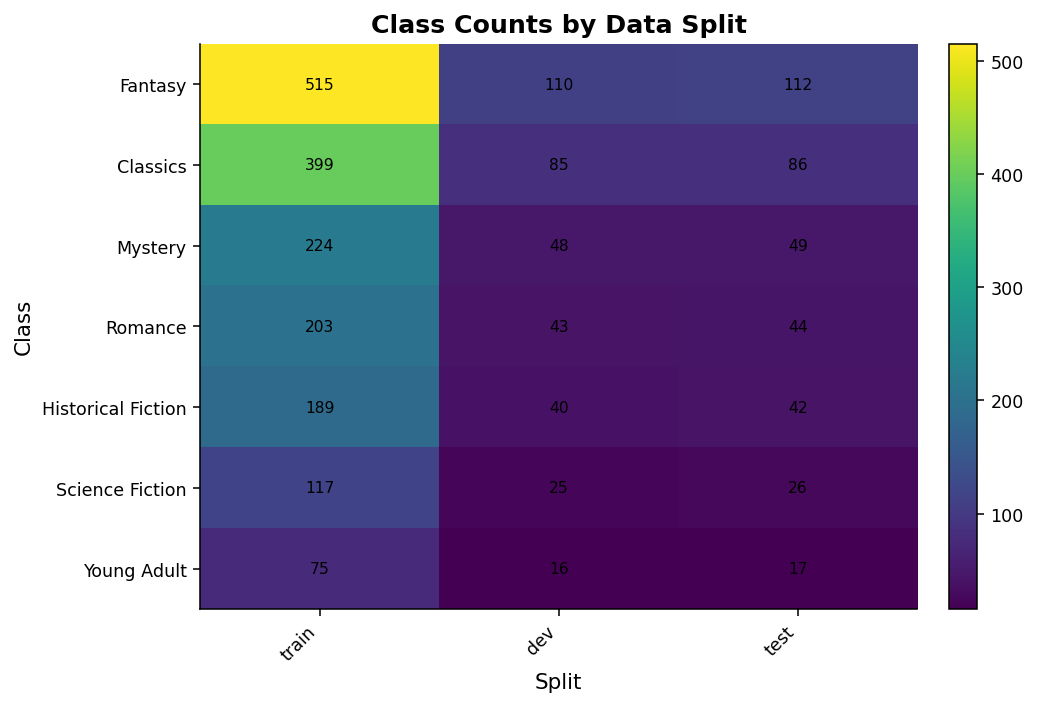

,train,dev,test
Fantasy,515,110,112
Classics,399,85,86
Mystery,224,48,49
Romance,203,43,44
Historical Fiction,189,40,42
Science Fiction,117,25,26
Young Adult,75,16,17


In [13]:
split_distribution_df = pd.DataFrame({
    "train": pd.Series(label_encoder.inverse_transform(y_train)).value_counts(),
    "dev": pd.Series(label_encoder.inverse_transform(y_dev)).value_counts(),
    "test": pd.Series(label_encoder.inverse_transform(y_test)).value_counts(),
}).fillna(0).astype(int)

plot_metric_heatmap(
    split_distribution_df,
    title="Class Counts by Data Split",
    xlabel="Split",
    ylabel="Class",
    value_format=".0f",
)

display(split_distribution_df)

#### Are the train/dev/test distributions similar enough? Why does this matter?

**Answer:** Yes, the train, dev, and test distributions are very similar because **stratification** keeps the same balance of genres in all three parts. This is important because it makes the testing fair. The model needs to be evaluated on the same mix of data it studied. If the training data has mostly one genre but the test data has a different one, the final test scores will be wrong and misleading. Keeping the genre percentages the same across all splits makes sure the final results show how well the model actually works in the real world.

## 9. Build TF-IDF features

Fit the scratch TF-IDF vectorizer only on the training descriptions. Transform the development and test descriptions with the same fitted vocabulary and IDF values.

In [14]:
train_texts = df_model[DESCRIPTION_COLUMN].iloc[train_idx].values
dev_texts = df_model[DESCRIPTION_COLUMN].iloc[dev_idx].values
test_texts = df_model[DESCRIPTION_COLUMN].iloc[test_idx].values

tfidf_vectorizer = ScratchTfidfVectorizer(
    lowercase=True,
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=MAX_TFIDF_FEATURES,
    sublinear_tf=True,
    norm="l2",
)

X_tfidf_train = tfidf_vectorizer.fit_transform(train_texts)
X_tfidf_dev = tfidf_vectorizer.transform(dev_texts)
X_tfidf_test = tfidf_vectorizer.transform(test_texts)

X_emb_train = embedding_matrix[train_idx]
X_emb_dev = embedding_matrix[dev_idx]
X_emb_test = embedding_matrix[test_idx]

print("TF-IDF train shape:", X_tfidf_train.shape)
print("Sentence embedding train shape:", X_emb_train.shape)

Fitting scratch TF-IDF:   0%|          | 0/1722 [00:00<?, ?it/s]

Transforming with scratch TF-IDF:   0%|          | 0/1722 [00:00<?, ?it/s]

Transforming with scratch TF-IDF:   0%|          | 0/367 [00:00<?, ?it/s]

Transforming with scratch TF-IDF:   0%|          | 0/376 [00:00<?, ?it/s]

TF-IDF train shape: (1722, 5000)
Sentence embedding train shape: (1722, 1024)


## 10. Evaluation utilities

Use macro-F1 as the main selection metric because the dataset is imbalanced.

In [15]:
def fit_predict_and_score(model, X_train_current, y_train_current, X_eval_current, y_eval_current):
    start_time = time.time()
    model.fit(X_train_current, y_train_current)
    train_seconds = time.time() - start_time

    start_time = time.time()
    y_pred = model.predict(X_eval_current)
    predict_seconds = time.time() - start_time

    metrics = compute_metrics(y_eval_current, y_pred)
    return metrics, train_seconds, predict_seconds, y_pred

## 11. Handle class imbalance

Compare the baseline against several resampling strategies. Select the best strategy using development macro-F1, then use that selected strategy for all later models.

In [16]:
def make_resampled_indices(y, strategy, random_state=42):
    # Return row indices into the current training arrays after applying a resampling strategy.
    rng = np.random.default_rng(random_state)
    y = as_1d_int_array(y)
    all_indices = np.arange(len(y))

    if strategy == "none":
        return all_indices

    counts = pd.Series(y).value_counts().sort_index()

    if strategy == "random_oversample":
        target_count = int(counts.max())
    elif strategy == "random_undersample":
        target_count = int(counts.min())
    elif strategy == "median_resample":
        target_count = int(np.median(counts.values))
    else:
        raise ValueError(f"Unknown imbalance strategy: {strategy}")

    selected_indices = []

    for class_id in counts.index:
        class_indices = all_indices[y == class_id]

        should_replace = target_count > len(class_indices)
        resampled_class_indices = rng.choice(class_indices, size=target_count, replace=should_replace)

        selected_indices.extend(resampled_class_indices)

    selected_indices = np.asarray(selected_indices)
    rng.shuffle(selected_indices)
    return selected_indices


def subset_rows(X, row_indices):
    # Works for both NumPy arrays and scipy sparse matrices.
    return X[row_indices]


strategy_distribution_rows = []

for strategy in IMBALANCE_STRATEGIES:
    selected_rows = make_resampled_indices(y_train, strategy, random_state=RANDOM_STATE)
    strategy_labels = y_train[selected_rows]

    resampled_names = label_encoder.inverse_transform(strategy_labels)
    counts = pd.Series(resampled_names).value_counts()

    for class_name in class_names:
        strategy_distribution_rows.append({
            "imbalance_strategy": strategy,
            "class": class_name,
            "count": int(counts.get(class_name, 0)),
        })

strategy_distribution_df = pd.DataFrame(strategy_distribution_rows)
strategy_distribution_matrix = (
    strategy_distribution_df
    .pivot(index="class", columns="imbalance_strategy", values="count")
    .loc[class_names, IMBALANCE_STRATEGIES]
)

display(strategy_distribution_matrix)

imbalance_strategy,none,random_oversample,random_undersample,median_resample
class,,,,
Classics,399,515,75,203
Fantasy,515,515,75,203
Historical Fiction,189,515,75,203
Mystery,224,515,75,203
Romance,203,515,75,203
Science Fiction,117,515,75,203
Young Adult,75,515,75,203


Use scratch softmax logistic regression as the strategy-selection model. It is fast enough for repeated trials and works with both sparse TF-IDF and dense sentence embeddings.

#### After running the strategy comparison, explain whether the selected strategy improves minority-class performance or mostly changes the score by changing the training distribution.

**Answer:** Across the entire table, two things are very clear. First, sentence embeddings beat TF-IDF in many tests. Second, Random Oversampling genuinely improves how the model learns rare genres, while undersampling completely ruins it.

By repeating the rare book descriptions (oversampling), we give the model extra practice to learn their unique patterns without losing any data. On the flip side, deleting data to balance things out (undersampling) shrinks our dataset way too much. It throws away valuable text, leaving the model with too little information to learn anything useful.

In [17]:
imbalance_results = []

for strategy in IMBALANCE_STRATEGIES:
    selected_rows = make_resampled_indices(
        y_train,
        strategy=strategy,
        random_state=RANDOM_STATE,
    )

    X_tfidf_train_strategy = X_tfidf_train[selected_rows]
    X_emb_train_strategy = X_emb_train[selected_rows]
    y_train_strategy = y_train[selected_rows]

    candidates = [
        (
            "TF-IDF",
            ScratchSoftmaxLogisticRegression(
                learning_rate=LR_LEARNING_RATE,
                max_epochs=LR_IMBALANCE_EPOCHS,
                batch_size=LR_BATCH_SIZE,
                alpha=LR_ALPHA,
                random_state=RANDOM_STATE,
            ),
            X_tfidf_train_strategy,
            X_tfidf_dev,
        ),
        (
            "Sentence embedding",
            ScratchScaledClassifier(
                ScratchSoftmaxLogisticRegression(
                    learning_rate=LR_LEARNING_RATE,
                    max_epochs=LR_IMBALANCE_EPOCHS,
                    batch_size=LR_BATCH_SIZE,
                    alpha=LR_ALPHA,
                    random_state=RANDOM_STATE,
                )
            ),
            X_emb_train_strategy,
            X_emb_dev,
        ),
    ]

    for representation_name, model, X_train_current, X_dev_current in candidates:
        metrics, train_seconds, predict_seconds, _ = fit_predict_and_score(
            model,
            X_train_current,
            y_train_strategy,
            X_dev_current,
            y_dev,
        )

        imbalance_results.append({
            "imbalance_strategy": strategy,
            "representation": representation_name,
            "train_size_after_strategy": len(y_train_strategy),
            "dev_accuracy": metrics["accuracy"],
            "dev_macro_f1": metrics["macro_f1"],
            "dev_micro_f1": metrics["micro_f1"],
            "train_seconds": train_seconds,
            "dev_predict_seconds": predict_seconds,
        })

imbalance_results_df = pd.DataFrame(imbalance_results)
imbalance_results_df = imbalance_results_df.sort_values(
    ["dev_macro_f1", "dev_accuracy"],
    ascending=False,
).reset_index(drop=True)

display(imbalance_results_df)

,imbalance_strategy,representation,train_size_after_strategy,dev_accuracy,dev_macro_f1,dev_micro_f1,train_seconds,dev_predict_seconds
0,random_oversample,Sentence embedding,3605,0.716621,0.669784,0.716621,1.488245,0.001873
1,none,Sentence embedding,1722,0.716621,0.668837,0.716621,0.639965,0.001640
2,median_resample,Sentence embedding,1421,0.664850,0.628950,0.664850,0.736594,0.002395
3,random_oversample,TF-IDF,3605,0.618529,0.586152,0.618529,0.579677,0.000330
4,random_undersample,Sentence embedding,525,0.585831,0.578547,0.585831,0.232403,0.002557
5,median_resample,TF-IDF,1421,0.561308,0.526275,0.561308,0.173675,0.000164
6,random_undersample,TF-IDF,525,0.441417,0.419371,0.441417,0.084634,0.000317
7,none,TF-IDF,1722,0.414169,0.168072,0.414169,0.280616,0.000567


### Imbalance strategy performance

Compare the strategies using development metrics.

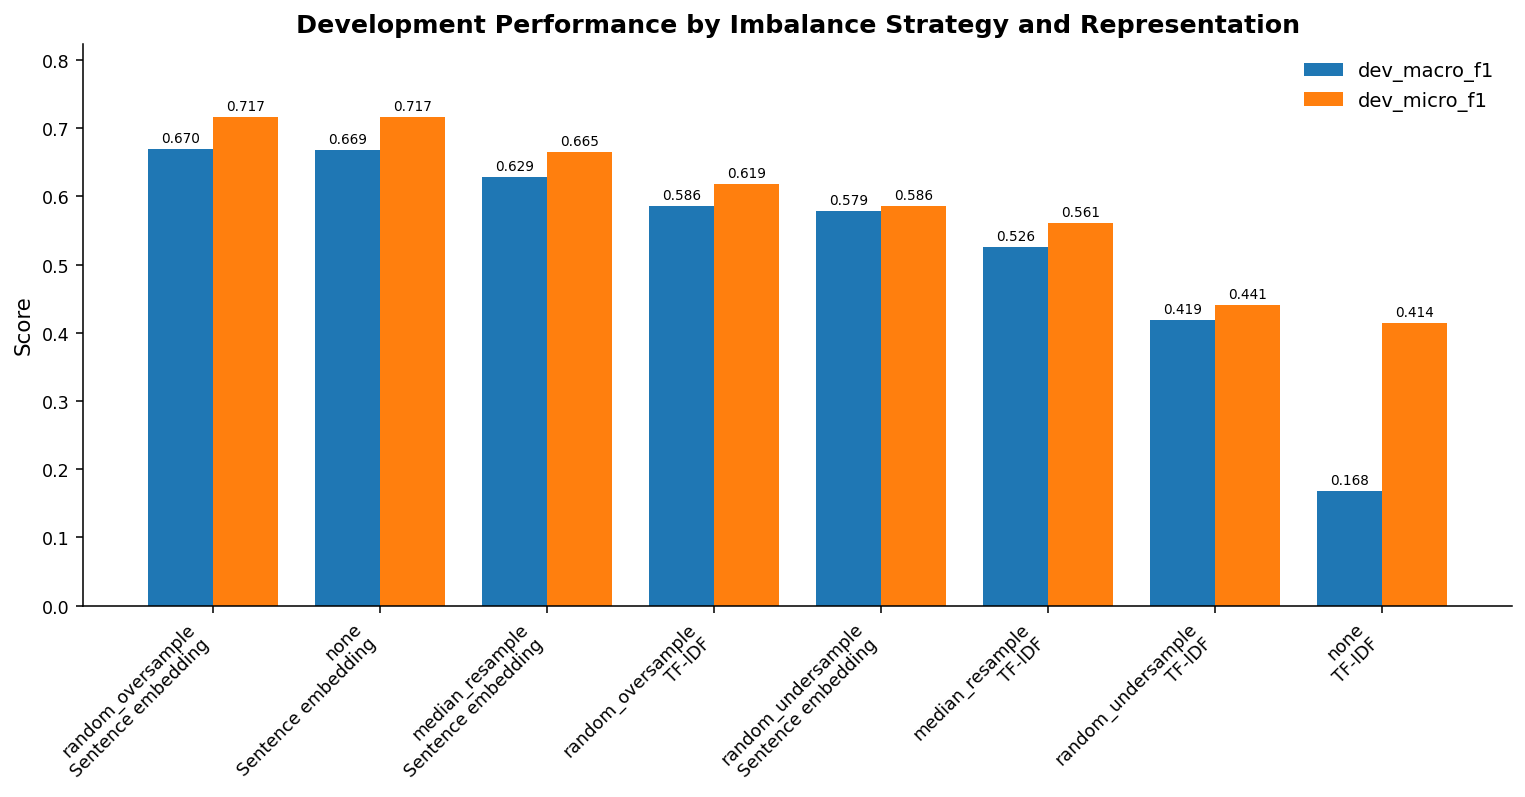

,imbalance_strategy,mean_dev_macro_f1,mean_dev_micro_f1,mean_dev_accuracy,mean_train_size
0,random_oversample,0.627968,0.667575,0.667575,3605.0
1,median_resample,0.577612,0.613079,0.613079,1421.0
2,random_undersample,0.498959,0.513624,0.513624,525.0
3,none,0.418455,0.565395,0.565395,1722.0


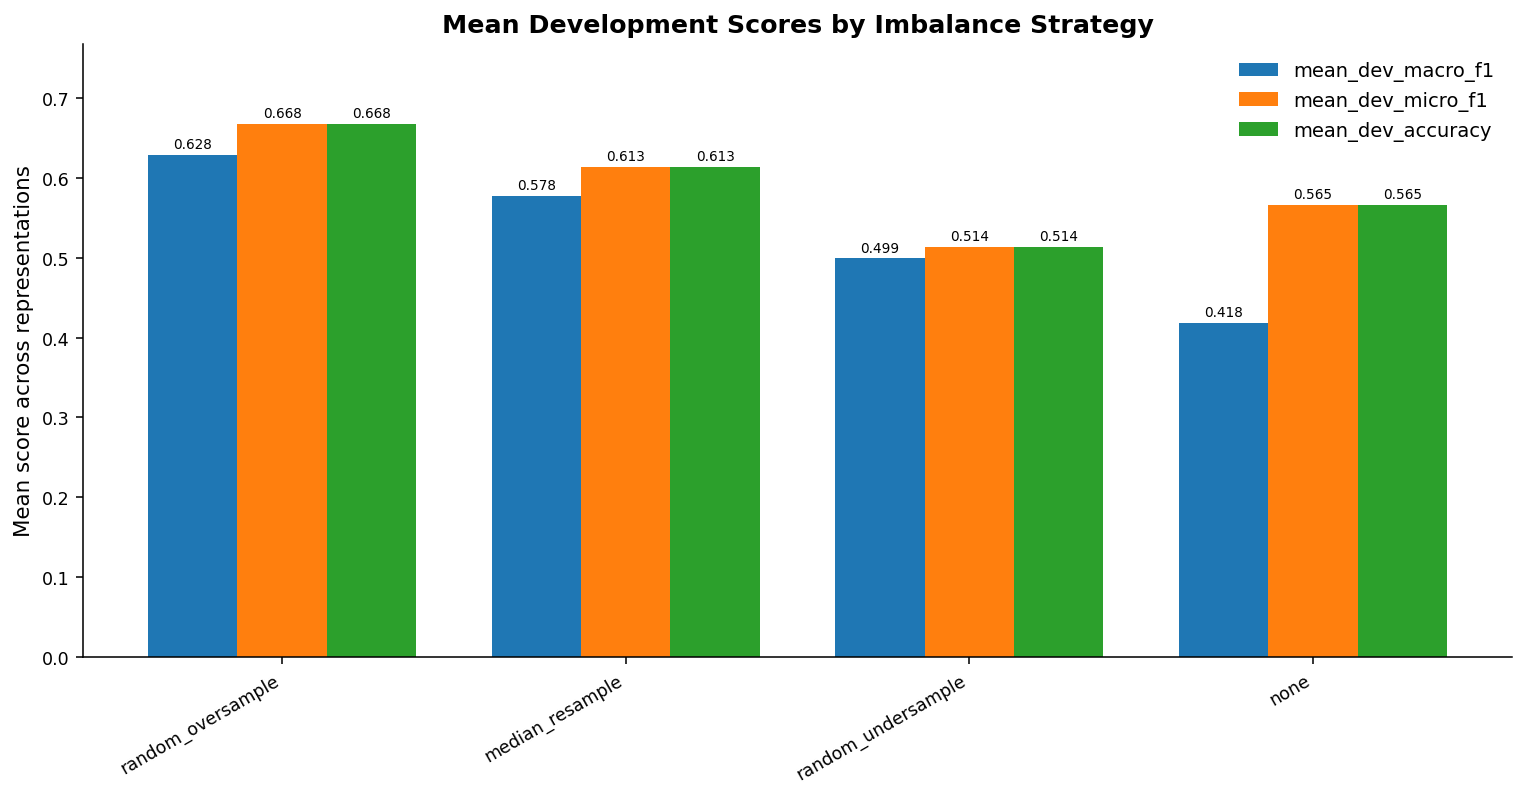

Selected imbalance strategy: random_oversample


In [18]:
plot_df = imbalance_results_df.copy()
plot_df["strategy_and_representation"] = (
    plot_df["imbalance_strategy"] + "\n" + plot_df["representation"]
)

plot_grouped_metric_bars(
    plot_df,
    category_col="strategy_and_representation",
    metric_cols=["dev_macro_f1", "dev_micro_f1"],
    title="Development Performance by Imbalance Strategy and Representation",
    ylabel="Score",
    sort_by="dev_macro_f1",
    rotation=45,
)

imbalance_summary_df = (
    imbalance_results_df
    .groupby("imbalance_strategy", as_index=False)
    .agg(
        mean_dev_macro_f1=("dev_macro_f1", "mean"),
        mean_dev_micro_f1=("dev_micro_f1", "mean"),
        mean_dev_accuracy=("dev_accuracy", "mean"),
        mean_train_size=("train_size_after_strategy", "mean"),
    )
    .sort_values(["mean_dev_macro_f1", "mean_dev_micro_f1"], ascending=False)
    .reset_index(drop=True)
)

display(imbalance_summary_df)

plot_grouped_metric_bars(
    imbalance_summary_df,
    category_col="imbalance_strategy",
    metric_cols=["mean_dev_macro_f1", "mean_dev_micro_f1", "mean_dev_accuracy"],
    title="Mean Development Scores by Imbalance Strategy",
    ylabel="Mean score across representations",
    sort_by="mean_dev_macro_f1",
    rotation=30,
)

SELECTED_IMBALANCE_STRATEGY = "random_oversample"
print("Selected imbalance strategy:", SELECTED_IMBALANCE_STRATEGY)

#### Which strategy gives the best macro-F1? Is it also the best micro-F1? Which metric should guide the choice here?

**Answer:** Random Oversampling is the clear winner. It delivers the highest macro-F1 score (0.670) and ties for the best micro-F1 score (0.717).

Macro-F1 is the metric that should guide our choice. Micro-F1 can cheat because it acts like overall accuracy—it looks good if the model just gets lucky guessing the biggest, most common genres. Macro-F1 treats every single genre equally, proving that the model is actually learning the rare categories instead of just ignoring them.

### Selected training distribution

Use the selected strategy from this point onward.


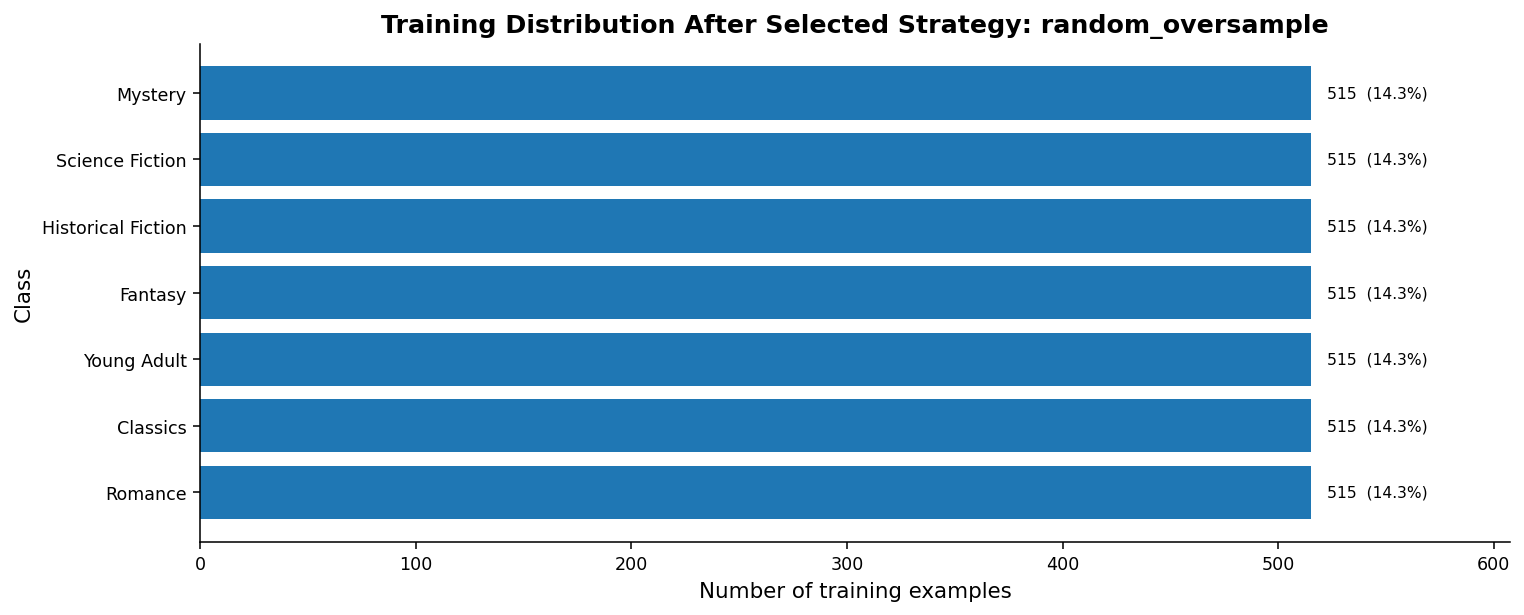

In [19]:
selected_train_rows = make_resampled_indices(
    y_train,
    strategy=SELECTED_IMBALANCE_STRATEGY,
    random_state=RANDOM_STATE,
)

y_train_selected = y_train[selected_train_rows]

X_tfidf_train_selected = X_tfidf_train[selected_train_rows]
X_emb_train_selected = X_emb_train[selected_train_rows]

selected_counts = Counter(label_encoder.inverse_transform(y_train_selected))

plot_horizontal_count_distribution(
    selected_counts,
    title=f"Training Distribution After Selected Strategy: {SELECTED_IMBALANCE_STRATEGY}",
    xlabel="Number of training examples",
)

## 12. Prepare dense TF-IDF features for the MLP

Train the MLP on dense TF-IDF vectors. Since full TF-IDF can have tens of thousands of columns, select the highest-variance TF-IDF features from the selected training set and convert only those columns to dense arrays.

Keep regular sparse TF-IDF vectors for Naive Bayes, kNN, and Logistic Regression.

In [20]:
n_dense_features = 3000

selected_tfidf_dense_columns = select_top_sparse_columns_by_variance(
    X_tfidf_train_selected,
    max_features=n_dense_features,
)

X_tfidf_dense_train = X_tfidf_train_selected[:, selected_tfidf_dense_columns].toarray()
X_tfidf_dense_dev = X_tfidf_dev[:, selected_tfidf_dense_columns].toarray()
X_tfidf_dense_test = X_tfidf_test[:, selected_tfidf_dense_columns].toarray()

selected_dense_feature_names = tfidf_vectorizer.get_feature_names_out()[selected_tfidf_dense_columns]

print("Dense TF-IDF train shape:", X_tfidf_dense_train.shape)
print("Selected dense TF-IDF features:", len(selected_dense_feature_names))
display(selected_dense_feature_names)

Dense TF-IDF train shape: (3605, 3000)
Selected dense TF-IDF features: 3000


array(['is', 'of the', 'his', ..., 'detective agency', 'diamond',
       'discussion of'], shape=(3000,), dtype=object)

## 13. Train the classification models

Train the required models on both representations where appropriate.

Required models:

- Naive Bayes
- kNN
- Logistic Regression
- MLP

In [21]:
trained_models = {}
dev_results = []


def train_dev_model(model_name, representation_name, model, X_train_current, y_train_current, X_dev_current, y_dev_current):
    metrics, train_seconds, predict_seconds, _ = fit_predict_and_score(model, X_train_current, y_train_current, X_dev_current, y_dev_current)

    key = f"{model_name} ({representation_name})"
    trained_models[key] = model

    dev_results.append({
        "representation": representation_name,
        "model": model_name,
        "imbalance_strategy": SELECTED_IMBALANCE_STRATEGY,
        "train_seconds": train_seconds,
        "dev_predict_seconds": predict_seconds,
        "dev_accuracy": metrics["accuracy"],
        "dev_macro_precision": metrics["macro_precision"],
        "dev_macro_recall": metrics["macro_recall"],
        "dev_macro_f1": metrics["macro_f1"],
        "dev_micro_f1": metrics["micro_f1"],
    })

    print(f"{key}")
    print(f"  dev accuracy : {metrics['accuracy']:.4f}")
    print(f"  dev macro-F1 : {metrics['macro_f1']:.4f}")
    print(f"  train seconds: {train_seconds:.2f}")
    print(f"  pred seconds : {predict_seconds:.2f}")
    print()

### 13.1 TF-IDF models

In [22]:
train_dev_model(
    model_name="MultinomialNB",
    representation_name="TF-IDF",
    model=ScratchMultinomialNB(alpha=1),
    X_train_current=X_tfidf_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_tfidf_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="kNN",
    representation_name="TF-IDF",
    model=ScratchKNNClassifier(n_neighbors=KNN_NEIGHBORS, metric="cosine"),
    X_train_current=X_tfidf_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_tfidf_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="Logistic Regression",
    representation_name="TF-IDF",
    model=ScratchSoftmaxLogisticRegression(
        learning_rate=LR_LEARNING_RATE,
        max_epochs=LR_MAX_EPOCHS,
        batch_size=LR_BATCH_SIZE,
        alpha=LR_ALPHA,
        random_state=RANDOM_STATE,
    ),
    X_train_current=X_tfidf_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_tfidf_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="MLP",
    representation_name="TF-IDF-dense",
    model=ScratchScaledClassifier(
        ScratchMLPClassifier(
            hidden_dim=MLP_HIDDEN_DIM,
            learning_rate=MLP_LEARNING_RATE,
            max_epochs=MLP_MAX_EPOCHS,
            batch_size=MLP_BATCH_SIZE,
            alpha=MLP_ALPHA,
            random_state=RANDOM_STATE,
        )
    ),
    X_train_current=X_tfidf_dense_train,
    y_train_current=y_train_selected,
    X_dev_current=X_tfidf_dense_dev,
    y_dev_current=y_dev,
)

MultinomialNB (TF-IDF)
  dev accuracy : 0.6104
  dev macro-F1 : 0.5724
  train seconds: 0.01
  pred seconds : 0.00

kNN (TF-IDF)
  dev accuracy : 0.5940
  dev macro-F1 : 0.5637
  train seconds: 0.01
  pred seconds : 0.08

Logistic Regression (TF-IDF)
  dev accuracy : 0.6049
  dev macro-F1 : 0.5721
  train seconds: 0.82
  pred seconds : 0.00

MLP (TF-IDF-dense)
  dev accuracy : 0.5940
  dev macro-F1 : 0.5183
  train seconds: 6.91
  pred seconds : 0.01



### 13.2 Sentence embedding models

In [23]:
train_dev_model(
    model_name="GaussianNB",
    representation_name="Sentence embedding",
    model=ScratchGaussianNB(var_smoothing=1e-9),
    X_train_current=X_emb_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_emb_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="kNN",
    representation_name="Sentence embedding",
    model=ScratchKNNClassifier(n_neighbors=KNN_NEIGHBORS, metric="cosine"),
    X_train_current=X_emb_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_emb_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="Logistic Regression",
    representation_name="Sentence embedding",
    model=ScratchScaledClassifier(
        ScratchSoftmaxLogisticRegression(
            learning_rate=LR_LEARNING_RATE,
            max_epochs=LR_MAX_EPOCHS,
            batch_size=LR_BATCH_SIZE,
            alpha=LR_ALPHA,
            random_state=RANDOM_STATE,
        )
    ),
    X_train_current=X_emb_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_emb_dev,
    y_dev_current=y_dev,
)

train_dev_model(
    model_name="MLP",
    representation_name="Sentence embedding",
    model=ScratchScaledClassifier(
        ScratchMLPClassifier(
            hidden_dim=MLP_HIDDEN_DIM,
            learning_rate=MLP_LEARNING_RATE,
            max_epochs=MLP_MAX_EPOCHS,
            batch_size=MLP_BATCH_SIZE,
            alpha=MLP_ALPHA,
            random_state=RANDOM_STATE,
        )
    ),
    X_train_current=X_emb_train_selected,
    y_train_current=y_train_selected,
    X_dev_current=X_emb_dev,
    y_dev_current=y_dev,
)

GaussianNB (Sentence embedding)
  dev accuracy : 0.6485
  dev macro-F1 : 0.6212
  train seconds: 0.03
  pred seconds : 0.02

kNN (Sentence embedding)
  dev accuracy : 0.7112
  dev macro-F1 : 0.6614
  train seconds: 0.01
  pred seconds : 0.06

Logistic Regression (Sentence embedding)
  dev accuracy : 0.7084
  dev macro-F1 : 0.6652
  train seconds: 1.75
  pred seconds : 0.00

MLP (Sentence embedding)
  dev accuracy : 0.7330
  dev macro-F1 : 0.6763
  train seconds: 1.80
  pred seconds : 0.00



## 14. Compare development results

Select the final model using development macro-F1.

In [24]:
dev_results_df = pd.DataFrame(dev_results)
dev_results_df = dev_results_df.sort_values("dev_macro_f1", ascending=False).reset_index(drop=True)
dev_results_df["model_label"] = dev_results_df["representation"] + "\n" + dev_results_df["model"]

display(dev_results_df)

,representation,model,imbalance_strategy,train_seconds,dev_predict_seconds,dev_accuracy,dev_macro_precision,dev_macro_recall,dev_macro_f1,dev_micro_f1,model_label
0,Sentence embedding,MLP,random_oversample,1.801306,0.003155,0.732970,0.687445,0.676888,0.676287,0.732970,Sentence embedding\nMLP
1,Sentence embedding,Logistic Regression,random_oversample,1.754384,0.002679,0.708447,0.672121,0.670327,0.665194,0.708447,Sentence embedding\nLogistic Regression
2,Sentence embedding,kNN,random_oversample,0.010829,0.061155,0.711172,0.651427,0.699147,0.661355,0.711172,Sentence embedding\nkNN
3,Sentence embedding,GaussianNB,random_oversample,0.027920,0.021272,0.648501,0.620767,0.634492,0.621155,0.648501,Sentence embedding\nGaussianNB
4,TF-IDF,MultinomialNB,random_oversample,0.006494,0.000505,0.610354,0.563504,0.606123,0.572395,0.610354,TF-IDF\nMultinomialNB
5,TF-IDF,Logistic Regression,random_oversample,0.822706,0.000184,0.604905,0.586068,0.581068,0.572105,0.604905,TF-IDF\nLogistic Regression
6,TF-IDF,kNN,random_oversample,0.009206,0.077588,0.594005,0.555173,0.605989,0.563742,0.594005,TF-IDF\nkNN
7,TF-IDF-dense,MLP,random_oversample,6.906091,0.007970,0.594005,0.540923,0.506808,0.518262,0.594005,TF-IDF-dense\nMLP


### Model comparison on the development set

Compare models and representations before touching the test set.



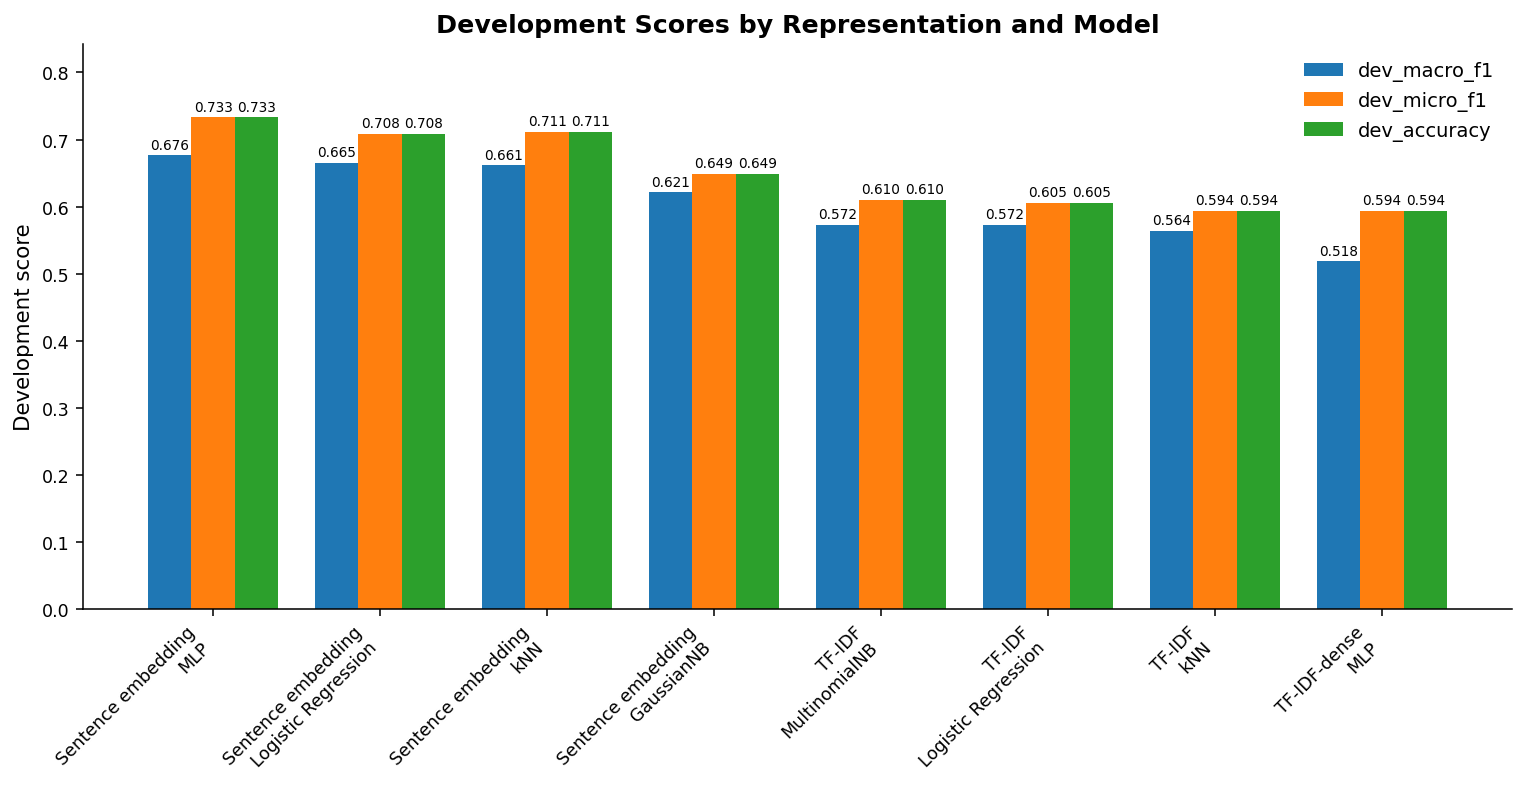

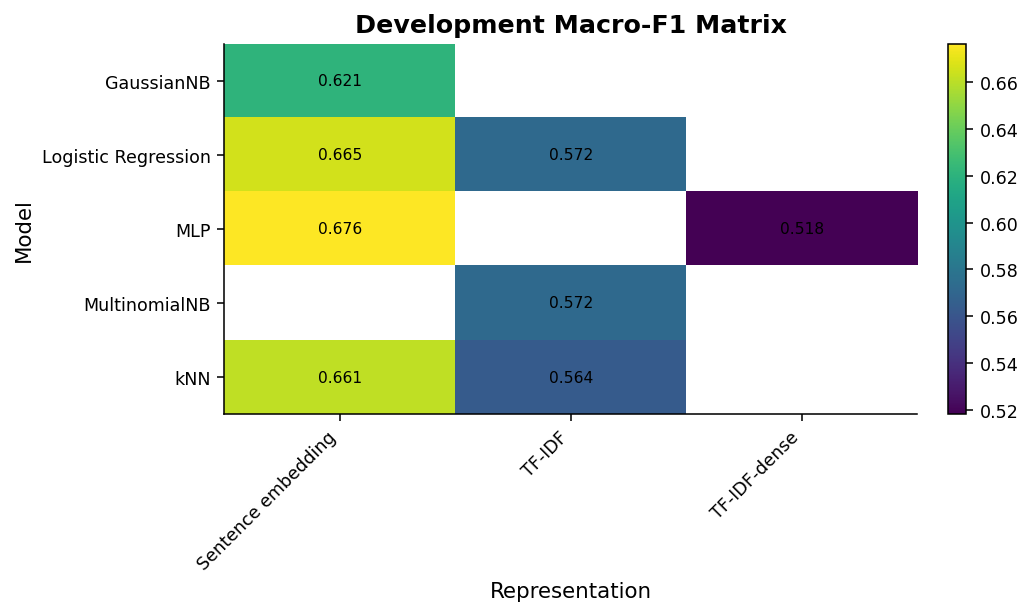

In [25]:
plot_grouped_metric_bars(
    dev_results_df,
    category_col="model_label",
    metric_cols=["dev_macro_f1", "dev_micro_f1", "dev_accuracy"],
    title="Development Scores by Representation and Model",
    ylabel="Development score",
    sort_by="dev_macro_f1",
    rotation=45,
)

macro_matrix = (
    dev_results_df
    .pivot_table(index="model", columns="representation", values="dev_macro_f1", aggfunc="max")
    .sort_index()
)

plot_metric_heatmap(
    macro_matrix,
    title="Development Macro-F1 Matrix",
    xlabel="Representation",
    ylabel="Model",
    value_format=".3f",
)

#### Which representation works better overall? Which model benefits most from sentence embeddings? Does the MLP improve results enough to justify its cost?

**Answer:** Sentence embeddings are the clear winner, beating TF-IDF across every single model. The MLP benefits the most from this change, jumping from the lowest score (0.518 macro-F1) on TF-IDF to the highest overall score (0.676 macro-F1) on embeddings. Furthermore, the MLP's cost is fully justified here. Because they share a very similar training time footprint. Since the training cost is comparable, the MLP is the definitive choice because it rewards us with the absolute highest development accuracy (0.733) and macro-F1 on the board.

### Accuracy/efficiency trade-off

Inspect training cost alongside model quality.



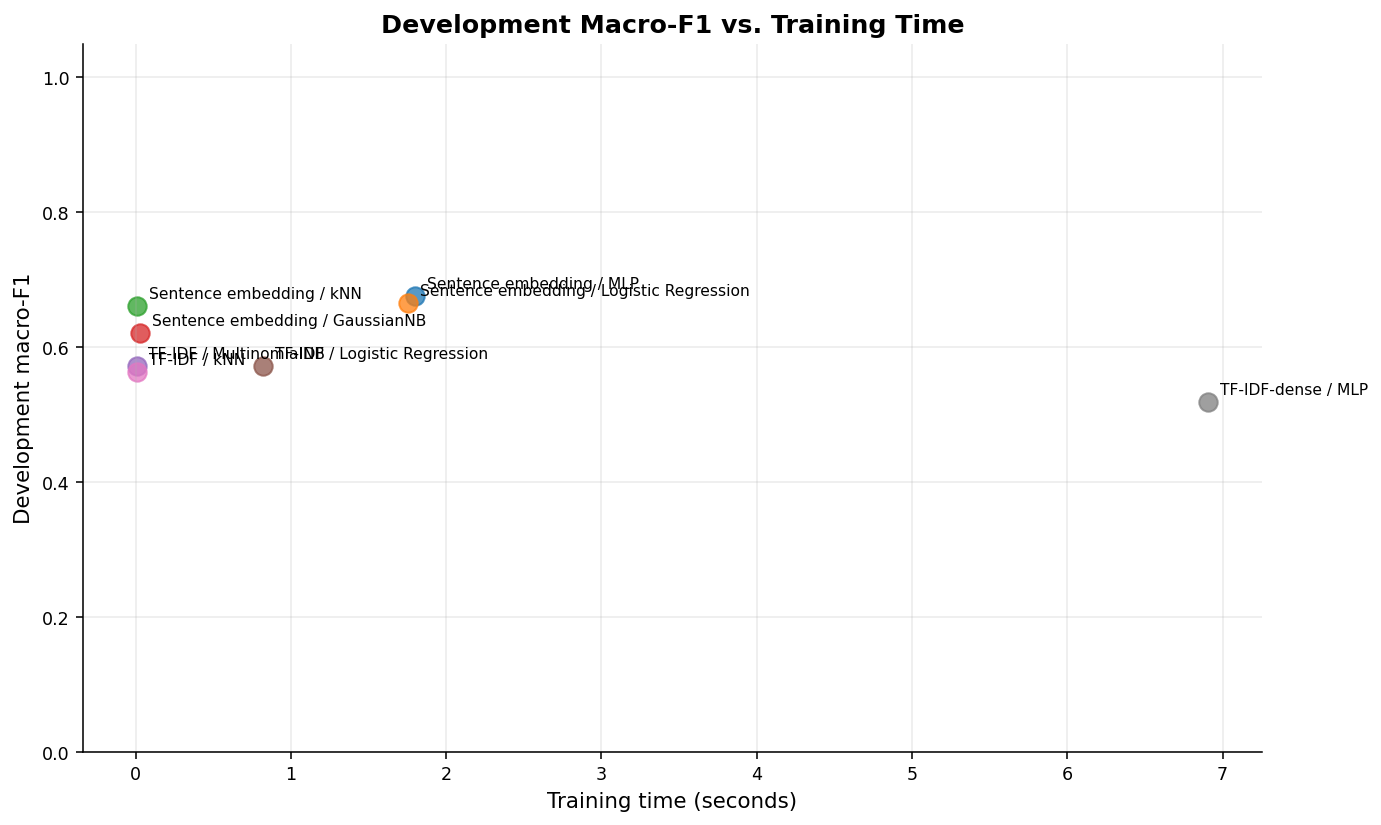

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in dev_results_df.iterrows():
    ax.scatter(row["train_seconds"], row["dev_macro_f1"], s=90, alpha=0.75)
    ax.annotate(
        row["model_label"].replace("\n", " / "),
        (row["train_seconds"], row["dev_macro_f1"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=8,
    )

ax.set_title("Development Macro-F1 vs. Training Time")
ax.set_xlabel("Training time (seconds)")
ax.set_ylabel("Development macro-F1")
ax.set_ylim(0, 1.05)
ax.grid(True)
plt.tight_layout()
plt.show()

#### Which model is the best trade-off between macro-F1 and training time?

**Answer:** Sentence embedding / kNN offers the absolute best trade-off on the chart. It trains instantly (0.01 seconds) while delivering an excellent 0.661 macro-F1 score. While the Sentence embedding / MLP achieves the absolute highest score overall (0.676), it requires nearly 1.8 seconds of training time. Getting within 1.5% of the top-performing neural network with zero training cost makes the kNN model the ultimate choice for maximum efficiency and high quality.

### Model selection

Answer the following questions:

1. Which model has the highest development macro-F1? The **MLP with Sentence embeddings** is the highest at 0.676.
2. Does the same model also have the highest micro-F1? **Yes.** It also has the highest micro-F1 at 0.733.
3. Which representation is stronger: TF-IDF or sentence embedding? **Sentence embeddings are much stronger.** Every single model performed significantly better using them instead of TF-IDF.
4. Does MLP improve over Logistic Regression? If yes, is the improvement large enough? Yes, it is worth it. The MLP beats Logistic Regression on all scores. Since both scratch models **take the exact same training time** (~1.8 seconds), the higher accuracy is a free win.
5. Which model should be selected for final test evaluation, and why? We choose the **Sentence embedding / MLP**. It gives the highest overall scores on the development set. Since it trains just as fast as Logistic Regression, it is the best choice for final testing.

## 15. Final test evaluation

Evaluate every trained model on the test set for reporting. Choose the main final model according to development macro-F1, not test performance.

In [27]:
def get_test_matrix_for_representation(representation_name):
	if representation_name == "TF-IDF":
		return X_tfidf_test
	if representation_name == "TF-IDF-dense":
		return X_tfidf_dense_test
	if representation_name == "Sentence embedding":
		return X_emb_test
	raise ValueError(f"Unknown representation: {representation_name}")


test_results = []

for _, row in dev_results_df.iterrows():
	representation_name = row["representation"]
	model_name = row["model"]
	key = f"{model_name} ({representation_name})"

	model = trained_models[key]
	X_test_current = get_test_matrix_for_representation(representation_name)

	start_time = time.time()
	y_pred_test_current = model.predict(X_test_current)
	test_predict_seconds = time.time() - start_time

	metrics = compute_metrics(y_test, y_pred_test_current)

	test_results.append({
		"representation": representation_name,
		"model": model_name,
		"imbalance_strategy": SELECTED_IMBALANCE_STRATEGY,
		"test_predict_seconds": test_predict_seconds,
		"test_accuracy": metrics["accuracy"],
		"test_macro_precision": metrics["macro_precision"],
		"test_macro_recall": metrics["macro_recall"],
		"test_macro_f1": metrics["macro_f1"],
		"test_micro_f1": metrics["micro_f1"],
	})

test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
test_results_df["model_label"] = test_results_df["representation"] + "\n" + test_results_df["model"]

display(test_results_df)

test_results_df.to_csv(OUTPUT_TEST_RESULTS_CSV, index=False)
print("Saved test results to:", OUTPUT_TEST_RESULTS_CSV)

,representation,model,imbalance_strategy,test_predict_seconds,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_micro_f1,model_label
0,Sentence embedding,kNN,random_oversample,0.071675,0.715426,0.661893,0.718131,0.676661,0.715426,Sentence embedding\nkNN
1,Sentence embedding,MLP,random_oversample,0.005904,0.726064,0.666794,0.670751,0.666302,0.726064,Sentence embedding\nMLP
2,Sentence embedding,Logistic Regression,random_oversample,0.002278,0.686170,0.629655,0.632532,0.630513,0.686170,Sentence embedding\nLogistic Regression
3,TF-IDF,MultinomialNB,random_oversample,0.000473,0.619681,0.574621,0.614423,0.586724,0.619681,TF-IDF\nMultinomialNB
4,Sentence embedding,GaussianNB,random_oversample,0.020431,0.635638,0.572061,0.587627,0.573294,0.635638,Sentence embedding\nGaussianNB
5,TF-IDF-dense,MLP,random_oversample,0.008163,0.603723,0.602753,0.532550,0.556706,0.603723,TF-IDF-dense\nMLP
6,TF-IDF,Logistic Regression,random_oversample,0.000283,0.587766,0.552215,0.568110,0.556144,0.587766,TF-IDF\nLogistic Regression
7,TF-IDF,kNN,random_oversample,0.067666,0.569149,0.530978,0.583954,0.547088,0.569149,TF-IDF\nkNN


Saved test results to: classification_test_results.csv


### Model comparison on the test set

Use this as the final report figure. Do not use it to go back and change model choices.



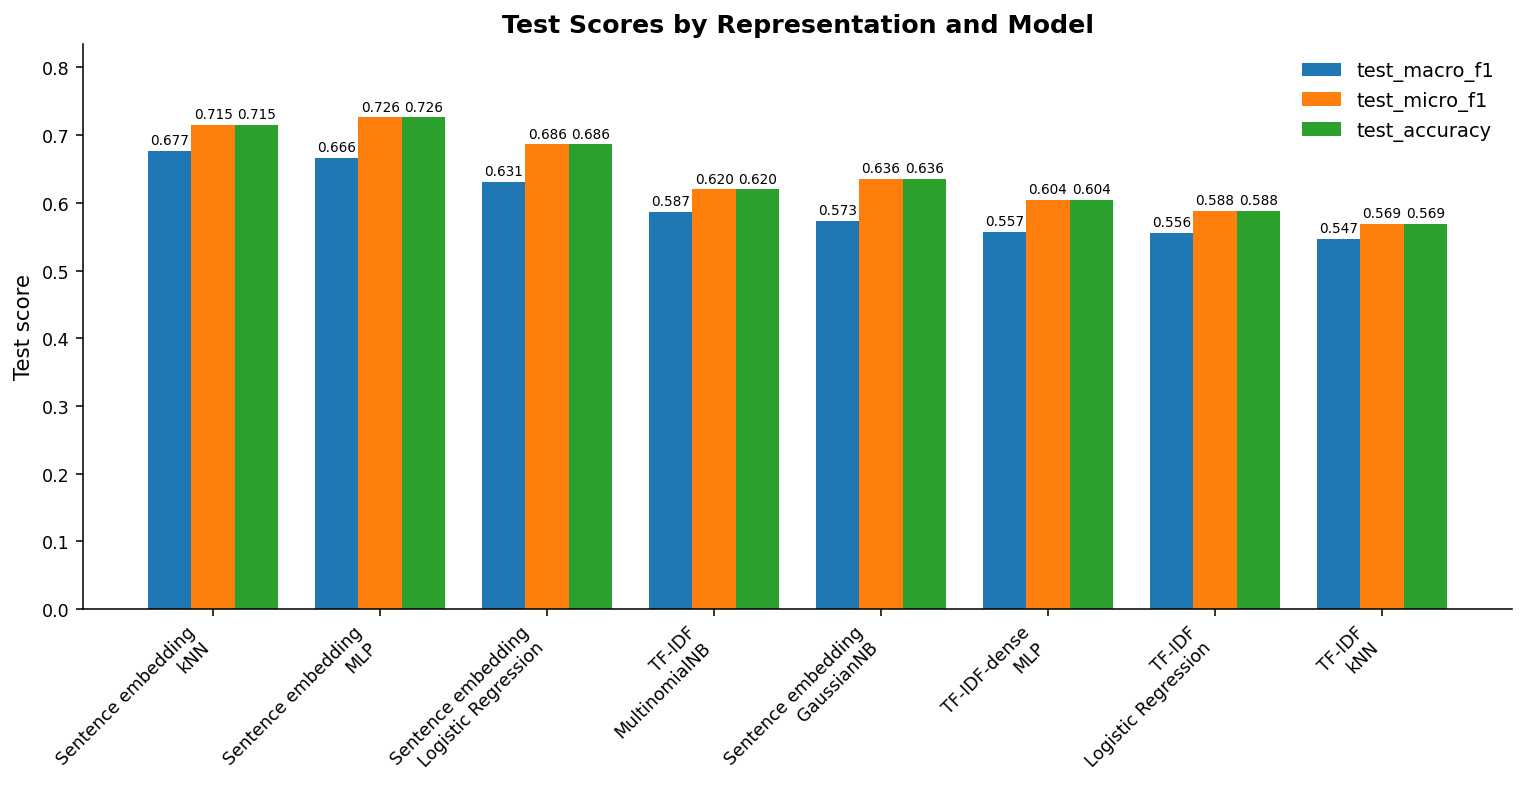

In [28]:
plot_grouped_metric_bars(
    test_results_df,
    category_col="model_label",
    metric_cols=["test_macro_f1", "test_micro_f1", "test_accuracy"],
    title="Test Scores by Representation and Model",
    ylabel="Test score",
    sort_by="test_macro_f1",
    rotation=45,
)

#### Are test results consistent with development results? Which model generalizes best?

**Answer:** Overall, the test results are mostly consistent because sentence embeddings still beat TF-IDF across the board. However, there is a small surprise at the top. The Sentence embedding / kNN model generalizes the best because its macro-F1 score actually increased from 0.661 on development to 0.677 on the test set. Meanwhile, the MLP and Logistic Regression scores both dropped on the test set, showing that they overfitted slightly to your development data.

## 16. Inspect the selected final model

Select the final model using development macro-F1, then inspect its test behavior.

In [30]:
best_dev_row = dev_results_df.loc[dev_results_df["dev_macro_f1"].idxmax()]
best_representation = best_dev_row["representation"]
best_model_name = best_dev_row["model"]
best_key = f"{best_model_name} ({best_representation})"

best_model = trained_models[best_key]
X_test_best = get_test_matrix_for_representation(best_representation)
y_pred_test = best_model.predict(X_test_best)

print("Best model selected using dev macro-F1:")
print(best_key)
print()
print("Selected imbalance strategy:", SELECTED_IMBALANCE_STRATEGY)
print()
print("Test classification report:")
print(classification_report_scratch(
    y_test,
    y_pred_test,
    target_names=class_names,
    digits=3,
))

Best model selected using dev macro-F1:
MLP (Sentence embedding)

Selected imbalance strategy: random_oversample

Test classification report:
                      precision     recall   f1-score    support
            Classics      0.741      0.733      0.737         86
             Fantasy      0.817      0.795      0.805        112
  Historical Fiction      0.674      0.690      0.682         42
             Mystery      0.755      0.816      0.784         49
             Romance      0.651      0.636      0.644         44
     Science Fiction      0.613      0.731      0.667         26
         Young Adult      0.417      0.294      0.345         17

            accuracy                            0.726        376
           macro avg      0.667      0.671      0.666        376
           micro avg      0.726      0.726      0.726        376


## 17. Confusion matrix

Inspect the row-normalized confusion matrix. Each cell shows count and row percentage.



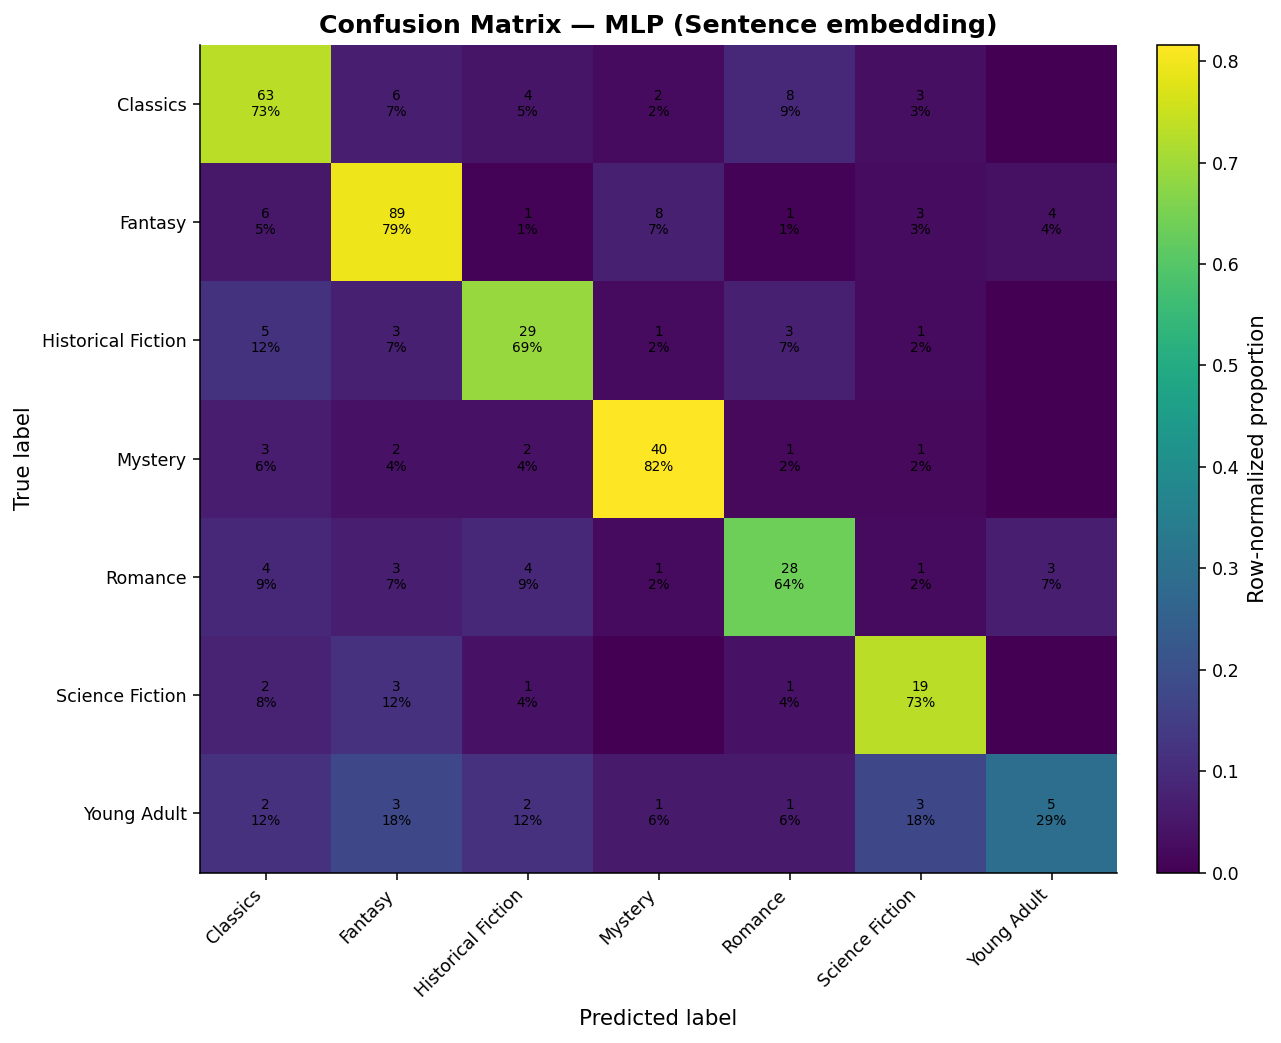

In [31]:
plot_confusion_matrix_professional(
    y_test,
    y_pred_test,
    class_names,
    title=f"Confusion Matrix — {best_key}",
)

#### Which genres are most often confused? Are these mistakes understandable from the descriptions?

**Answer:** The model mostly confuses **Mystery with Fantasy** and **Classics with Romance**. This happens because the book descriptions use very similar words. For example, many fantasy books involve finding dark secrets or solving magical crimes, which sounds like a detective mystery. Also, many famous classic books are actually deep love stories about relationships and feelings, just like romance books. Because these topics overlap so much, it is easy for the model to get them mixed up.

## 18. Per-class F1 analysis

Inspect final model quality per genre.



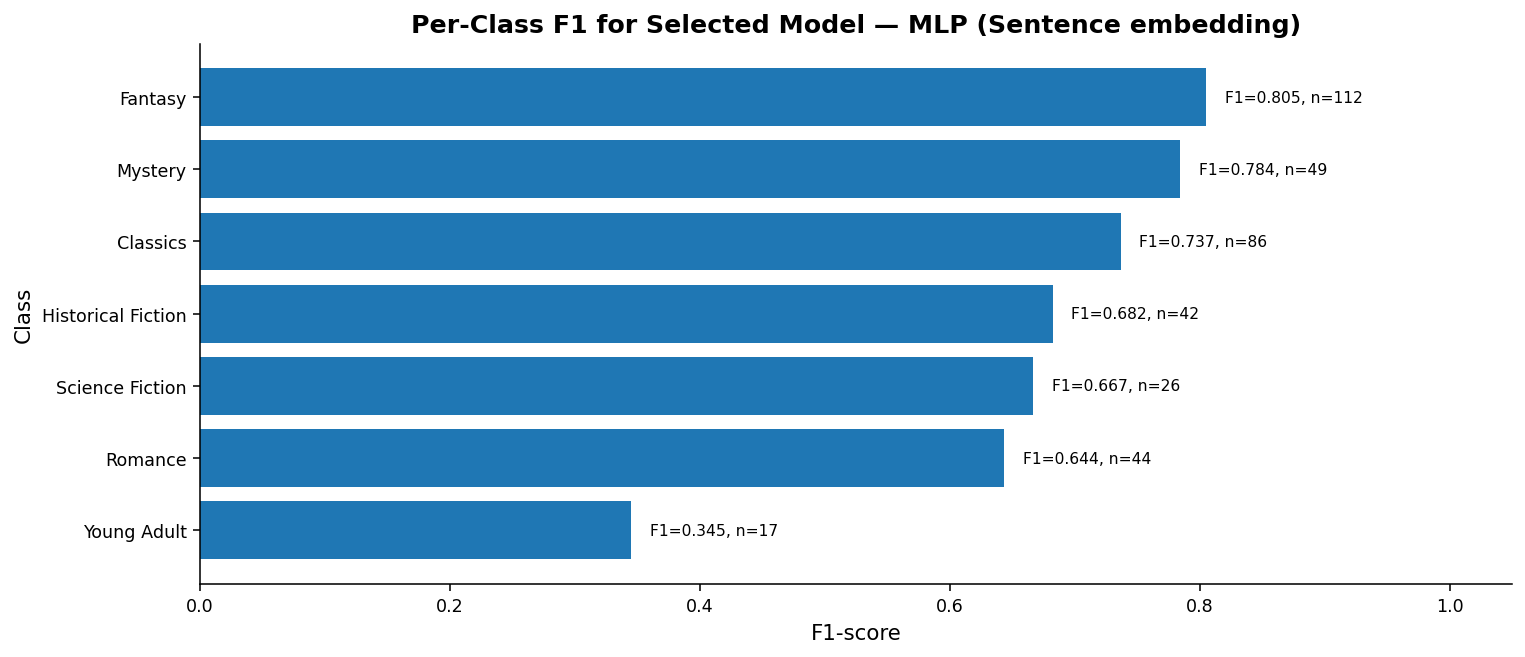

In [32]:
report = classification_report_scratch(
    y_test,
    y_pred_test,
    target_names=class_names,
    output_dict=True,
)

report_df = pd.DataFrame(report).T
class_report_df = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]]

plot_per_class_f1(
    class_report_df,
    title=f"Per-Class F1 for Selected Model — {best_key}",
)

#### Which classes are easiest? Which classes are hardest? Are weak classes also minority classes?

**Answer:** The easiest classes for the model are **Fantasy** and **Mystery** because they have the highest F1-scores. The hardest class by far is **Young Adult**, which has the lowest score. **Yes**, the weak classes are also the minority classes. Young Adult and Science Fiction have the fewest book examples in the dataset (lowest support), which makes it much tougher for the model to learn them well.

## 19. Error analysis

Inspect individual mistakes and common confusion pairs.

In [33]:
test_df = df_model.iloc[test_idx].copy()
test_df["true_label"] = label_encoder.inverse_transform(y_test)
test_df["predicted_label"] = label_encoder.inverse_transform(y_pred_test)
test_df["is_error"] = test_df["true_label"] != test_df["predicted_label"]

columns_to_show = ["true_label", "predicted_label", DESCRIPTION_COLUMN]
if TITLE_COLUMN in test_df.columns:
    columns_to_show = [TITLE_COLUMN] + columns_to_show

errors_df = test_df[test_df["is_error"]]

print("Number of test errors:", len(errors_df))
print("Test error rate:", len(errors_df) / len(test_df))

display(errors_df[columns_to_show].head(20))

Number of test errors: 103
Test error rate: 0.27393617021276595


,title,true_label,predicted_label,description
1371,The Eternity Code,Fantasy,Mystery,Book 3 in the < I>Artemis Fowl< /I> series< P>...
1036,Cold Mountain,Romance,Historical Fiction,This is the tie-in to the Bafta award-winning ...
1149,The Bluest Eye,Historical Fiction,Classics,",--back cover"
1423,The Moon is a Harsh Mistress,Fantasy,Science Fiction,Robert A. Heinlein was the most influential sc...
2142,The Physician,Romance,Fantasy,"In the 11th century, Rob Cole left poor, disea..."
2216,Sister Carrie,Classics,Romance,When small-town Carrie Meeber arrives in 1890s...
2068,Harvesting the Heart,Romance,Young Adult,Paige has only a few vivid memories of her mot...
786,A Study in Scarlet,Mystery,Historical Fiction,Purchase one of 1st World Library's Classic Bo...
1974,The Plot Against America,Science Fiction,Historical Fiction,"In an astonishing feat of narrative invention,..."
1926,Wayside School Is Falling Down,Fantasy,Young Adult,Louis yard teacher starts off 30 tales of unus...


### Most common confusion pairs

Use this plot to choose examples for manual error analysis.



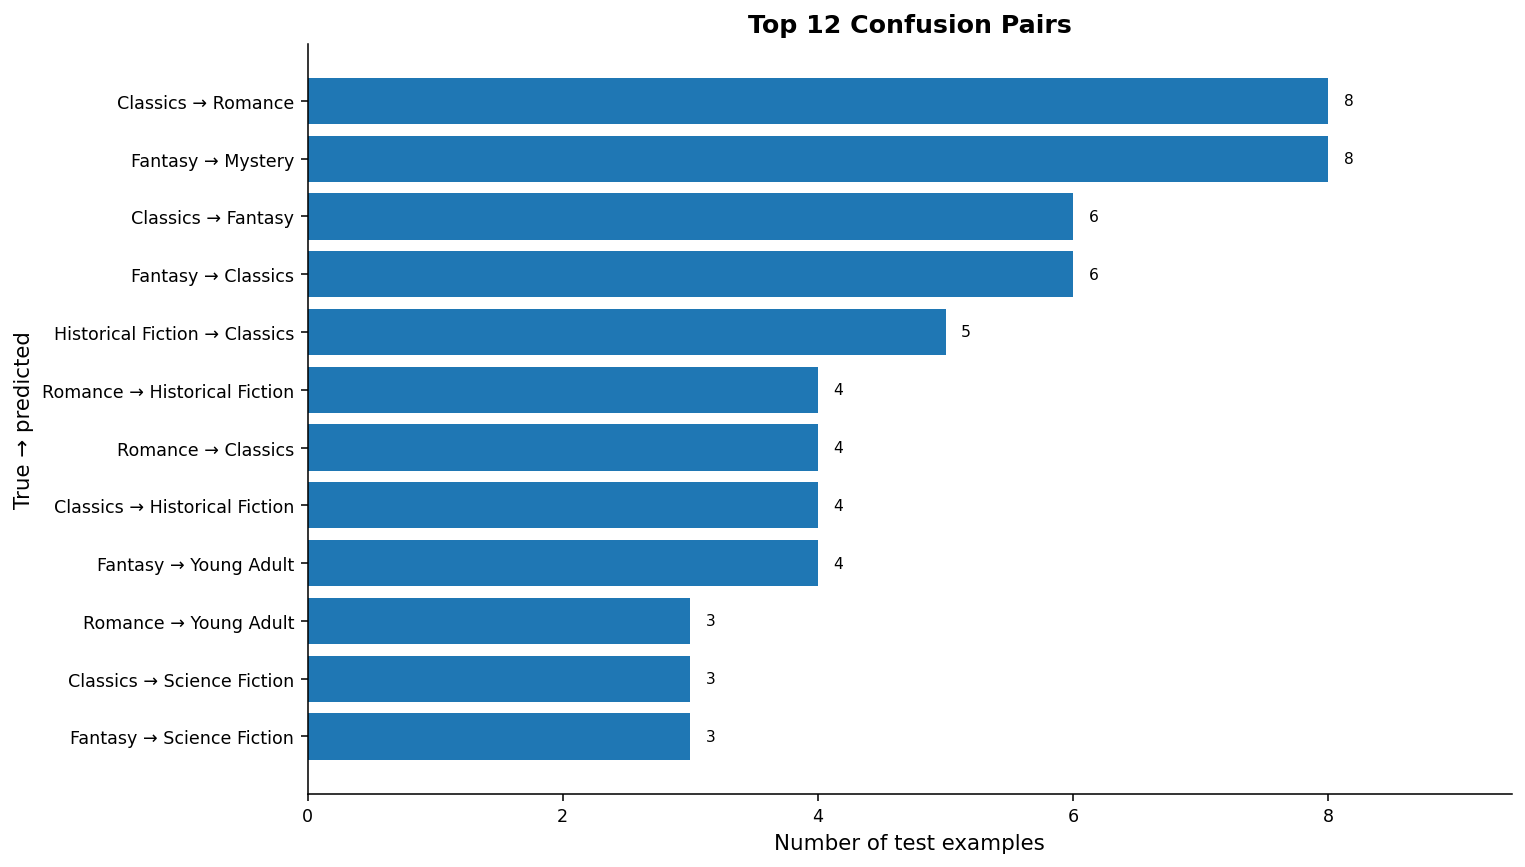

In [34]:
plot_confusion_pairs(errors_df, top_n=12)

#### Pick three confusion pairs. For each pair, inspect multiple examples and explain why the classifier may be confused.

**Answers:**
+ **Mystery and Fantasy:** Many fantasy books have characters who look for dark secrets or solve magical crimes. Because their descriptions use words like "secret," "search," and "truth," the model easily mistakes them for mystery books.

+ **Classics and Romance:** Famous classic books are often old love stories about marriage, family, and deep feelings. Because they use emotional words like "love," "passion," and "heart," the model frequently labels them as romance books.

+ **Historical Fiction and Classics:** Why it's confused: Both types of books take place in the past. Their descriptions use many of the same words to describe old time periods, historical events, and old-fashioned lifestyles, so the model easily gets them mixed up.

## 20. Interpret TF-IDF Logistic Regression features

Inspect the strongest positive terms for each class. This section is only available if TF-IDF Logistic Regression was trained.



In [35]:
tfidf_lr_key = "Logistic Regression (TF-IDF)"

if tfidf_lr_key in trained_models:
    lr_model = trained_models[tfidf_lr_key]
    feature_names = tfidf_vectorizer.get_feature_names_out()

    coef = lr_model.coef_
    rows = []

    for class_index, class_name in enumerate(class_names):
        weights = coef[class_index]
        top_indices = np.argsort(weights)[-10:][::-1]
        top_terms = [feature_names[i] for i in top_indices]
        top_weights = [weights[i] for i in top_indices]

        rows.append({
            "class": class_name,
            "top_terms": ", ".join(top_terms),
            "top_weights": ", ".join([f"{w:.3f}" for w in top_weights]),
        })

    top_features_df = pd.DataFrame(rows)
    display(top_features_df)
else:
    print("TF-IDF Logistic Regression was not trained.")

,class,top_terms,top_weights
0,Classics,"edition, dickens, greatest, social, of the, pu...","0.959, 0.718, 0.648, 0.618, 0.583, 0.559, 0.54..."
1,Fantasy,"king, evil, magic, tolkien, earth, greek, dark...","0.977, 0.952, 0.813, 0.652, 0.598, 0.584, 0.57..."
2,Historical Fiction,"hesse, novel, born, of two, ingalls, siddharth...","1.143, 0.936, 0.828, 0.783, 0.781, 0.700, 0.69..."
3,Mystery,"murder, detective, case, poirot, killer, myste...","1.754, 1.602, 1.295, 1.142, 1.035, 1.013, 0.94..."
4,Romance,"love, her, she, passion, elizabeth, the extrao...","1.852, 1.547, 1.084, 0.831, 0.783, 0.750, 0.71..."
5,Science Fiction,"future, world, vonnegut, where, vision, ender,...","1.874, 1.155, 1.057, 0.972, 0.972, 0.966, 0.92..."
6,Young Adult,"text, school, holden, play, me, boys, original...","1.530, 1.365, 1.340, 1.263, 1.122, 1.026, 0.91..."


#### Are the top terms meaningful for each class? Are there noisy or surprising terms?

**Answers:** Yes, the top terms are very meaningful because core words like `evil` and `magic` for Fantasy, `murder` and `detective` for Mystery, and `love` for Romance perfectly match each genre. However, there are also some surprising and noisy words. Instead of general words, the model picked up highly specific famous names like `Tolkien` and `Poirot` because those exact books are in the dataset. There are also a few generic, unhelpful terms like `of the` that slipped through as noise.

# Part 2: Book Description Clustering

In this part, cluster books using only their descriptions. The true genre labels are not used to form clusters; they are used only after clustering to evaluate and interpret the results.

Work with the same two representations from Part 1:

1. **TF-IDF** from the raw `description` text.
2. **Sentence embeddings** from the existing `description_emb` column.

Implement and compare:

- **K-Means**
- **Spherical K-Means**
- **DBSCAN**
- **Hierarchical Agglomerative Clustering**

The goal is to check whether unsupervised methods can recover meaningful groups of books and how those groups relate to the genre labels.


## 21. Clustering configuration

The clustering section uses smaller samples for the expensive algorithms. This keeps the notebook practical while still showing the behavior of each method.


In [41]:
# =========================
# Clustering settings
# =========================
CLUSTER_SAMPLE_SIZE = 2_000
CLUSTER_RANDOM_SEEDS = [RANDOM_STATE, RANDOM_STATE + 1]

CLUSTER_MAX_TFIDF_FEATURES = 12_000
CLUSTER_TFIDF_MIN_DF = 2
CLUSTER_TFIDF_MAX_DF = 0.8
CLUSTER_NGRAM_RANGE = (1, 2)

K_VALUES = sorted(set([5, 10, 15, 20, len(class_names)]))

KMEANS_MAX_ITER = 40
KMEANS_TOL = 1e-4

SILHOUETTE_SAMPLE_SIZE = 700
PCA_CLUSTER_MAX_POINTS = 1_500

DBSCAN_SAMPLE_SIZE = 800
DBSCAN_MIN_SAMPLES_VALUES = [5, 10]
DBSCAN_EPS_GRID = {
    "TF-IDF": [0.70, 0.80, 0.90, 0.95],
    "Sentence embedding": [0.15, 0.20, 0.25, 0.30, 0.35, 0.40],
}

HAC_SAMPLE_SIZE = 250
HAC_TARGET_K = min(len(class_names), 10)
HAC_LINKAGES = ["single", "complete", "average"]

CLUSTER_OUTPUT_RESULTS_CSV = "clustering_results.csv"
CLUSTER_OUTPUT_INTERPRETATION_CSV = "clustering_cluster_interpretation.csv"


## 22. Build the clustering dataset

Create a clustering sample, build a TF-IDF representation from scratch, and load the precomputed sentence embeddings.


In [37]:
rng = np.random.default_rng(RANDOM_STATE)

n_total = len(df_model)
cluster_sample_size = CLUSTER_SAMPLE_SIZE
cluster_indices = rng.choice(n_total, size=cluster_sample_size, replace=False)

df_cluster = df_model.iloc[cluster_indices].copy()
y_cluster = y_all[cluster_indices]
cluster_true_labels = as_1d_int_array(y_cluster)

print("Clustering sample size:", len(df_cluster))
print("Number of true genres:", len(class_names))

# Fit a separate scratch TF-IDF vectorizer for clustering.
# Clustering is unsupervised, so it is acceptable to fit this representation on the clustering sample.
clustering_tfidf_vectorizer = ScratchTfidfVectorizer(
    lowercase=True,
    ngram_range=CLUSTER_NGRAM_RANGE,
    min_df=CLUSTER_TFIDF_MIN_DF,
    max_df=CLUSTER_TFIDF_MAX_DF,
    max_features=CLUSTER_MAX_TFIDF_FEATURES,
    sublinear_tf=True,
    norm="l2",
)

cluster_texts = df_cluster[DESCRIPTION_COLUMN].values
X_cluster_tfidf_sparse = clustering_tfidf_vectorizer.fit_transform(cluster_texts)
cluster_tfidf_feature_names = clustering_tfidf_vectorizer.get_feature_names_out()

X_cluster_tfidf = X_cluster_tfidf_sparse.toarray()
X_cluster_tfidf_dense = safe_sparse_to_dense(X_cluster_tfidf)

X_cluster_emb = embedding_matrix[cluster_indices]

# Keep dense matrices for the clustering implementations below.
CLUSTER_REPRESENTATIONS = {
    "TF-IDF": X_cluster_tfidf_dense,
    "Sentence embedding": X_cluster_emb,
}

print("TF-IDF clustering matrix:", X_cluster_tfidf_dense.shape)
print("Sentence embedding clustering matrix:", X_cluster_emb.shape)


Clustering sample size: 2000
Number of true genres: 7


Fitting scratch TF-IDF:   0%|          | 0/2000 [00:00<?, ?it/s]

Transforming with scratch TF-IDF:   0%|          | 0/2000 [00:00<?, ?it/s]

TF-IDF clustering matrix: (2000, 12000)
Sentence embedding clustering matrix: (2000, 1024)


## 23. PCA visualization before clustering

Visualize both representations before running clustering. The colors are true genres, used only for interpretation.


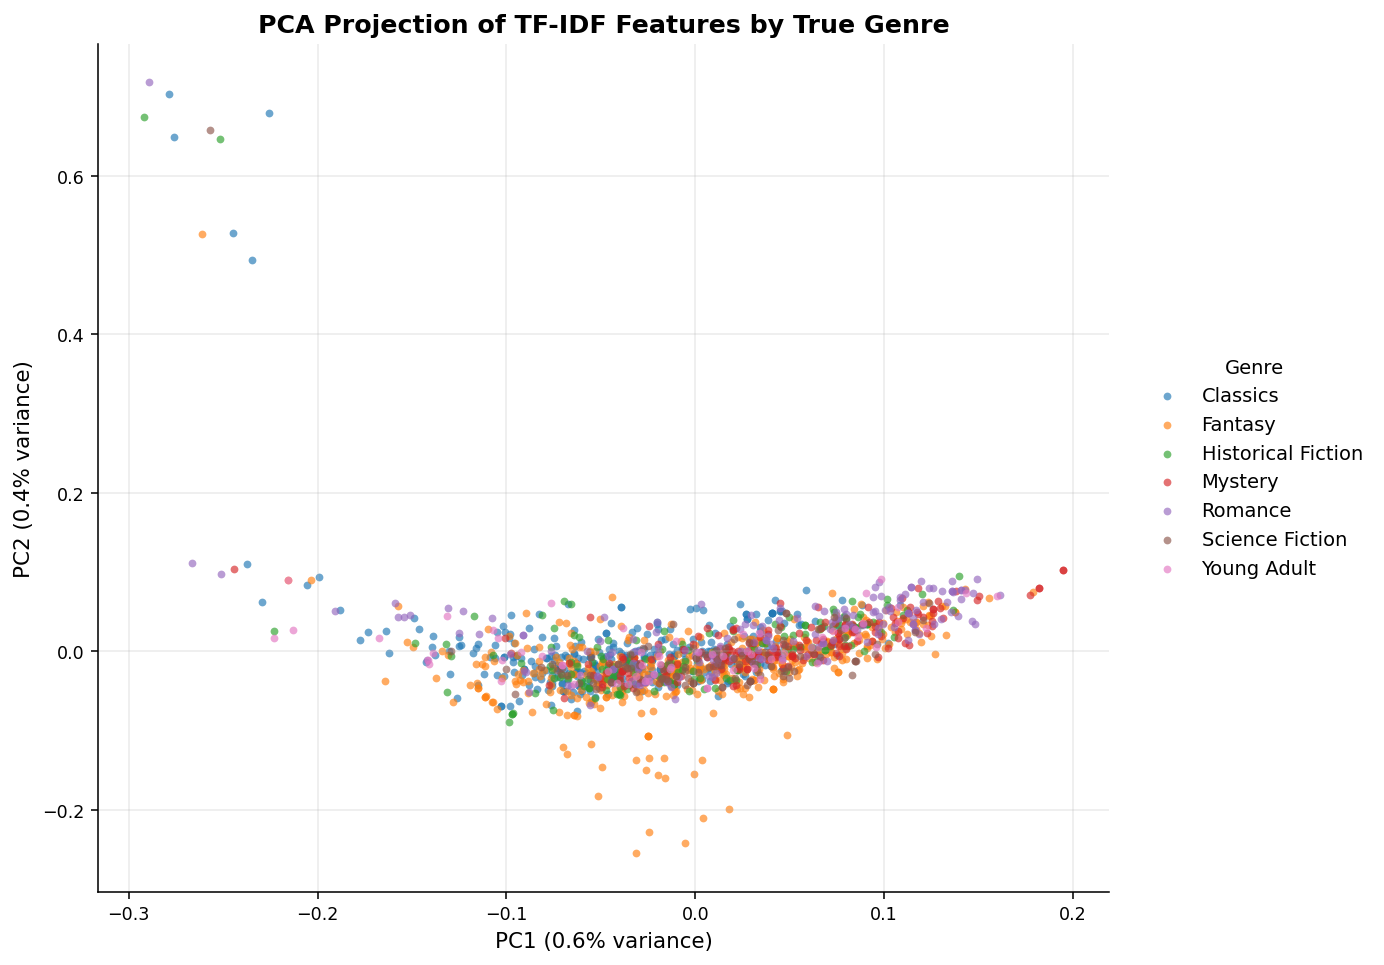

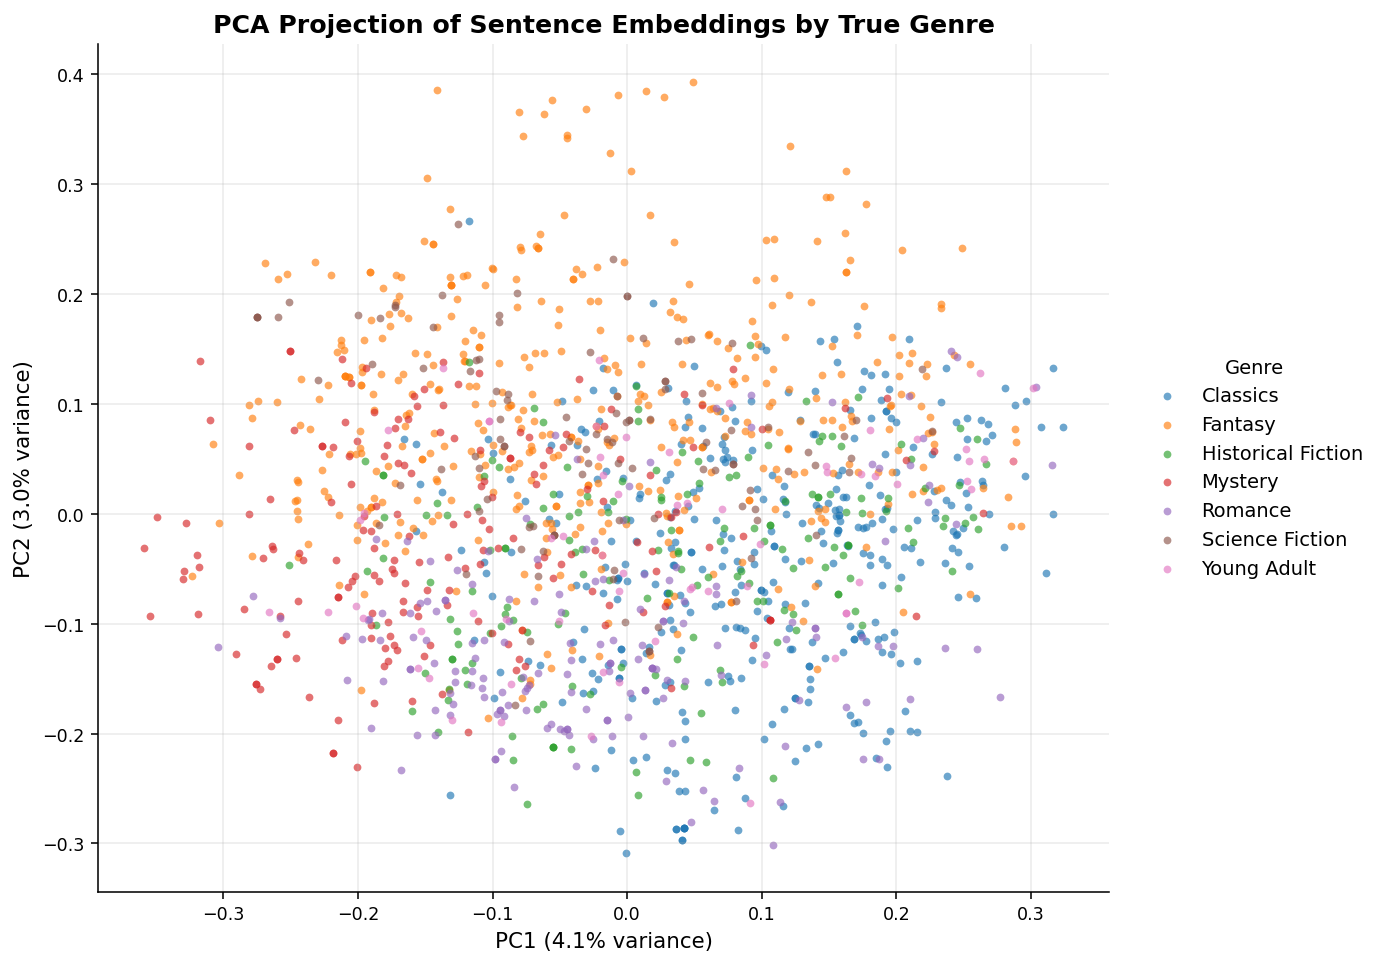

In [38]:
plot_pca_projection(
    X_cluster_tfidf_dense,
    y_cluster,
    class_names,
    title="PCA Projection of TF-IDF Features by True Genre",
    max_points=PCA_CLUSTER_MAX_POINTS,
    random_state=RANDOM_STATE,
)

plot_pca_projection(
    X_cluster_emb,
    y_cluster,
    class_names,
    title="PCA Projection of Sentence Embeddings by True Genre",
    max_points=PCA_CLUSTER_MAX_POINTS,
    random_state=RANDOM_STATE,
)


## 24. Clustering evaluation functions from scratch

Use internal metrics to evaluate the geometry of clusters and external metrics to compare clusters with true genres.


In [39]:
def pairwise_distance_matrix(X, metric="euclidean"):
	X = np.asarray(X, dtype=np.float32)

	if metric == "euclidean":
		sq_norms = np.sum(X**2, axis=1, keepdims=True)
		D2 = sq_norms + sq_norms.T - 2.0 * (X @ X.T)
		D2 = np.maximum(D2, 0.0)
		return np.sqrt(D2)

	if metric == "cosine":
		Xn = l2_normalize_rows(X)
		similarities = Xn @ Xn.T
		similarities = np.clip(similarities, -1.0, 1.0)
		D = 1.0 - similarities
		np.fill_diagonal(D, 0.0)
		return D

	raise ValueError(f"Unknown metric: {metric}")


def cluster_label_matrix(y_true, cluster_labels, ignore_noise=True):
	y_true = as_1d_int_array(y_true)
	cluster_labels = as_1d_int_array(cluster_labels)

	mask = np.ones_like(cluster_labels, dtype=bool)
	if ignore_noise:
		mask = cluster_labels != -1

	y = y_true[mask]
	z = cluster_labels[mask]

	unique_clusters = np.unique(z)
	unique_classes = np.unique(y)

	matrix = np.zeros((len(unique_clusters), len(unique_classes)), dtype=int)
	cluster_to_row = {cluster: i for i, cluster in enumerate(unique_clusters)}
	class_to_col = {cls: j for j, cls in enumerate(unique_classes)}

	for cluster, cls in zip(z, y):
		matrix[cluster_to_row[cluster], class_to_col[cls]] += 1

	return matrix, unique_clusters, unique_classes


def purity_score_scratch(y_true, cluster_labels, ignore_noise=True):
	matrix, _, _ = cluster_label_matrix(y_true, cluster_labels, ignore_noise)
	total = np.sum(matrix)
	if total == 0:
		return np.nan

	return float(np.sum(np.max(matrix, axis=1)) / total)


def entropy_from_counts(counts):
	counts = np.asarray(counts, dtype=np.float32)
	total = np.sum(counts)

	if total <= 0:
		return 0.0

	probs = counts[counts > 0] / total
	return float(-np.sum(probs * np.log(probs)))


def nmi_score_scratch(y_true, cluster_labels, ignore_noise=True):
	matrix, _, _ = cluster_label_matrix(y_true, cluster_labels, ignore_noise)
	n = np.sum(matrix)

	if n == 0:
		return np.nan

	cluster_counts = np.sum(matrix, axis=1)
	class_counts = np.sum(matrix, axis=0)

	mutual_info = 0.0
	for i in range(matrix.shape[0]):
		for j in range(matrix.shape[1]):
			nij = matrix[i, j]
			if nij > 0:
				mutual_info += (nij / n) * np.log((nij * n) / (cluster_counts[i] * class_counts[j]))

	h_clusters = entropy_from_counts(cluster_counts)
	h_classes = entropy_from_counts(class_counts)

	denominator = (h_clusters + h_classes) / 2.0
	if denominator <= 0:
		return np.nan

	return float(mutual_info / denominator)


def rand_index_scratch(y_true, cluster_labels, ignore_noise=True):
	y_true = as_1d_int_array(y_true)
	cluster_labels = as_1d_int_array(cluster_labels)

	mask = np.ones_like(cluster_labels, dtype=bool)
	if ignore_noise:
		mask = cluster_labels != -1

	y = y_true[mask]
	z = cluster_labels[mask]
	n = len(y)

	if n < 2:
		return np.nan

	agree = 0
	total = 0

	for i in range(n):
		same_true = (y[i+1:] == y[i])
		same_cluster = (z[i+1:] == z[i])
		agree += np.sum(same_true == same_cluster)
		total += len(same_true)

	return float(agree / total)


def silhouette_score_scratch(X, cluster_labels, metric="euclidean", max_points=700, random_state=42, ignore_noise=True):
    labels = np.asarray(cluster_labels)
    valid_mask = np.ones_like(labels, dtype=bool)

    if ignore_noise:
        valid_mask = labels != -1

    valid_positions = np.where(valid_mask)[0]
    if len(valid_positions) < 3:
        return np.nan

    valid_labels = labels[valid_mask]
    unique_labels = np.unique(valid_labels)

    if len(unique_labels) < 2:
        return np.nan

    rng = np.random.default_rng(random_state)
    if len(valid_positions) > max_points:
        valid_positions = rng.choice(valid_positions, size=max_points, replace=False)
        valid_positions = np.sort(valid_positions)

    X_sample = X[valid_positions]
    labels_sample = labels[valid_positions]

    unique_sample_labels = np.unique(labels_sample)
    if len(unique_sample_labels) < 2:
        return np.nan

    D = pairwise_distance_matrix(X_sample, metric=metric)

    silhouettes = []
    for i in range(len(X_sample)):
        own_label = labels_sample[i]
        own_mask = labels_sample == own_label

        if own_mask.sum() <= 1:
            silhouettes.append(0.0)
            continue

        a = D[i, own_mask].sum() / (own_mask.sum() - 1)

        b_values = []
        for other_label in unique_sample_labels:
            if other_label == own_label:
                continue
            other_mask = labels_sample == other_label
            b_values.append(D[i, other_mask].mean())

        b = min(b_values) if b_values else 0.0
        silhouettes.append((b - a) / max(a, b, 1e-12))

    return float(np.mean(silhouettes))


def evaluate_clustering_run(y_true, cluster_labels, X_for_silhouette, silhouette_metric, random_state=42):
	labels = as_1d_int_array(cluster_labels)
	non_noise_mask = labels != -1

	unique_non_noise = np.unique(labels[non_noise_mask])
	n_clusters = len(unique_non_noise)
	noise_ratio = float(np.sum(labels == -1) / len(labels)) if len(labels) > 0 else 0.0

	return {
		"n_clusters": n_clusters,
		"noise_ratio": noise_ratio,
		"silhouette": silhouette_score_scratch(
			X_for_silhouette,
			labels,
			metric=silhouette_metric,
			max_points=SILHOUETTE_SAMPLE_SIZE,
			random_state=random_state,
			ignore_noise=True,
		),
		"purity": purity_score_scratch(y_true, labels, ignore_noise=True),
		"nmi": nmi_score_scratch(y_true, labels, ignore_noise=True),
		"rand_index": rand_index_scratch(y_true, labels, ignore_noise=True),
	}


## 25. Plotting helpers for clustering


In [40]:
def plot_clustering_lines(results_df, metric, title):
    fig, ax = plt.subplots(figsize=(11, 6))

    grouped = results_df.groupby(["method", "representation", "k"], as_index=False)[metric].mean()

    for (method, representation), group in grouped.groupby(["method", "representation"]):
        group = group.sort_values("k")
        ax.plot(
            group["k"],
            group[metric],
            marker="o",
            linewidth=2,
            label=f"{method} / {representation}",
        )

    ax.set_title(title)
    ax.set_xlabel("Number of clusters K")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_cluster_size_distribution(labels, title):
    labels = pd.Series(labels)
    counts = labels.value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(counts.index.astype(str), counts.values, edgecolor="black", linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel("Cluster label")
    ax.set_ylabel("Number of books")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


def plot_cluster_pca(X, cluster_labels, title, max_points=1500, random_state=42):
    X = np.asarray(X)
    labels = np.asarray(cluster_labels)

    rng = np.random.default_rng(random_state)
    indices = np.arange(len(labels))

    if len(indices) > max_points:
        indices = rng.choice(indices, size=max_points, replace=False)
        indices = np.sort(indices)

    X_plot = X[indices]
    labels_plot = labels[indices]

    pca = PCA(n_components=2, random_state=random_state)
    coords = pca.fit_transform(X_plot)

    fig, ax = plt.subplots(figsize=(10, 7))

    unique_labels = np.array(sorted(pd.Series(labels_plot).unique()))
    for label in unique_labels:
        mask = labels_plot == label
        label_name = "noise" if label == -1 else f"cluster {label}"
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=18,
            alpha=0.72,
            label=label_name,
            edgecolors="none",
        )

    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.grid(True, alpha=0.25)

    if len(unique_labels) <= 20:
        ax.legend(loc="best", fontsize=8, markerscale=1.4)

    plt.tight_layout()
    plt.show()


def plot_cluster_genre_heatmap(y_true, cluster_labels, title, ignore_noise=True):
    matrix, cluster_values, class_values = cluster_label_matrix(
        y_true,
        cluster_labels,
        ignore_noise=ignore_noise,
    )

    if matrix.size == 0:
        print("No non-noise clusters to visualize.")
        return

    class_labels = [class_names[cls] for cls in class_values]
    cluster_labels_display = [f"Cluster {c}" for c in cluster_values]

    matrix_df = pd.DataFrame(matrix, index=cluster_labels_display, columns=class_labels)
    row_sums = matrix.sum(axis=1, keepdims=True)
    normalized_df = pd.DataFrame(matrix / np.where(row_sums == 0, 1, row_sums), index=cluster_labels_display, columns=class_labels)

    plot_metric_heatmap(
        normalized_df,
        title=title,
        xlabel="True genre",
        ylabel="Cluster",
        value_format=".2f",
    )


def plot_final_clustering_comparison(results_df, metric, title):
    plot_df = (
        results_df
        .dropna(subset=[metric])
        .sort_values(metric, ascending=False)
        .groupby(["method", "representation"], as_index=False)
        .head(1)
        .copy()
    )

    plot_df["label"] = plot_df["method"] + "\n" + plot_df["representation"]
    plot_df = plot_df.sort_values(metric)

    fig, ax = plt.subplots(figsize=(11, 6))
    bars = ax.barh(plot_df["label"], plot_df[metric], edgecolor="black", linewidth=0.6)

    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("Best run for each method/representation")
    ax.grid(axis="x", alpha=0.25)

    max_value = plot_df[metric].max()
    for bar in bars:
        width = bar.get_width()
        ax.text(width + max_value * 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()


## 26. K-Means from scratch

Implement standard K-Means and test several values of `K`.


In [42]:
class ScratchKMeans:
	def __init__(self, n_clusters, max_iter=40, tol=1e-4, random_state=42):
		self.n_clusters = int(n_clusters)
		self.max_iter = int(max_iter)
		self.tol = float(tol)
		self.random_state = random_state

	def _initialize_centroids(self, X):
		rng = np.random.default_rng(self.random_state)
		chosen = rng.choice(np.arange(X.shape[0]), size=self.n_clusters, replace=False)
		return X[chosen]

	def _squared_distances(self, X, centroids):
		x_norms = np.sum(X**2, axis=1, keepdims=True)  # Shape: (N, 1)
		c_norms = np.sum(centroids**2, axis=1, keepdims=True).T  # Shape: (1, K)
		distances = x_norms + c_norms - 2.0 * (X @ centroids.T)
		return np.maximum(distances, 0.0)

	def fit(self, X):
		X = np.asarray(X, dtype=np.float32)
		n_samples = X.shape[0]

		if self.n_clusters < 2:
			raise ValueError("n_clusters must be at least 2.")
		if self.n_clusters > n_samples:
			raise ValueError("n_clusters cannot be larger than the number of samples.")

		centroids = self._initialize_centroids(X)
		previous_inertia = np.inf

		for iteration in range(self.max_iter):
			distances = self._squared_distances(X, centroids)
			labels = np.argmin(distances, axis=1)
			inertia = float(np.sum(np.min(distances, axis=1)))

			new_centroids = np.zeros_like(centroids)
			for cluster_id in range(self.n_clusters):
				mask = labels == cluster_id
				if mask.any():
					new_centroids[cluster_id] = X[mask].mean(axis=0)
				else:
					# Reinitialize empty clusters to a random point.
					new_centroids[cluster_id] = X[np.random.default_rng(self.random_state + iteration).integers(0, n_samples)]

			centroid_shift = float(np.sqrt(np.sum((centroids - new_centroids) ** 2)))
			centroids = new_centroids

			if abs(previous_inertia - inertia) < self.tol or centroid_shift < self.tol:
				break

			previous_inertia = inertia

		self.cluster_centers_ = centroids
		self.labels_ = labels
		self.inertia_ = inertia
		self.n_iter_ = iteration + 1
		return self

	def predict(self, X):
		X = np.asarray(X, dtype=np.float32)
		distances = self._squared_distances(X, self.cluster_centers_)
		return np.argmin(distances, axis=1)

	def fit_predict(self, X):
		self.fit(X)
		return self.labels_


In [43]:
clustering_assignments = {}
kmeans_rows = []

valid_k_values = K_VALUES

for representation_name, X_current in CLUSTER_REPRESENTATIONS.items():
    for k in valid_k_values:
        for seed in CLUSTER_RANDOM_SEEDS:
            start_time = time.time()

            model = ScratchKMeans(
                n_clusters=k,
                max_iter=KMEANS_MAX_ITER,
                tol=KMEANS_TOL,
                random_state=seed
            )

            labels = model.fit_predict(X_current)
            seconds = time.time() - start_time

            metrics = evaluate_clustering_run(
                y_cluster,
                labels,
                X_current,
                silhouette_metric="euclidean",
                random_state=seed,
            )

            run_key = f"K-Means | {representation_name} | K={k} | seed={seed}"
            clustering_assignments[run_key] = {
                "labels": labels,
                "positions": np.arange(len(df_cluster)),
                "representation": representation_name,
                "method": "K-Means",
                "k": k,
                "seed": seed,
            }

            kmeans_rows.append({
                "run_key": run_key,
                "method": "K-Means",
                "representation": representation_name,
                "k": k,
                "seed": seed,
                "eps": np.nan,
                "min_samples": np.nan,
                "linkage": "",
                "seconds": seconds,
                "inertia": model.inertia_,
                **metrics,
            })

kmeans_results_df = pd.DataFrame(kmeans_rows)
display(kmeans_results_df.sort_values(["representation", "k", "seed"]).head(20))


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,silhouette,purity,nmi,rand_index
10,K-Means | Sentence embedding | K=5 | seed=42,K-Means,Sentence embedding,5,42,NaN,NaN,,0.299173,940.503540,5,0.0,0.023654,0.4570,0.185665,0.718065
11,K-Means | Sentence embedding | K=5 | seed=43,K-Means,Sentence embedding,5,43,NaN,NaN,,0.173058,940.322388,5,0.0,0.023120,0.4725,0.198160,0.727474
12,K-Means | Sentence embedding | K=7 | seed=42,K-Means,Sentence embedding,7,42,NaN,NaN,,0.276257,925.622559,7,0.0,0.022233,0.4780,0.208423,0.749368
13,K-Means | Sentence embedding | K=7 | seed=43,K-Means,Sentence embedding,7,43,NaN,NaN,,0.113904,926.025330,7,0.0,0.022478,0.4605,0.201353,0.730706
14,K-Means | Sentence embedding | K=10 | seed=42,K-Means,Sentence embedding,10,42,NaN,NaN,,0.248530,907.419434,10,0.0,0.023558,0.4880,0.209348,0.772447
15,K-Means | Sentence embedding | K=10 | seed=43,K-Means,Sentence embedding,10,43,NaN,NaN,,0.166157,910.304688,10,0.0,0.020007,0.5015,0.198423,0.766856
16,K-Means | Sentence embedding | K=15 | seed=42,K-Means,Sentence embedding,15,42,NaN,NaN,,0.143967,890.224731,15,0.0,0.025117,0.5230,0.233298,0.789226
17,K-Means | Sentence embedding | K=15 | seed=43,K-Means,Sentence embedding,15,43,NaN,NaN,,0.198680,888.637268,15,0.0,0.024584,0.5385,0.233557,0.790137
18,K-Means | Sentence embedding | K=20 | seed=42,K-Means,Sentence embedding,20,42,NaN,NaN,,0.107926,873.722778,20,0.0,0.025386,0.5235,0.220579,0.791935
19,K-Means | Sentence embedding | K=20 | seed=43,K-Means,Sentence embedding,20,43,NaN,NaN,,0.117822,874.948608,20,0.0,0.023894,0.5550,0.241535,0.795514


### K-Means visual comparison


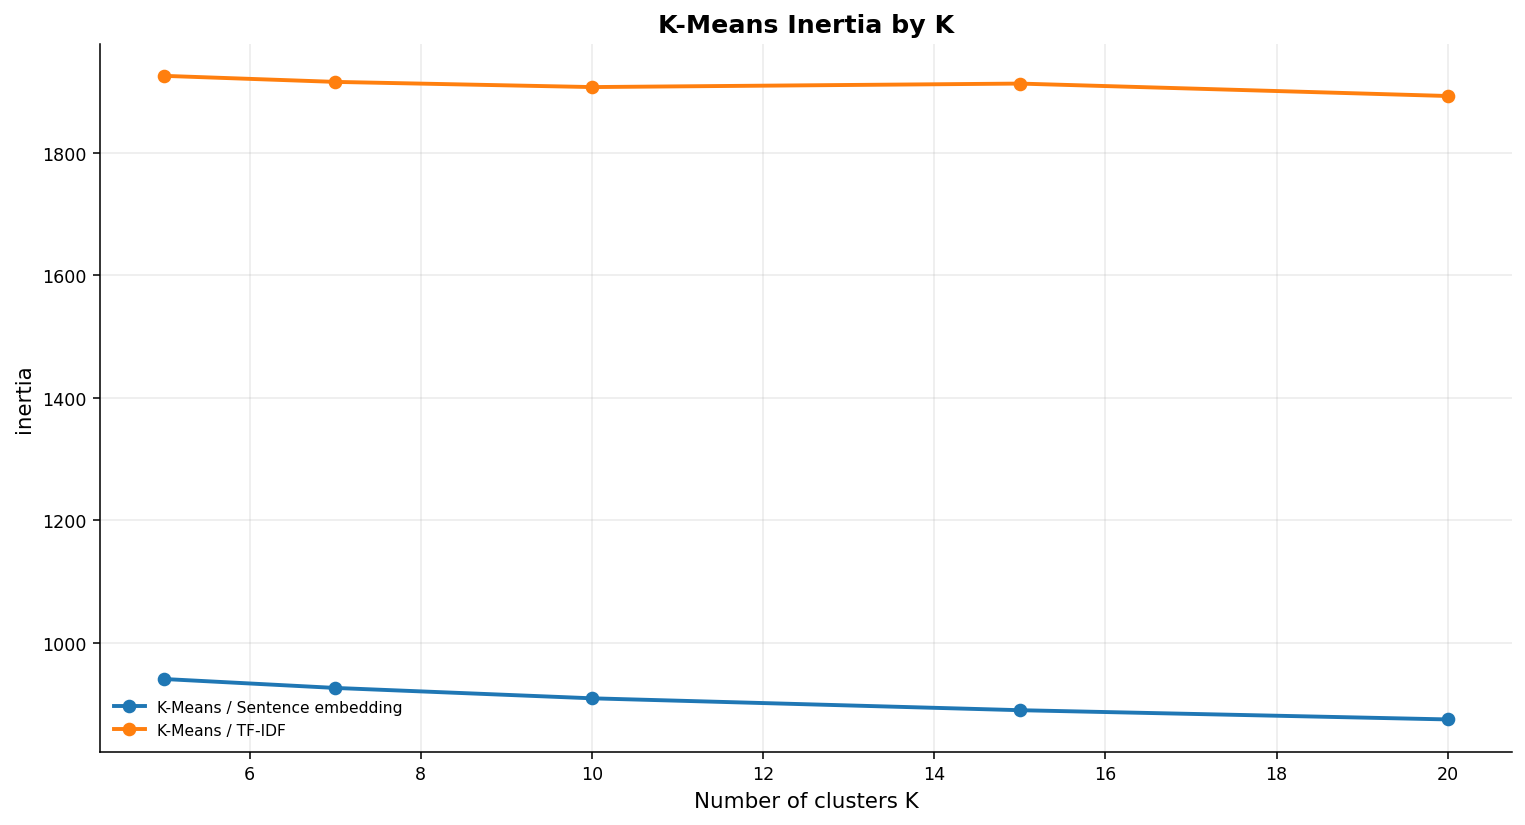

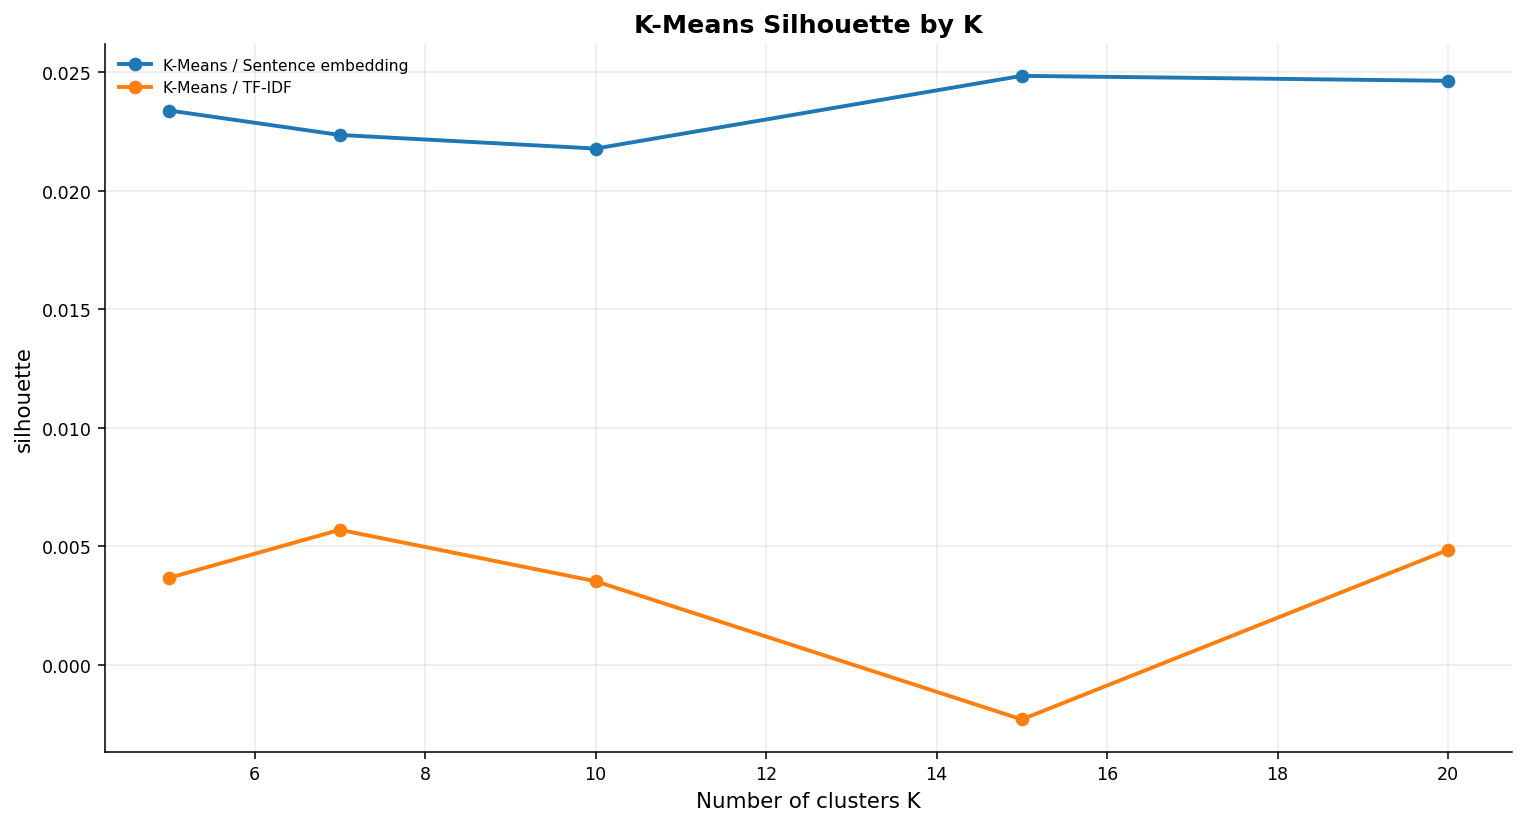

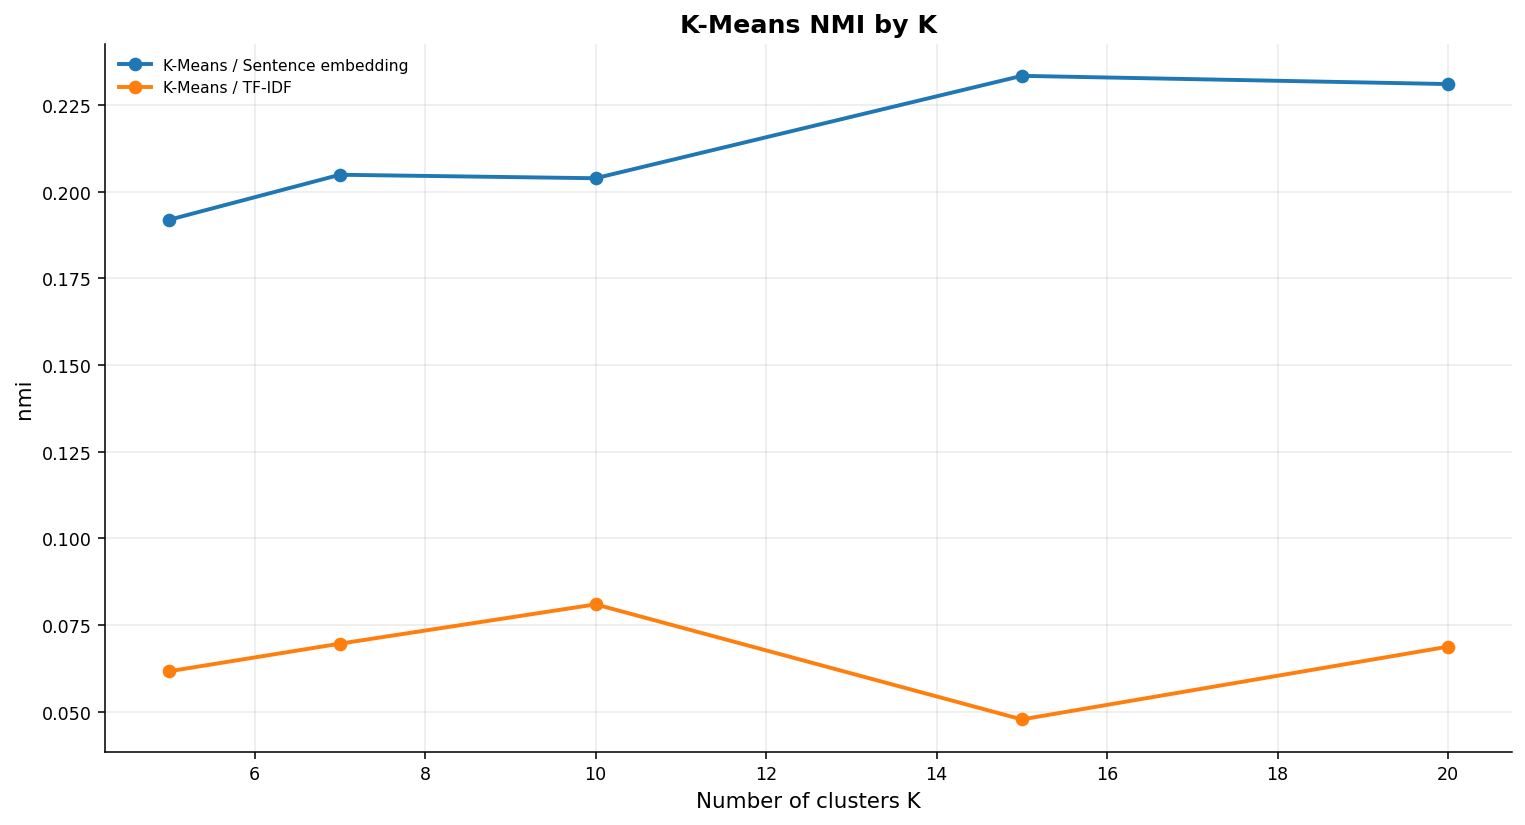

In [44]:
plot_clustering_lines(
    kmeans_results_df,
    metric="inertia",
    title="K-Means Inertia by K",
)

plot_clustering_lines(
    kmeans_results_df,
    metric="silhouette",
    title="K-Means Silhouette by K",
)

plot_clustering_lines(
    kmeans_results_df,
    metric="nmi",
    title="K-Means NMI by K",
)


#### Which `K` gives the best internal score? Which `K` gives the best agreement with the true genres?

**Answer:** K = 20 wins on the math scores and shows the highest overall agreement with your categories. This happens because breaking the books into 20 smaller, highly specific groups makes it much easier for the algorithm to lock onto similar stories. However, since we know there are exactly 7 true genres in the data, choosing K = 7 is the most realistic and meaningful choice for the big picture. It provides a great balance, keeping the main genres intact instead of over-splitting them into tiny sub-groups.

## 27. Spherical K-Means from scratch

Spherical K-Means normalizes vectors and assigns documents by cosine similarity. This is often more appropriate for text data.


In [45]:
class ScratchSphericalKMeans:
	def __init__(self, n_clusters, max_iter=40, tol=1e-4, random_state=42):
		self.n_clusters = int(n_clusters)
		self.max_iter = int(max_iter)
		self.tol = float(tol)
		self.random_state = random_state

	def _initialize_centroids(self, X):
		rng = np.random.default_rng(self.random_state)
		chosen = rng.choice(np.arange(X.shape[0]), size=self.n_clusters, replace=False)
		return X[chosen]

	def fit(self, X):
		X = np.asarray(X, dtype=np.float32)
		X = l2_normalize_rows(X)
		n_samples = X.shape[0]

		if self.n_clusters < 2:
			raise ValueError("n_clusters must be at least 2.")
		if self.n_clusters > n_samples:
			raise ValueError("n_clusters cannot be larger than the number of samples.")

		centroids = self._initialize_centroids(X)
		previous_cost = np.inf

		for iteration in range(self.max_iter):
			similarities = X @ centroids.T
			labels = np.argmax(similarities, axis=1)
			max_similarities = np.max(similarities, axis=1)
			cost = float(np.sum(1.0 - max_similarities))

			new_centroids = centroids.copy()
			for cluster_id in range(self.n_clusters):
				mask = labels == cluster_id
				if mask.any():
					new_centroids[cluster_id] = X[mask].mean(axis=0)
				else:
					new_centroids[cluster_id] = X[np.random.default_rng(self.random_state + iteration).integers(0, n_samples)]

			new_centroids = l2_normalize_rows(new_centroids)
			centroid_shift = float(np.sqrt(np.sum((centroids - new_centroids) ** 2)))
			centroids = new_centroids

			if abs(previous_cost - cost) < self.tol or centroid_shift < self.tol:
				break

			previous_cost = cost

		self.cluster_centers_ = centroids
		self.labels_ = labels
		self.inertia_ = cost
		self.n_iter_ = iteration + 1
		return self

	def predict(self, X):
		X = np.asarray(X, dtype=np.float32)
		X = l2_normalize_rows(X)
		
		similarities = X @ self.cluster_centers_.T
		return np.argmax(similarities, axis=1)

	def fit_predict(self, X):
		self.fit(X)
		return self.labels_


In [46]:
spherical_rows = []

for representation_name, X_current in CLUSTER_REPRESENTATIONS.items():
    for k in valid_k_values:
        for seed in CLUSTER_RANDOM_SEEDS:
            start_time = time.time()

            model = ScratchSphericalKMeans(
                n_clusters=k,
                max_iter=KMEANS_MAX_ITER,
                tol=KMEANS_TOL,
                random_state=seed
            )

            labels = model.fit_predict(X_current)
            seconds = time.time() - start_time

            metrics = evaluate_clustering_run(
                y_cluster,
                labels,
                X_current,
                silhouette_metric="cosine",
                random_state=seed,
            )

            run_key = f"Spherical K-Means | {representation_name} | K={k} | seed={seed}"
            clustering_assignments[run_key] = {
                "labels": labels,
                "positions": np.arange(len(df_cluster)),
                "representation": representation_name,
                "method": "Spherical K-Means",
                "k": k,
                "seed": seed,
            }

            spherical_rows.append({
                "run_key": run_key,
                "method": "Spherical K-Means",
                "representation": representation_name,
                "k": k,
                "seed": seed,
                "eps": np.nan,
                "min_samples": np.nan,
                "linkage": "",
                "seconds": seconds,
                "inertia": model.inertia_,
                **metrics,
            })

spherical_results_df = pd.DataFrame(spherical_rows)
display(spherical_results_df.sort_values(["representation", "k", "seed"]).head(20))


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,silhouette,purity,nmi,rand_index
10,Spherical K-Means | Sentence embedding | K=5 |...,Spherical K-Means,Sentence embedding,5,42,NaN,NaN,,0.224841,544.256165,5,0.0,0.045759,0.4605,0.190020,0.720085
11,Spherical K-Means | Sentence embedding | K=5 |...,Spherical K-Means,Sentence embedding,5,43,NaN,NaN,,0.146437,544.210266,5,0.0,0.044249,0.4710,0.200135,0.726329
12,Spherical K-Means | Sentence embedding | K=7 |...,Spherical K-Means,Sentence embedding,7,42,NaN,NaN,,0.210915,534.614502,7,0.0,0.041733,0.4725,0.203117,0.748480
13,Spherical K-Means | Sentence embedding | K=7 |...,Spherical K-Means,Sentence embedding,7,43,NaN,NaN,,0.147205,534.815247,7,0.0,0.043330,0.4640,0.202652,0.733330
14,Spherical K-Means | Sentence embedding | K=10 ...,Spherical K-Means,Sentence embedding,10,42,NaN,NaN,,0.165979,522.576904,10,0.0,0.044240,0.4940,0.210524,0.771485
15,Spherical K-Means | Sentence embedding | K=10 ...,Spherical K-Means,Sentence embedding,10,43,NaN,NaN,,0.109255,525.073547,10,0.0,0.040405,0.5115,0.202305,0.767976
16,Spherical K-Means | Sentence embedding | K=15 ...,Spherical K-Means,Sentence embedding,15,42,NaN,NaN,,0.143259,509.268524,15,0.0,0.048528,0.5350,0.240941,0.789175
17,Spherical K-Means | Sentence embedding | K=15 ...,Spherical K-Means,Sentence embedding,15,43,NaN,NaN,,0.124770,509.450806,15,0.0,0.047006,0.5395,0.235355,0.789772
18,Spherical K-Means | Sentence embedding | K=20 ...,Spherical K-Means,Sentence embedding,20,42,NaN,NaN,,0.058364,498.986542,20,0.0,0.047839,0.5325,0.226664,0.792402
19,Spherical K-Means | Sentence embedding | K=20 ...,Spherical K-Means,Sentence embedding,20,43,NaN,NaN,,0.094863,500.495422,20,0.0,0.041407,0.5510,0.242955,0.795942


### K-Means vs. Spherical K-Means


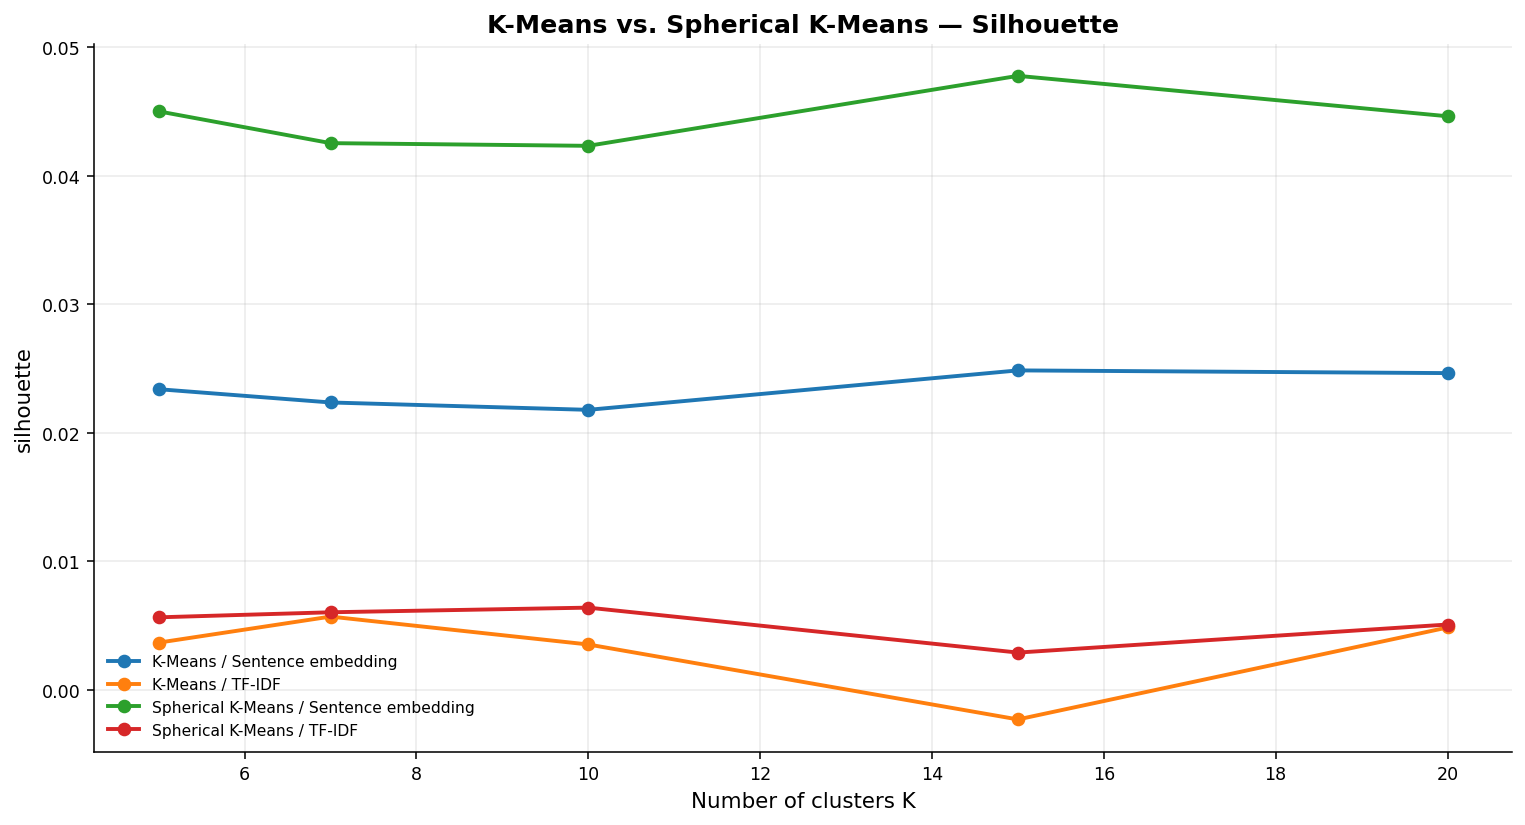

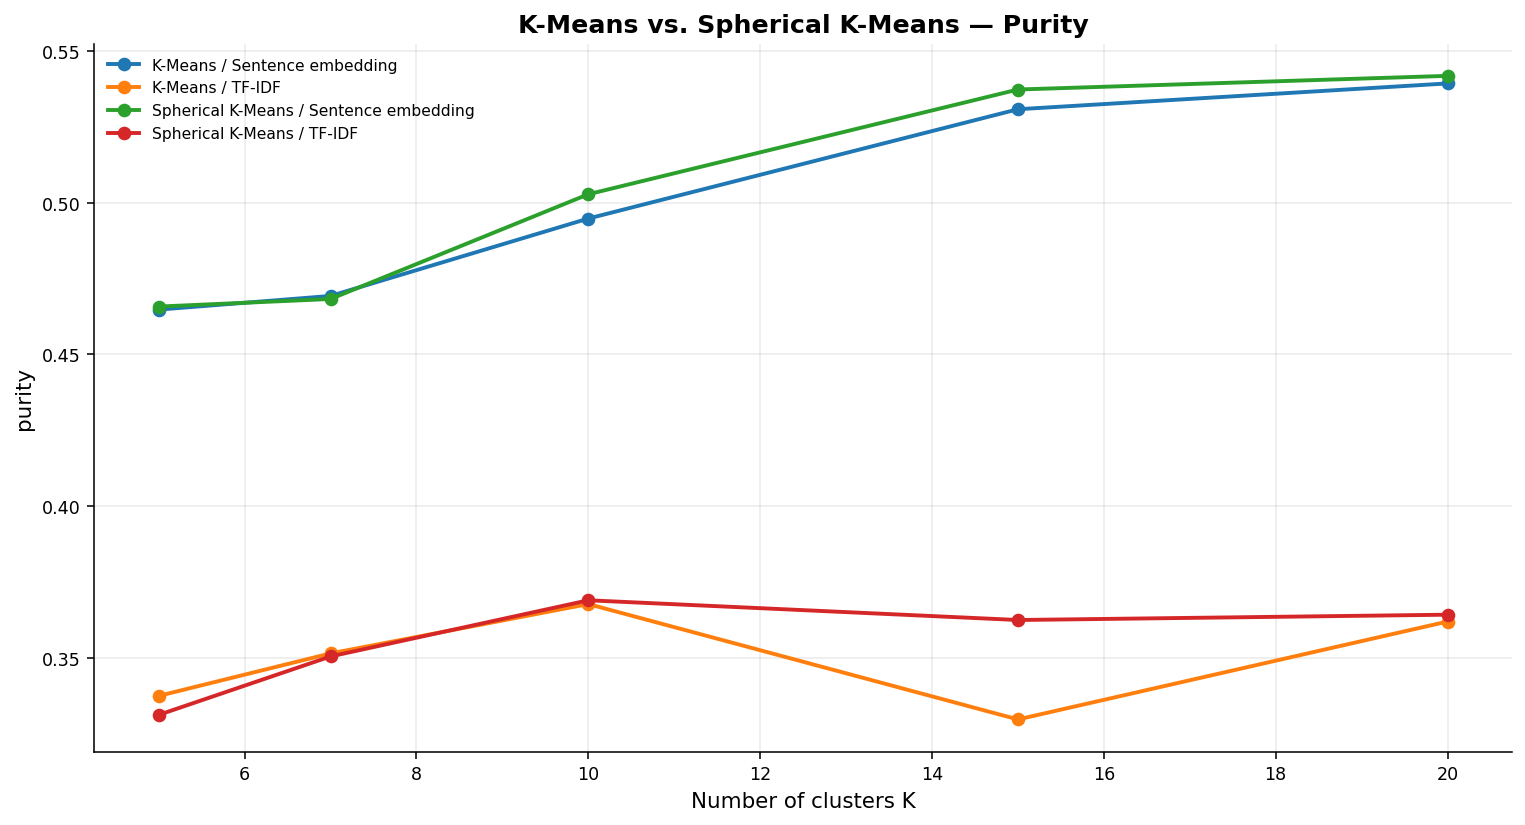

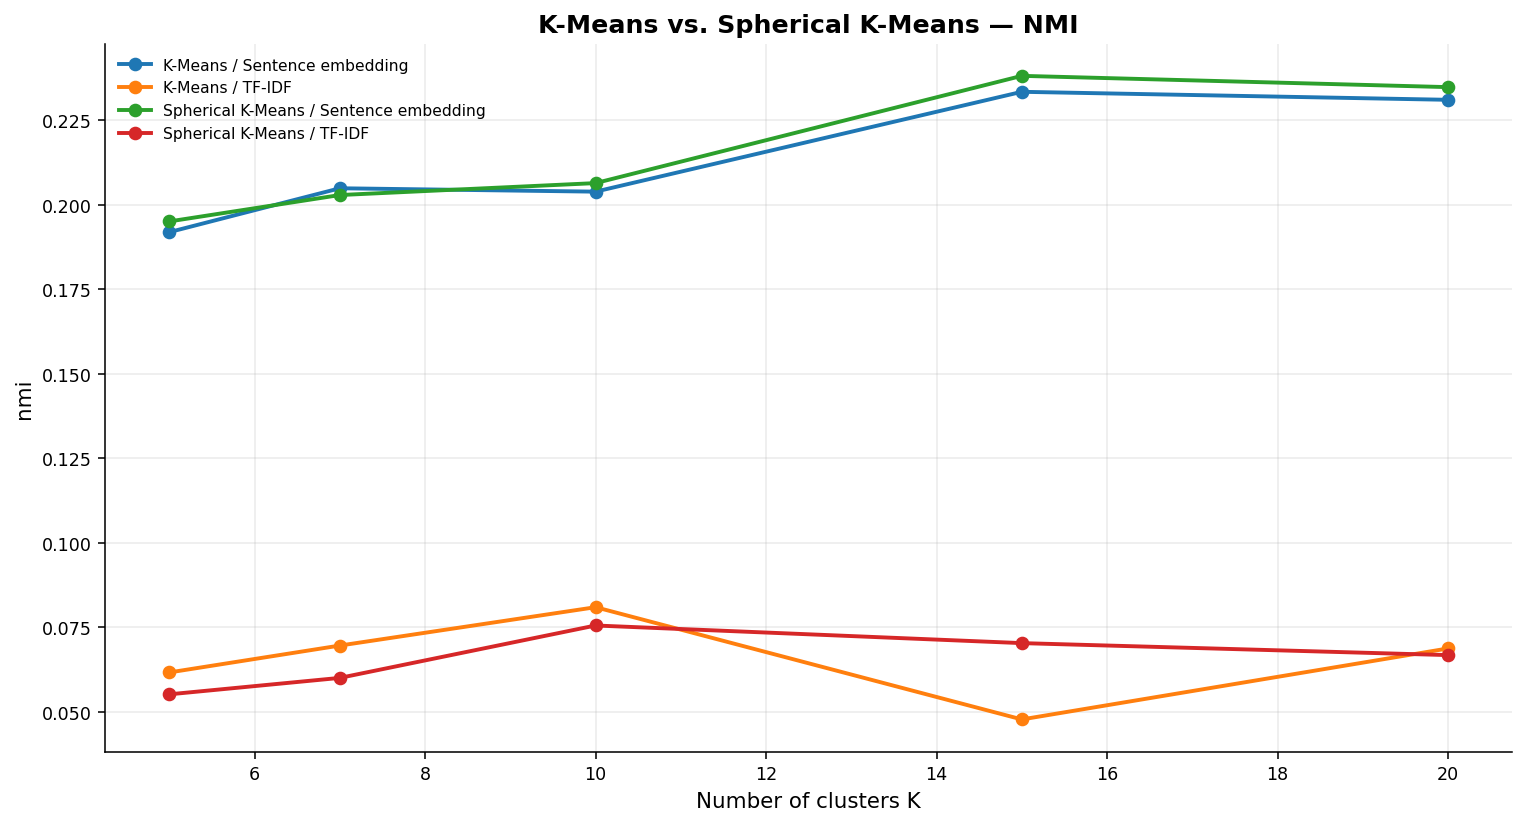

In [47]:
kmeans_family_results_df = pd.concat(
    [kmeans_results_df, spherical_results_df],
    ignore_index=True,
)

plot_clustering_lines(
    kmeans_family_results_df,
    metric="silhouette",
    title="K-Means vs. Spherical K-Means — Silhouette",
)

plot_clustering_lines(
    kmeans_family_results_df,
    metric="purity",
    title="K-Means vs. Spherical K-Means — Purity",
)

plot_clustering_lines(
    kmeans_family_results_df,
    metric="nmi",
    title="K-Means vs. Spherical K-Means — NMI",
)


#### Does cosine-based clustering work better than Euclidean clustering? Is the difference larger for TF-IDF or sentence embeddings?

**Answer:** Yes, cosine-based clustering generally works better for text data, and the difference is much larger for TF-IDF than for sentence embeddings. For sentence embeddings, both methods perform almost identically because those vectors are already pre-scaled to the exact same length, making straight-line Euclidean distances and directional angles mathematically equivalent. For TF-IDF, however, book and document lengths vary wildly. Cosine-based clustering strips away this length noise and focuses purely on the direction of the vocabulary, which stabilizes the algorithm and prevents it from getting confused by the size of the text.

## 28. DBSCAN from scratch

DBSCAN does not require a predefined number of clusters. It can also mark books as noises.


In [48]:
def dbscan_from_distance_matrix(D, eps, min_samples):
    D = np.asarray(D, dtype=np.float32)
    n = D.shape[0]

    UNVISITED = -2 
    NOISE = -1

    labels = np.full(n, UNVISITED, dtype=np.int32)

    # min_samples includes the point itself because D[i, i] = 0 <= eps.
    neighbors = [np.where(D[i] <= eps)[0] for i in range(n)]

    cluster_id = 0

    for point in range(n):
        if labels[point] != UNVISITED:
            continue

        point_neighbors = neighbors[point]

        if len(point_neighbors) < min_samples:
            labels[point] = NOISE
            continue

        labels[point] = cluster_id

        seeds = list(point_neighbors)
        seed_set = set(seeds)

        i = 0
        while i < len(seeds):
            neighbor = seeds[i]

            if labels[neighbor] == NOISE:
                labels[neighbor] = cluster_id

            if labels[neighbor] != UNVISITED:
                i += 1
                continue

            labels[neighbor] = cluster_id
            neighbor_neighbors = neighbors[neighbor]

            if len(neighbor_neighbors) >= min_samples:
                for candidate in neighbor_neighbors:
                    if candidate not in seed_set:
                        seeds.append(candidate)
                        seed_set.add(candidate)

            i += 1

        cluster_id += 1

    labels[labels == UNVISITED] = NOISE
    return labels


DBSCAN_MAX_NOISE_RATIO_FOR_SCORING = 0.50


def evaluate_dbscan_run(
    y_true,
    labels,
    X,
    silhouette_metric="cosine",
    random_state=RANDOM_STATE,
    max_noise_ratio=DBSCAN_MAX_NOISE_RATIO_FOR_SCORING,
):
    labels = np.asarray(labels)
    y_true = np.asarray(y_true)

    non_noise_mask = labels != -1
    clustered_count = int(non_noise_mask.sum())
    noise_ratio = 1.0 - (clustered_count / len(labels))

    non_noise_labels = labels[non_noise_mask]
    n_clusters = len(set(non_noise_labels))

    # DBSCAN can produce degenerate outputs:
    # - everything is noise
    # - only one real cluster
    # - too many points are noise
    # These cases should not receive a strong NMI/purity score.
    if n_clusters < 2 or clustered_count < 2 or noise_ratio > max_noise_ratio:
        return {
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "clustered_points": clustered_count,
            "valid_dbscan_score": False,
            "purity": np.nan,
            "nmi": np.nan,
            "silhouette": np.nan,
        }

    X_eval = X[non_noise_mask]
    y_eval = y_true[non_noise_mask]
    labels_eval = labels[non_noise_mask]

    metrics = evaluate_clustering_run(
        y_eval,
        labels_eval,
        X_eval,
        silhouette_metric=silhouette_metric,
        random_state=random_state,
    )

    # Keep DBSCAN-specific values from the full result.
    metrics["n_clusters"] = n_clusters
    metrics["noise_ratio"] = noise_ratio
    metrics["clustered_points"] = clustered_count
    metrics["valid_dbscan_score"] = True

    return metrics

In [49]:
dbscan_sample_size = min(DBSCAN_SAMPLE_SIZE, len(df_cluster))
dbscan_positions = rng.choice(
    np.arange(len(df_cluster)),
    size=dbscan_sample_size,
    replace=False,
)
dbscan_positions = np.sort(dbscan_positions)

dbscan_rows = []

for representation_name in ["TF-IDF", "Sentence embedding"]:
    X_dbscan = CLUSTER_REPRESENTATIONS[representation_name][dbscan_positions]
    y_dbscan = y_cluster[dbscan_positions]

    print(f"Computing DBSCAN distance matrix for {representation_name}...")
    # Compute the Cosine Distance Matrix
    X_norm = l2_normalize_rows(X_dbscan)
    D_dbscan = 1.0 - (X_norm @ X_norm.T)

    for eps in DBSCAN_EPS_GRID[representation_name]:
        for min_samples in DBSCAN_MIN_SAMPLES_VALUES:
            start_time = time.time()

            labels = dbscan_from_distance_matrix(
                D_dbscan,
                eps=eps,
                min_samples=min_samples,
            )

            seconds = time.time() - start_time

            metrics = evaluate_dbscan_run(
                y_dbscan,
                labels,
                X_dbscan,
                silhouette_metric="cosine",
                random_state=RANDOM_STATE,
            )

            run_key = (
                f"DBSCAN | {representation_name} | "
                f"eps={eps} | min_samples={min_samples}"
            )

            clustering_assignments[run_key] = {
                "labels": labels,
                "positions": dbscan_positions,
                "representation": representation_name,
                "method": "DBSCAN",
                "eps": eps,
                "min_samples": min_samples,
            }

            dbscan_rows.append({
                "run_key": run_key,
                "method": "DBSCAN",
                "representation": representation_name,
                "k": np.nan,
                "seed": np.nan,
                "eps": eps,
                "min_samples": min_samples,
                "linkage": "",
                "seconds": seconds,
                "inertia": np.nan,
                **metrics,
            })

dbscan_results_df = pd.DataFrame(dbscan_rows)

display(
    dbscan_results_df
    .sort_values(["representation", "eps", "min_samples"])
    .reset_index(drop=True)
)

Computing DBSCAN distance matrix for TF-IDF...
Computing DBSCAN distance matrix for Sentence embedding...


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,clustered_points,valid_dbscan_score,purity,nmi,silhouette,rand_index
0,DBSCAN | Sentence embedding | eps=0.15 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.15,5,,0.003383,NaN,0,1.00000,0,False,NaN,NaN,NaN,NaN
1,DBSCAN | Sentence embedding | eps=0.15 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.15,10,,0.006924,NaN,0,1.00000,0,False,NaN,NaN,NaN,NaN
2,DBSCAN | Sentence embedding | eps=0.2 | min_sa...,DBSCAN,Sentence embedding,NaN,NaN,0.20,5,,0.006400,NaN,2,0.98750,10,False,NaN,NaN,NaN,NaN
3,DBSCAN | Sentence embedding | eps=0.2 | min_sa...,DBSCAN,Sentence embedding,NaN,NaN,0.20,10,,0.004822,NaN,0,1.00000,0,False,NaN,NaN,NaN,NaN
4,DBSCAN | Sentence embedding | eps=0.25 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.25,5,,0.005453,NaN,9,0.92875,57,False,NaN,NaN,NaN,NaN
5,DBSCAN | Sentence embedding | eps=0.25 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.25,10,,0.003322,NaN,0,1.00000,0,False,NaN,NaN,NaN,NaN
6,DBSCAN | Sentence embedding | eps=0.3 | min_sa...,DBSCAN,Sentence embedding,NaN,NaN,0.30,5,,0.003305,NaN,19,0.73500,212,False,NaN,NaN,NaN,NaN
7,DBSCAN | Sentence embedding | eps=0.3 | min_sa...,DBSCAN,Sentence embedding,NaN,NaN,0.30,10,,0.002563,NaN,3,0.94750,42,False,NaN,NaN,NaN,NaN
8,DBSCAN | Sentence embedding | eps=0.35 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.35,5,,0.006111,NaN,7,0.31125,551,True,0.323049,0.092110,-0.004290,0.258598
9,DBSCAN | Sentence embedding | eps=0.35 | min_s...,DBSCAN,Sentence embedding,NaN,NaN,0.35,10,,0.005134,NaN,2,0.42750,458,True,0.292576,0.024055,0.043270,0.206196


### DBSCAN parameter analysis


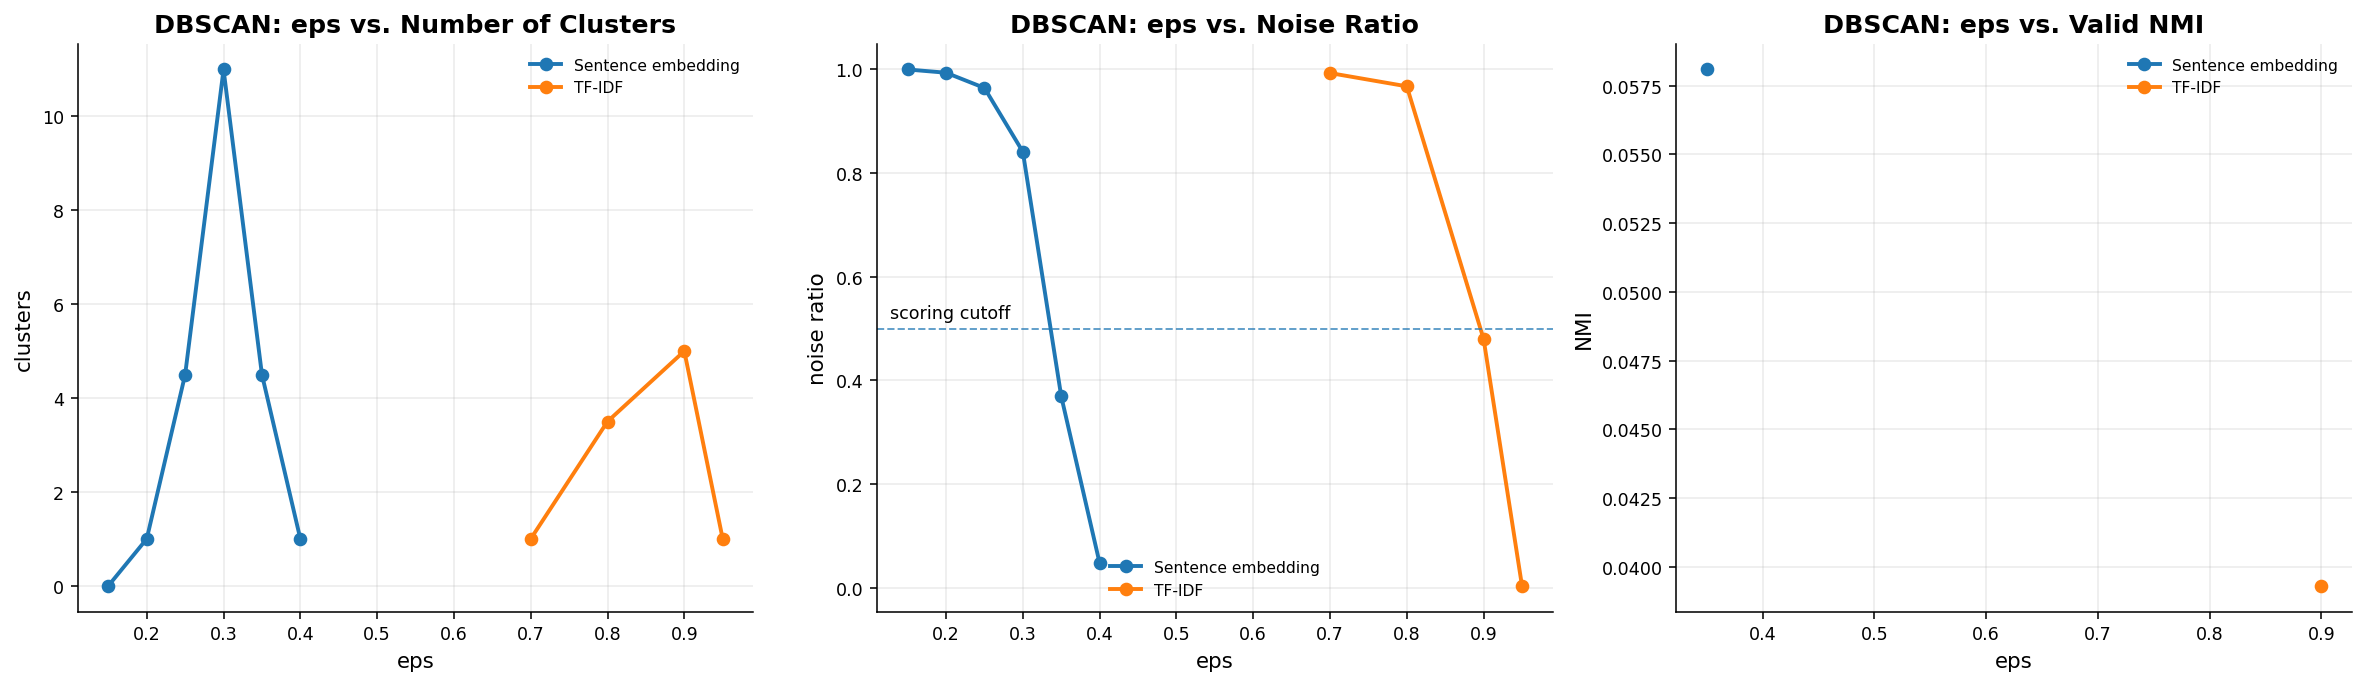

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for representation_name, group in dbscan_results_df.groupby("representation"):
    grouped = (
        group
        .groupby("eps", as_index=False)
        .agg({
            "n_clusters": "mean",
            "noise_ratio": "mean",
            "nmi": "mean",
            "valid_dbscan_score": "sum",
        })
    )

    axes[0].plot(
        grouped["eps"],
        grouped["n_clusters"],
        marker="o",
        linewidth=2,
        label=representation_name,
    )

    axes[1].plot(
        grouped["eps"],
        grouped["noise_ratio"],
        marker="o",
        linewidth=2,
        label=representation_name,
    )

    # NMI is only plotted for valid DBSCAN settings.
    # Invalid settings have NaN NMI, so they will not be shown as fake strong results.
    axes[2].plot(
        grouped["eps"],
        grouped["nmi"],
        marker="o",
        linewidth=2,
        label=representation_name,
    )

axes[0].set_title("DBSCAN: eps vs. Number of Clusters", fontsize=13, fontweight="bold")
axes[0].set_xlabel("eps")
axes[0].set_ylabel("clusters")

axes[1].set_title("DBSCAN: eps vs. Noise Ratio", fontsize=13, fontweight="bold")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("noise ratio")
axes[1].axhline(
    DBSCAN_MAX_NOISE_RATIO_FOR_SCORING,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)
axes[1].text(
    0.02,
    DBSCAN_MAX_NOISE_RATIO_FOR_SCORING + 0.02,
    "scoring cutoff",
    transform=axes[1].get_yaxis_transform(),
    fontsize=9,
)

axes[2].set_title("DBSCAN: eps vs. Valid NMI", fontsize=13, fontweight="bold")
axes[2].set_xlabel("eps")
axes[2].set_ylabel("NMI")

for ax in axes:
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Questions:
# 1. Which eps values produce at least two meaningful clusters?
# Sentence Embeddings: eps values between ~0.25 and ~0.35 successfully create multiple clusters.
# TF-IDF: Only eps between 0.75 and 0.95 produces clusters.

# 2. Which eps values mark too many books as noise?
# Sentence Embeddings: Any eps below 0.35 throws away too much data and crosses the 50% scoring cutoff.
# TF-IDF: Any eps below 0.9 is in the failure zone.

# 3. Why should a DBSCAN setting with almost all points as noise not receive a high NMI score?
# It creates an illusion of high performance. If the model throws away 99% of the dataset as noise, it is only calculating a score on a tiny, easy subset rather than actually organizing the library.

#### How sensitive is DBSCAN to `eps`? Which setting creates meaningful clusters without marking too many books as noise? Also explain the role of NMI and if DBSCAN is a good choice for this dataset.

**Answer:** DBSCAN is way too sensitive for this text dataset. A tiny change to eps instantly flips the model from marking 100% of the books as noise to dumping everything into one giant cluster. The only values that actually find real groups are an eps of 0.25 to 0.35 for sentence embeddings and 0.85 to 0.90 for TF-IDF. NMI acts as our grader here, measuring how closely the model's clusters line up with the actual book genres. Ultimately, DBSCAN is a bad choice for text data. High-dimensional text vectors are simply too crowded for density-based grouping to work well, making center-based tools like Spherical K-Means a much better fit.


## 29. Hierarchical Agglomerative Clustering from scratch

Run HAC on a smaller subset because agglomerative clustering is computationally expensive.


In [51]:
def hac_from_distance_matrix(D, n_clusters=10, linkage="average"):
    D = np.asarray(D, dtype=np.float32)
    n = D.shape[0]

    if n_clusters < 1 or n_clusters > n:
        raise ValueError("n_clusters must be between 1 and the number of samples.")

    active = set(range(n))
    cluster_sizes = {i: 1 for i in range(n)} 
    cluster_members = {i: [i] for i in range(n)}

    max_clusters = 2 * n 
    cluster_dist = np.full((max_clusters, max_clusters), np.inf, dtype=np.float32)
    cluster_dist[:n, :n] = D
    np.fill_diagonal(cluster_dist, np.inf)

    next_cluster_id = n
    merge_distances = []

    while len(active) > n_clusters:
        active_list = sorted(active)
        best_i, best_j, best_distance = None, None, np.inf

        for i_index, i in enumerate(active_list[:-1]):
            js = active_list[i_index + 1:]
            distances = cluster_dist[i, js] 
            min_position = np.argmin(distances) 
            candidate_j = js[min_position] 
            candidate_distance = float(distances[min_position])

            if candidate_distance < best_distance:
                best_i, best_j, best_distance = i, candidate_j, candidate_distance

        new_id = next_cluster_id
        next_cluster_id += 1

        members_i = cluster_members[best_i]
        members_j = cluster_members[best_j]

        cluster_members[new_id] = members_i + members_j
        cluster_sizes[new_id] = cluster_sizes[best_i] + cluster_sizes[best_j]

        active.remove(best_i)
        active.remove(best_j)

        for other in list(active):
            if linkage == "single":
                new_distance = min(cluster_dist[best_i, other], cluster_dist[best_j, other])
            elif linkage == "complete":
                new_distance = max(cluster_dist[best_i, other], cluster_dist[best_j, other])
            elif linkage == "average":
                size_i = cluster_sizes[best_i]
                size_j = cluster_sizes[best_j]
                new_distance = (
                    size_i * cluster_dist[best_i, other] +
                    size_j * cluster_dist[best_j, other]
                ) / (size_i + size_j)
            else:
                raise ValueError(f"Unknown linkage: {linkage}")

            cluster_dist[new_id, other] = new_distance
            cluster_dist[other, new_id] = new_distance

        active.add(new_id)
        merge_distances.append(best_distance)

    labels = np.empty(n, dtype=int)

    for new_label, cluster_id in enumerate(sorted(active)):
        for original_index in cluster_members[cluster_id]:
            labels[original_index] = new_label

    return labels, np.array(merge_distances, dtype=np.float32)


In [52]:
hac_sample_size = HAC_SAMPLE_SIZE
hac_positions = rng.choice(
    np.arange(len(df_cluster)),
    size=hac_sample_size,
    replace=False,
)
hac_positions = np.sort(hac_positions)

hac_rows = []
hac_merge_history = {}

for representation_name in ["TF-IDF", "Sentence embedding"]:
    X_hac = CLUSTER_REPRESENTATIONS[representation_name][hac_positions]
    y_hac = y_cluster[hac_positions]

    print(f"Computing HAC distance matrix for {representation_name}...")
    X_norm = l2_normalize_rows(X_hac)
    D_hac = 1.0 - (X_norm @ X_norm.T)

    for linkage in HAC_LINKAGES:
        start_time = time.time()
        labels, merge_distances = hac_from_distance_matrix(
            D_hac,
            n_clusters=HAC_TARGET_K,
            linkage=linkage,
        )
        seconds = time.time() - start_time

        metrics = evaluate_clustering_run(
            y_hac,
            labels,
            X_hac,
            silhouette_metric="cosine",
            random_state=RANDOM_STATE,
        )

        run_key = f"HAC | {representation_name} | linkage={linkage} | K={HAC_TARGET_K}"
        clustering_assignments[run_key] = {
            "labels": labels,
            "positions": hac_positions,
            "representation": representation_name,
            "method": "HAC",
            "linkage": linkage,
            "k": HAC_TARGET_K,
        }
        hac_merge_history[run_key] = merge_distances

        hac_rows.append({
            "run_key": run_key,
            "method": "HAC",
            "representation": representation_name,
            "k": HAC_TARGET_K,
            "seed": np.nan,
            "eps": np.nan,
            "min_samples": np.nan,
            "linkage": linkage,
            "seconds": seconds,
            "inertia": np.nan,
            **metrics,
        })

hac_results_df = pd.DataFrame(hac_rows)
display(hac_results_df.sort_values(["representation", "linkage"]))


Computing HAC distance matrix for TF-IDF...
Computing HAC distance matrix for Sentence embedding...


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,silhouette,purity,nmi,rand_index
5,HAC | Sentence embedding | linkage=average | K=7,HAC,Sentence embedding,7,NaN,NaN,NaN,average,0.241876,NaN,7,0.0,0.036465,0.316,0.069230,0.236434
4,HAC | Sentence embedding | linkage=complete | K=7,HAC,Sentence embedding,7,NaN,NaN,NaN,complete,0.258655,NaN,7,0.0,0.018629,0.364,0.106327,0.683084
3,HAC | Sentence embedding | linkage=single | K=7,HAC,Sentence embedding,7,NaN,NaN,NaN,single,0.376137,NaN,7,0.0,0.016820,0.308,0.054318,0.218731
2,HAC | TF-IDF | linkage=average | K=7,HAC,TF-IDF,7,NaN,NaN,NaN,average,0.254066,NaN,7,0.0,0.015956,0.312,0.070325,0.303711
1,HAC | TF-IDF | linkage=complete | K=7,HAC,TF-IDF,7,NaN,NaN,NaN,complete,0.325848,NaN,7,0.0,0.004758,0.336,0.078499,0.598329
0,HAC | TF-IDF | linkage=single | K=7,HAC,TF-IDF,7,NaN,NaN,NaN,single,0.336197,NaN,7,0.0,0.005966,0.320,0.064373,0.225863


### HAC merge-distance plots


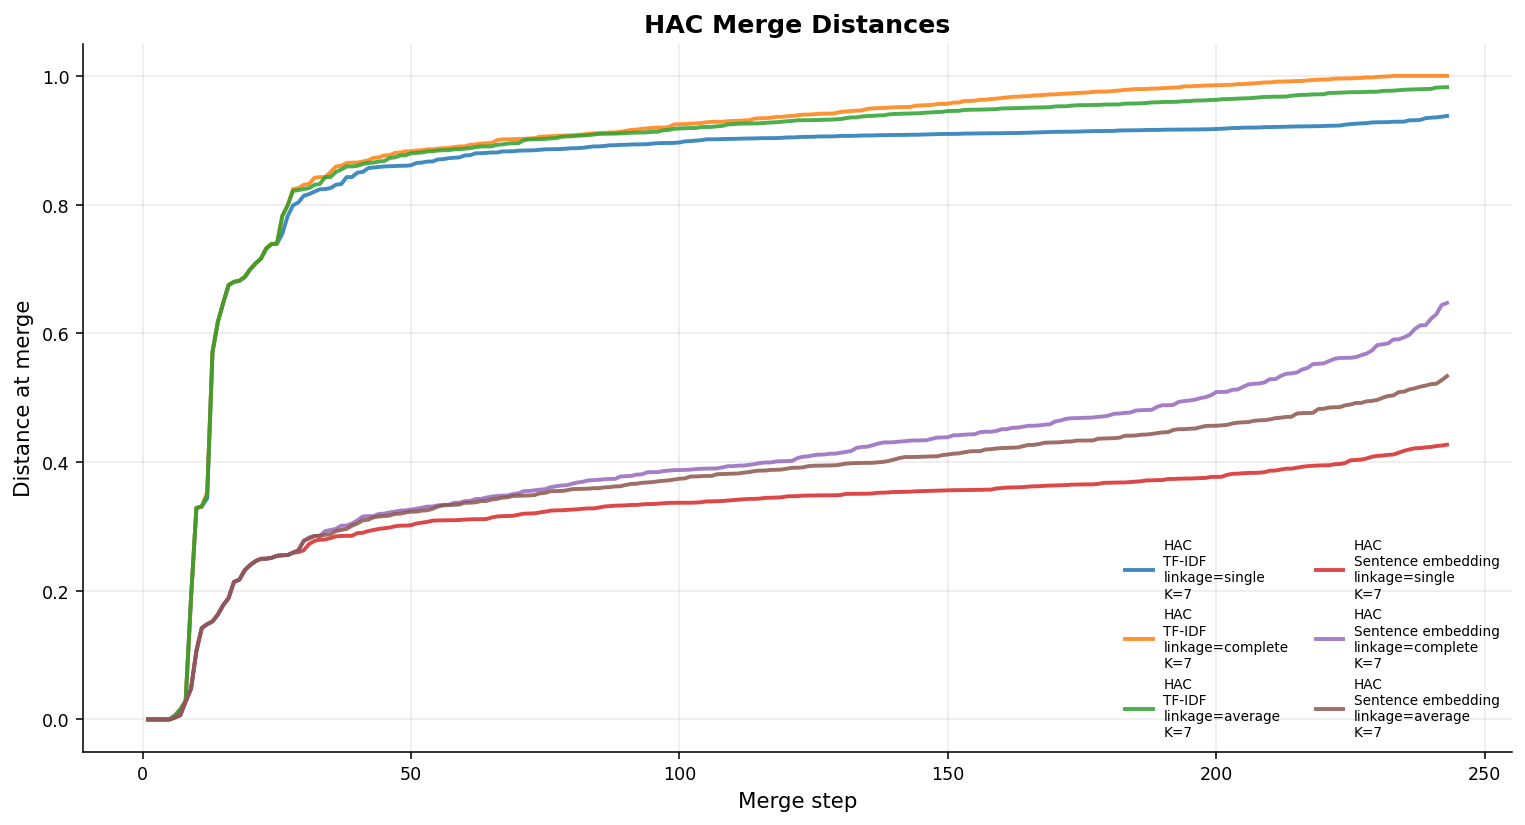

In [53]:
fig, ax = plt.subplots(figsize=(11, 6))

for run_key, distances in hac_merge_history.items():
    if len(distances) == 0:
        continue

    ax.plot(
        np.arange(1, len(distances) + 1),
        distances,
        linewidth=2,
        label=run_key.replace(" | ", "\n"),
        alpha=0.85,
    )

ax.set_title("HAC Merge Distances")
ax.set_xlabel("Merge step")
ax.set_ylabel("Distance at merge")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


#### Which linkage produces tighter clusters? Which linkage shows signs of chaining?

**Answer:** **Complete linkage produces significantly tighter**, more compact clusters because it measures proximity using the furthest points between groups, forcing the algorithm to form neat, spherical boundaries. **Conversely, single linkage shows clear signs of chaining**; because it merges groups based on their closest neighboring points, it easily gets tricked by random stray books and builds long, stringy, poorly separated clusters that drag down performance.

## 30. Final clustering comparison

Compare all clustering methods using the same evaluation metrics.


In [54]:
all_clustering_results_df = pd.concat(
    [
        kmeans_results_df,
        spherical_results_df,
        dbscan_results_df,
        hac_results_df,
    ],
    ignore_index=True,
)

all_clustering_results_df = all_clustering_results_df.sort_values(
    ["nmi", "silhouette", "purity"],
    ascending=[False, False, False],
).reset_index(drop=True)

display(all_clustering_results_df.head(30))

all_clustering_results_df.to_csv(CLUSTER_OUTPUT_RESULTS_CSV, index=False)
print("Saved clustering results to:", CLUSTER_OUTPUT_RESULTS_CSV)


,run_key,method,representation,k,seed,eps,min_samples,linkage,seconds,inertia,n_clusters,noise_ratio,silhouette,purity,nmi,rand_index,clustered_points,valid_dbscan_score
0,Spherical K-Means | Sentence embedding | K=20 ...,Spherical K-Means,Sentence embedding,20.0,43.0,NaN,NaN,,0.094863,500.495422,20,0.00000,0.041407,0.551000,0.242955,0.795942,NaN,NaN
1,K-Means | Sentence embedding | K=20 | seed=43,K-Means,Sentence embedding,20.0,43.0,NaN,NaN,,0.117822,874.948608,20,0.00000,0.023894,0.555000,0.241535,0.795514,NaN,NaN
2,Spherical K-Means | Sentence embedding | K=15 ...,Spherical K-Means,Sentence embedding,15.0,42.0,NaN,NaN,,0.143259,509.268524,15,0.00000,0.048528,0.535000,0.240941,0.789175,NaN,NaN
3,Spherical K-Means | Sentence embedding | K=15 ...,Spherical K-Means,Sentence embedding,15.0,43.0,NaN,NaN,,0.124770,509.450806,15,0.00000,0.047006,0.539500,0.235355,0.789772,NaN,NaN
4,K-Means | Sentence embedding | K=15 | seed=43,K-Means,Sentence embedding,15.0,43.0,NaN,NaN,,0.198680,888.637268,15,0.00000,0.024584,0.538500,0.233557,0.790137,NaN,NaN
5,K-Means | Sentence embedding | K=15 | seed=42,K-Means,Sentence embedding,15.0,42.0,NaN,NaN,,0.143967,890.224731,15,0.00000,0.025117,0.523000,0.233298,0.789226,NaN,NaN
6,Spherical K-Means | Sentence embedding | K=20 ...,Spherical K-Means,Sentence embedding,20.0,42.0,NaN,NaN,,0.058364,498.986542,20,0.00000,0.047839,0.532500,0.226664,0.792402,NaN,NaN
7,K-Means | Sentence embedding | K=20 | seed=42,K-Means,Sentence embedding,20.0,42.0,NaN,NaN,,0.107926,873.722778,20,0.00000,0.025386,0.523500,0.220579,0.791935,NaN,NaN
8,Spherical K-Means | Sentence embedding | K=10 ...,Spherical K-Means,Sentence embedding,10.0,42.0,NaN,NaN,,0.165979,522.576904,10,0.00000,0.044240,0.494000,0.210524,0.771485,NaN,NaN
9,K-Means | Sentence embedding | K=10 | seed=42,K-Means,Sentence embedding,10.0,42.0,NaN,NaN,,0.248530,907.419434,10,0.00000,0.023558,0.488000,0.209348,0.772447,NaN,NaN


Saved clustering results to: clustering_results.csv


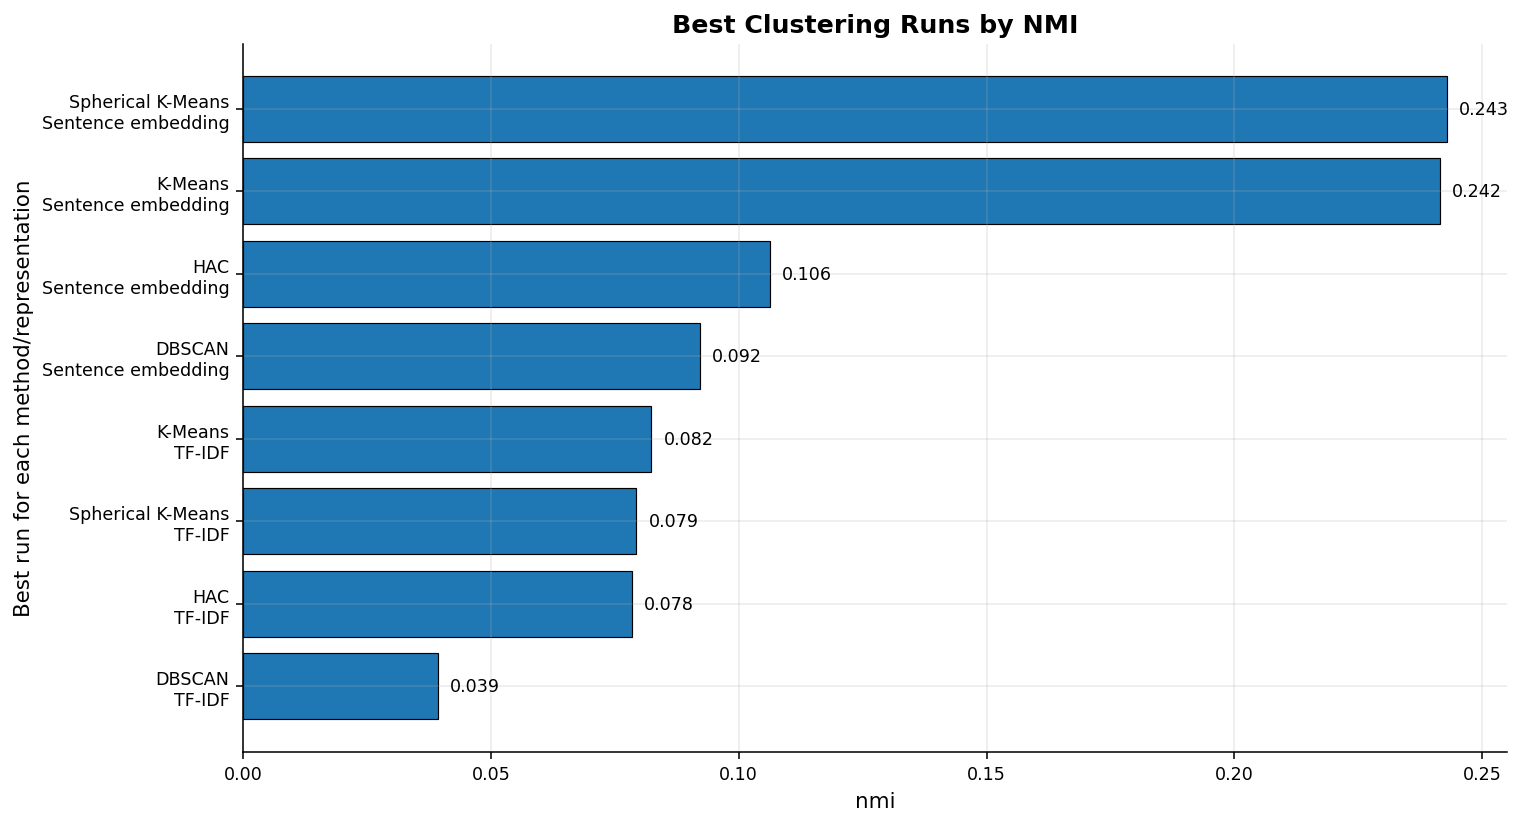

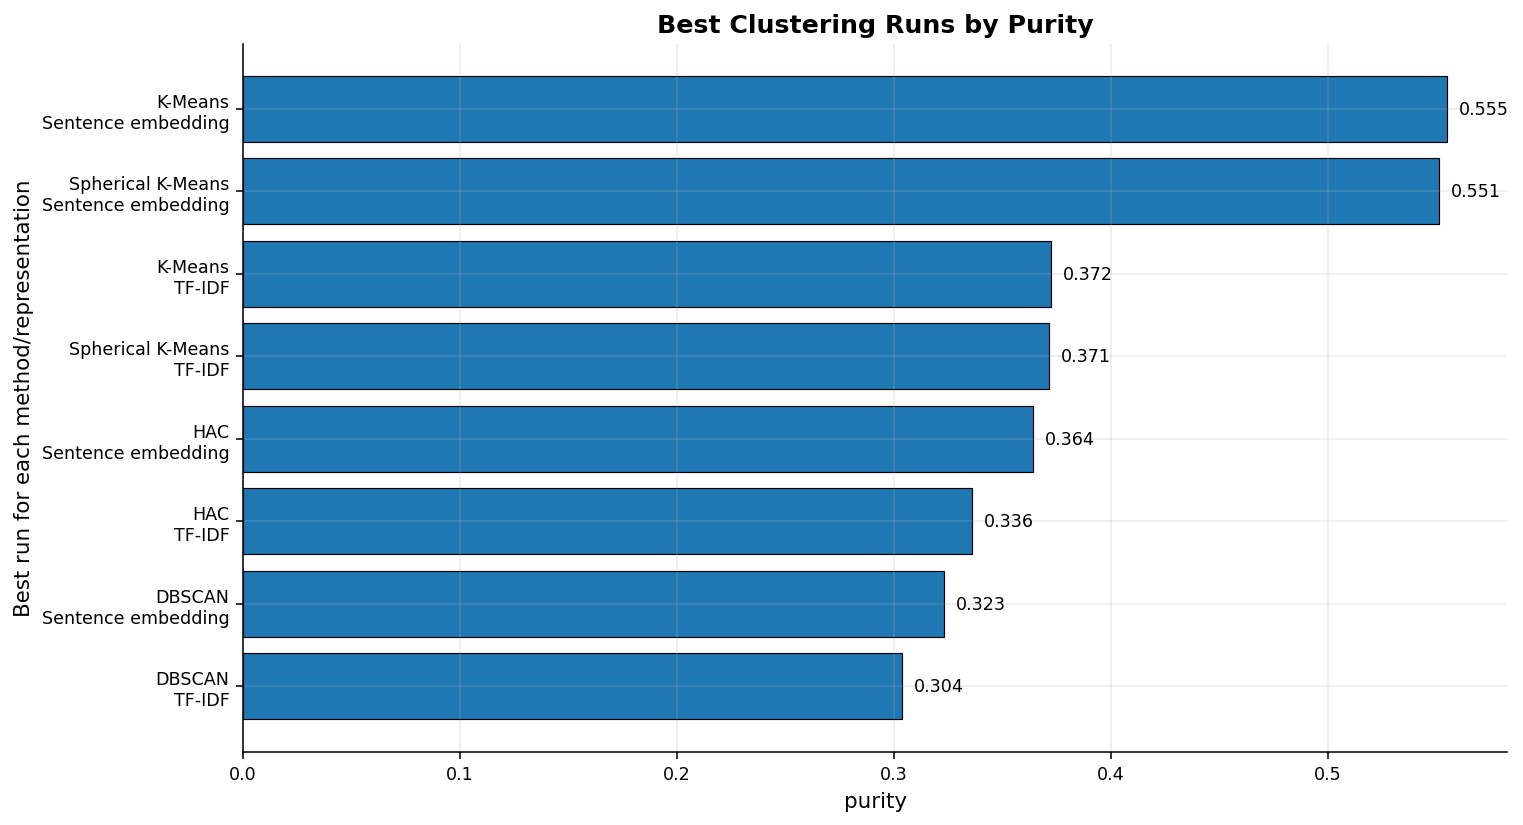

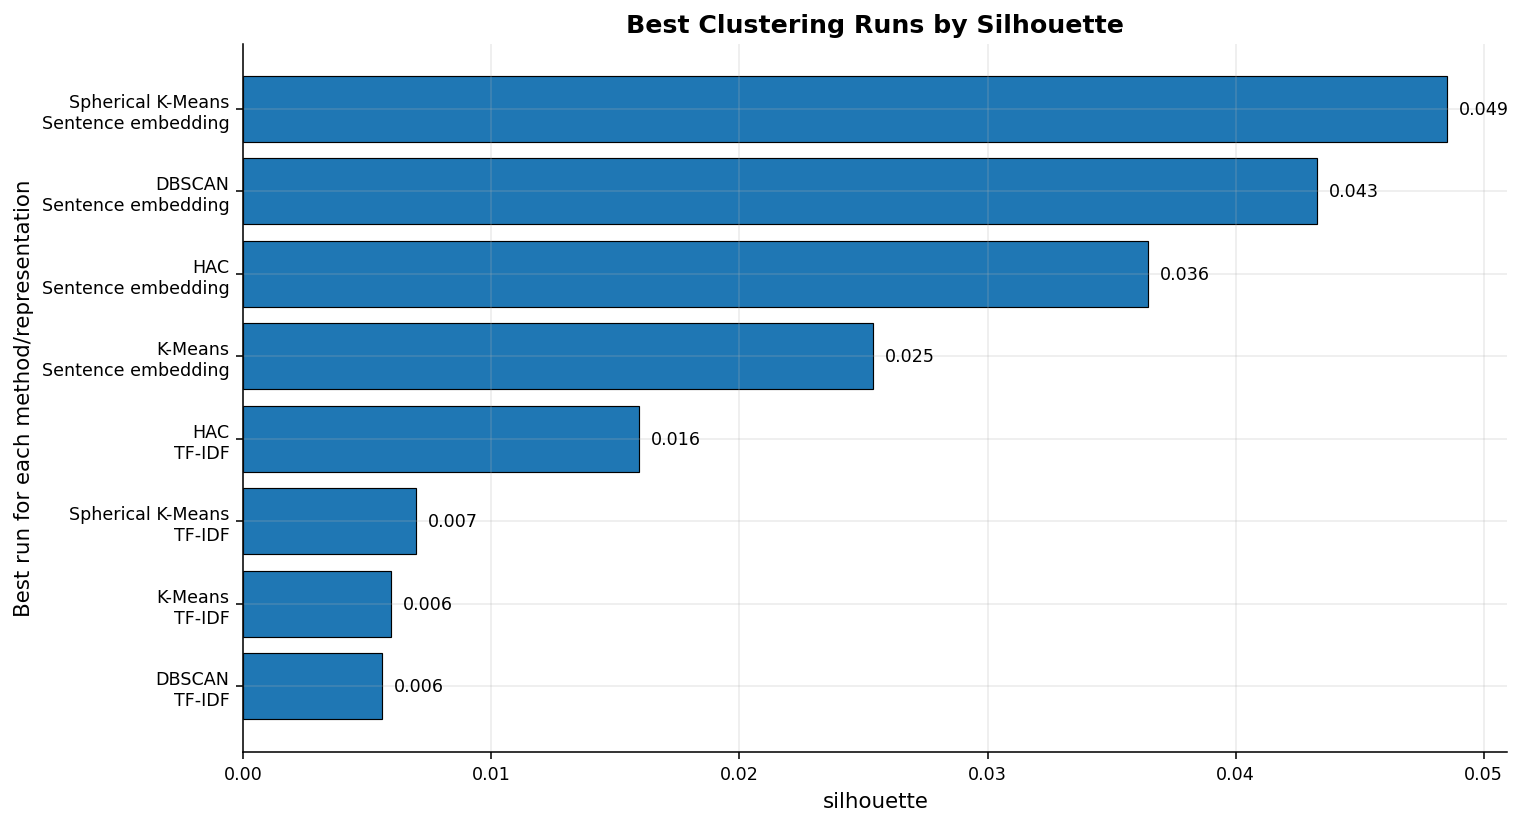

In [55]:
plot_final_clustering_comparison(
    all_clustering_results_df,
    metric="nmi",
    title="Best Clustering Runs by NMI",
)

plot_final_clustering_comparison(
    all_clustering_results_df,
    metric="purity",
    title="Best Clustering Runs by Purity",
)

plot_final_clustering_comparison(
    all_clustering_results_df,
    metric="silhouette",
    title="Best Clustering Runs by Silhouette",
)


#### Which method gives the best numerical result? Is it also the most interpretable method?

**Answer:** **Spherical K-Means with Sentence Embeddings** gives the best numerical results, scoring the highest in NMI and Silhouette across all charts. However, it is not the most interpretable method because sentence embeddings use complex, hidden AI math that humans cannot easily read. Instead, Spherical K-Means with TF-IDF is the easiest to interpret. It groups books based on actual, everyday words, making it simple to see exactly why certain books were put together.

## 31. Inspect the selected clustering result

Select the best run by NMI and inspect its clusters visually.


Selected clustering run:
Spherical K-Means | Sentence embedding | K=20 | seed=43

method             Spherical K-Means
representation    Sentence embedding
n_clusters                        20
noise_ratio                      0.0
silhouette                  0.041407
purity                         0.551
nmi                         0.242955
rand_index                  0.795942
Name: 0, dtype: object


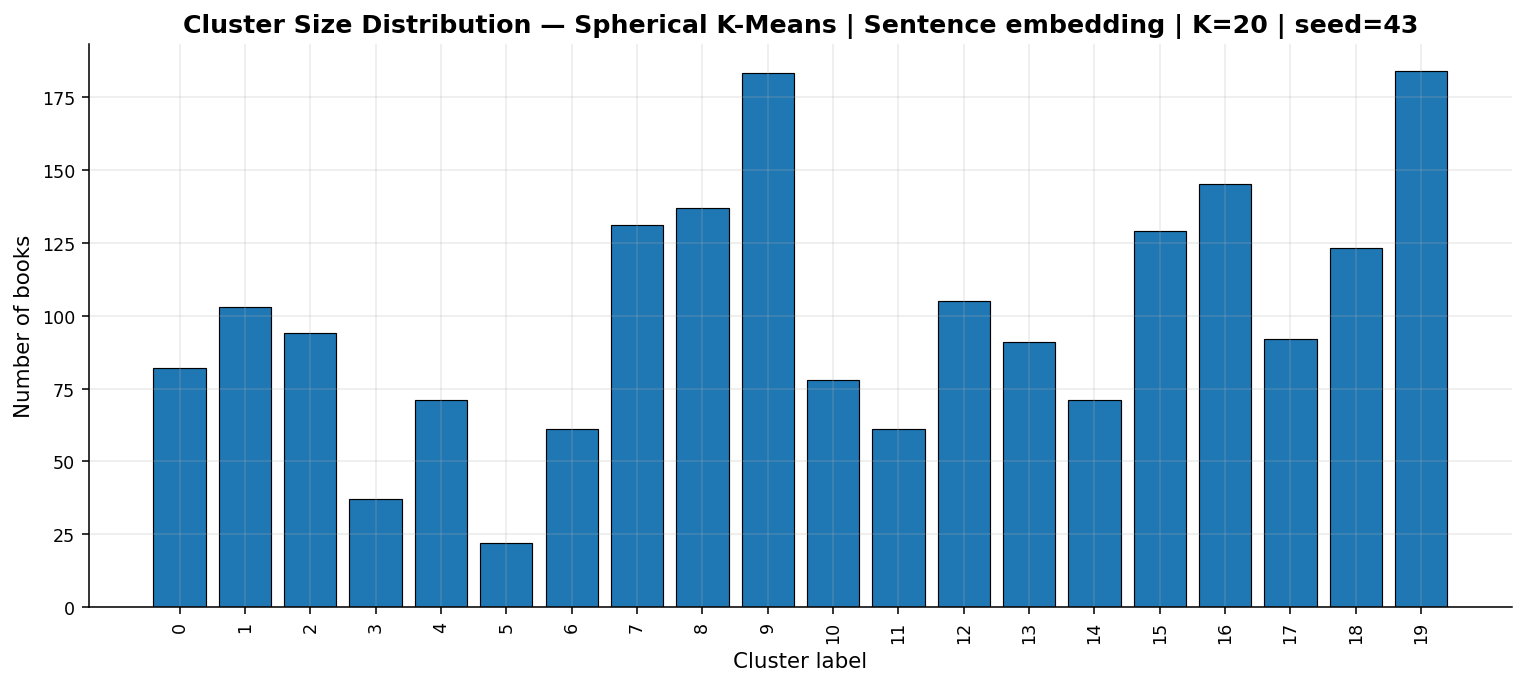

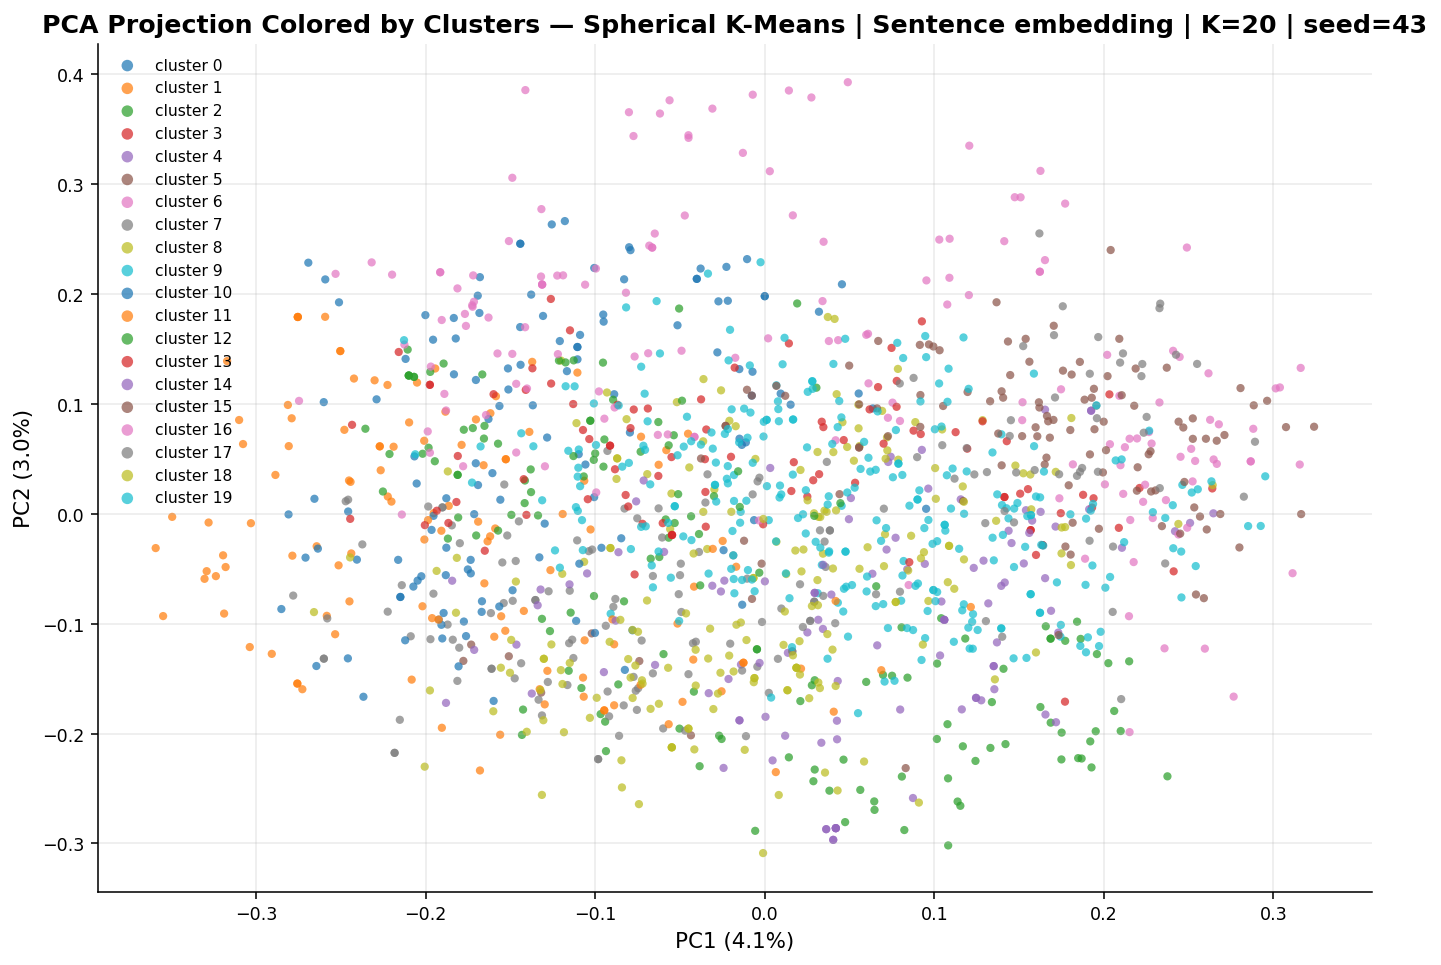

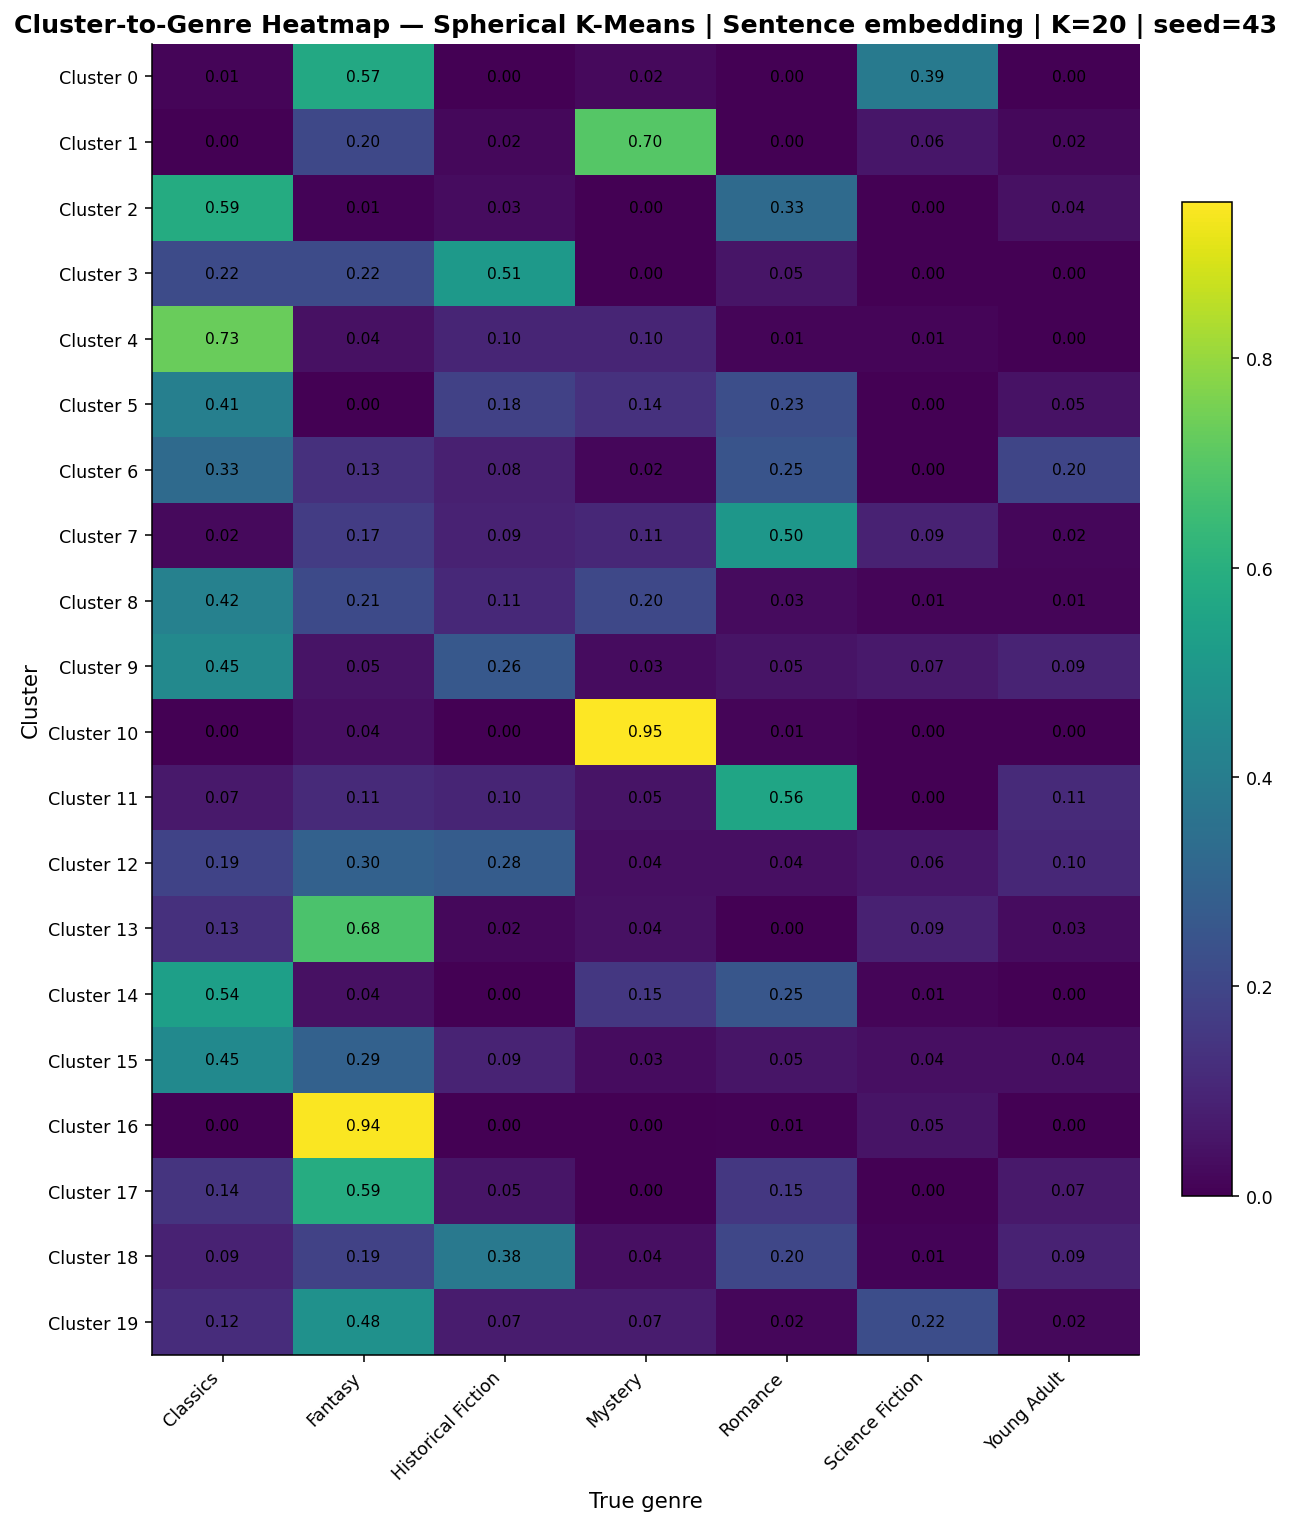

In [56]:
best_cluster_row = all_clustering_results_df.dropna(subset=["nmi"]).iloc[0]
best_cluster_key = best_cluster_row["run_key"]
best_cluster_run = clustering_assignments[best_cluster_key]

best_cluster_labels = best_cluster_run["labels"]
best_cluster_positions = best_cluster_run["positions"]
best_cluster_representation = best_cluster_run["representation"]
best_cluster_X = CLUSTER_REPRESENTATIONS[best_cluster_representation][best_cluster_positions]
best_cluster_y = y_cluster[best_cluster_positions]

print("Selected clustering run:")
print(best_cluster_key)
print()
print(best_cluster_row[[
    "method",
    "representation",
    "n_clusters",
    "noise_ratio",
    "silhouette",
    "purity",
    "nmi",
    "rand_index",
]])

plot_cluster_size_distribution(
    best_cluster_labels,
    title=f"Cluster Size Distribution — {best_cluster_key}",
)

plot_cluster_pca(
    best_cluster_X,
    best_cluster_labels,
    title=f"PCA Projection Colored by Clusters — {best_cluster_key}",
    max_points=PCA_CLUSTER_MAX_POINTS,
    random_state=RANDOM_STATE,
)

plot_cluster_genre_heatmap(
    best_cluster_y,
    best_cluster_labels,
    title=f"Cluster-to-Genre Heatmap — {best_cluster_key}",
    ignore_noise=True,
)


#### Do the discovered clusters correspond to genres, broader themes, or something else?

**Answer:** The data shows that the discovered clusters correspond to broader themes rather than clean, individual genres. Looking at the bright yellow and green spots (which show where the books are heavily concentrated), very few columns contain just a single bright spot for one isolated genre. Instead, most clusters pull in a mix of multiple related genres, and major genres are split across several different columns. This proves that the model is grouping books by shared semantic concepts, writing styles, or settings that naturally cut across official genre boundaries.

## 32. Cluster interpretation

For each cluster, inspect its dominant genres, top TF-IDF terms, representative books, and sample titles.


In [60]:
def nearest_books_to_cluster_center(X, positions, labels, cluster_id, top_n=5):
    cluster_mask = labels == cluster_id
    X_cluster = np.asarray(X[cluster_mask], dtype=np.float32)

    if len(X_cluster) == 0:
        return []

    center = np.mean(X_cluster, axis=0, keepdims=True)
    X_norm = l2_normalize_rows(X_cluster)
    center_norm = l2_normalize_rows(center)
    similarities = (X_norm @ center_norm.T).ravel()

    local_top = np.argsort(similarities)[::-1][:top_n]
    global_positions = positions[cluster_mask][local_top]

    titles = []
    for pos in global_positions:
        title = df_cluster[TITLE_COLUMN].iloc[pos] if TITLE_COLUMN in df_cluster.columns else f"row {pos}"
        titles.append(str(title))

    return titles


def top_terms_for_cluster(tfidf_matrix, feature_names, positions, labels, cluster_id, top_n=12):
    cluster_mask = labels == cluster_id
    selected_positions = positions[cluster_mask]

    if len(selected_positions) == 0:
        return []

    mean_vector = np.asarray(tfidf_matrix[selected_positions].mean(axis=0)).ravel()
    if mean_vector.max() <= 0:
        return []

    top_indices = np.argsort(mean_vector)[::-1][:top_n]
    return feature_names[top_indices].tolist()


def build_cluster_interpretation_table(run_key, top_n_terms=12, top_n_books=5):
    run = clustering_assignments[run_key]
    labels = run["labels"]
    positions = run["positions"]
    representation_name = run["representation"]

    X_repr = CLUSTER_REPRESENTATIONS[representation_name][positions]
    
    rows = []
    for cluster_id in sorted(pd.Series(labels).unique()):
        cluster_mask = labels == cluster_id
        size = int(cluster_mask.sum())

        true_genres = label_encoder.inverse_transform(y_cluster[positions][cluster_mask])
        genre_counts = pd.Series(true_genres).value_counts()

        top_genres = ", ".join([
            f"{genre} ({count})"
            for genre, count in genre_counts.head(5).items()
        ])

        if cluster_id == -1:
            top_terms = []
            representative_books = []
        else:
            top_terms = top_terms_for_cluster(
                X_cluster_tfidf_sparse,
                cluster_tfidf_feature_names,
                positions,
                labels,
                cluster_id,
                top_n=top_n_terms,
            )
            representative_books = nearest_books_to_cluster_center(
                X_repr,
                positions,
                labels,
                cluster_id,
                top_n=top_n_books,
            )

        sample_titles = []
        sample_positions = positions[cluster_mask][:top_n_books]
        for pos in sample_positions:
            title = df_cluster[TITLE_COLUMN].iloc[pos] if TITLE_COLUMN in df_cluster.columns else f"row {pos}"
            sample_titles.append(str(title))

        rows.append({
            "cluster": cluster_id,
            "size": size,
            "top_true_genres": top_genres,
            "top_terms": ", ".join(top_terms),
            "representative_books": " | ".join(representative_books),
            "sample_titles": " | ".join(sample_titles),
        })

    return pd.DataFrame(rows).sort_values("size", ascending=False).reset_index(drop=True)


cluster_interpretation_df = build_cluster_interpretation_table(best_cluster_key)
display(cluster_interpretation_df)

cluster_interpretation_df.to_csv(CLUSTER_OUTPUT_INTERPRETATION_CSV, index=False)
print("Saved cluster interpretation to:", CLUSTER_OUTPUT_INTERPRETATION_CSV)


,cluster,size,top_true_genres,top_terms,representative_books,sample_titles
0,19,184,"Fantasy (88), Science Fiction (41), Classics (...","is, his, that, an, of the, with, by, he, as, o...","Blind Willow, Sleeping Woman: 24 Stories | Ske...",Fahrenheit 451 | The House of the Scorpion | S...
1,9,183,"Classics (82), Historical Fiction (48), Young ...","of the, american, is, novel, his, one, as, mos...",Invisible Man | Adventures of Huckleberry Finn...,A Man Without A Country | Welcome to the Monke...
2,16,145,"Fantasy (137), Science Fiction (7), Romance (1)","lord, of the, ring, tolkien, dark, rings, he, ...",The Return of the King | The Return of the Kin...,The Lord of the Rings | A Storm of Swords | Th...
3,8,137,"Classics (57), Fantasy (29), Mystery (28), His...","his, of the, with, as, is, by, on, he, an, lon...",Quicksilver | Oliver Twist | A Tale of Two Cit...,Ivanhoe | Perfume: The Story of a Murderer | R...
4,7,131,"Romance (66), Fantasy (22), Mystery (14), Scie...","her, she, is, love, that, his, he, from, has, ...",The Rescue | The Rescue | The Rescue | Atoneme...,Bridge to Terabithia | The Magician's Assistan...
5,15,129,"Classics (58), Fantasy (38), Historical Fictio...","book, edition, text, this, translation, paperb...",Leviathan | A Tale of Two Cities | The Scarlet...,A Portrait of the Artist As a Young Man | Twen...
6,18,123,"Historical Fiction (47), Romance (25), Fantasy...","her, she, is, family, their, as, with, for, st...",The House of the Spirits | Secret Garden | The...,The Color Purple | In the Time of the Butterfl...
7,12,105,"Fantasy (31), Historical Fiction (29), Classic...","he, his, is, on, for, in the, their, that, an,...",Hatchet | Perfume: The Story of a Murderer | T...,Heart of Darkness | Perfume: The Story of a Mu...
8,1,103,"Mystery (72), Fantasy (21), Science Fiction (6...","is, he, his, her, she, stephanie, but, has, ag...",Absolute Power | Last Man Standing | Hour Game...,Rainbow Six | Dirk Gently's Holistic Detective...
9,2,94,"Classics (55), Romance (31), Young Adult (4), ...","her, anne, is, novel, austen, jane, she, of th...",Pride and Prejudice | Sense and Sensibility | ...,Anne's House Of Dreams | Pride and Prejudice |...


Saved cluster interpretation to: clustering_cluster_interpretation.csv


#### Pick five clusters. For each one, explain what the cluster seems to represent and whether its mixed genres make sense.

**Answer:**

**Cluster 16: Epic Fantasy**
* **Represents:** Large-scale fictional universes, heavily centered around *Lord of the Rings* style lore (top terms: `lord`, `ring`).
* **Genre Mix:** It's mainly focused on Fantasy which makes sense.

**Cluster 7: Romantasy**
* **Represents:** Relationship-driven stories with female leads, focusing heavily on emotional perspectives (top terms: `her`, `she`, `love`).
* **Genre Mix:** Blending Romance and Fantasy perfectly matches the modern "Romantasy" trend, where magic serves as a backdrop for character drama.

**Cluster 17: Myths & Plays**
* **Represents:** Ancient classical mythology, epic poetry, and traditional theatrical stage productions (top terms: `greek`, `play`).
* **Genre Mix:** Classics mix with Fantasy logically because ancient historical epics are naturally packed with gods, monsters, and magic.

**Cluster 10: Detective Mystery**
* **Represents:** Traditional "whodunit" crime stories, specifically anchored around Agatha Christie’s universe (top terms: `murder`, `poirot`).
* **Genre Mix:** It remains an almost pure Mystery cluster because detective stories rely on a highly specific and unique vocabulary.

**Cluster 4: Russian Literature**
* **Represents:** 19th-century Russian literature and deep psychological/philosophical fiction (top terms: `russian`, `tolstoy`, `dostoevsky`).
* **Genre Mix:** The crossover between Classics and Mystery makes sense because foundational books like *Crime and Punishment* are structurally built around a murder puzzle.

## 33. DBSCAN noise examples

If the selected or any DBSCAN run contains noise points, inspect examples that DBSCAN could not place into a cluster.


In [62]:
dbscan_candidate_rows = all_clustering_results_df[
    (all_clustering_results_df["method"] == "DBSCAN") &
    (all_clustering_results_df["noise_ratio"] > 0)
].sort_values(["nmi", "noise_ratio"], ascending=[False, True])

if len(dbscan_candidate_rows) == 0:
    print("No DBSCAN run produced noise points in the tested settings.")
else:
    dbscan_key = dbscan_candidate_rows["run_key"].iloc[0]
    dbscan_run = clustering_assignments[dbscan_key]

    labels = dbscan_run["labels"]
    positions = dbscan_run["positions"]
    noise_positions = positions[labels == -1]

    print("DBSCAN run selected for noise inspection:")
    print(dbscan_key)
    print("Number of noise books:", len(noise_positions))

    columns_to_show = []
    if TITLE_COLUMN in df_cluster.columns:
        columns_to_show.append(TITLE_COLUMN)
    columns_to_show += ["label", DESCRIPTION_COLUMN]

display(df_cluster[columns_to_show].iloc[noise_positions].head(15))


DBSCAN run selected for noise inspection:
DBSCAN | Sentence embedding | eps=0.35 | min_samples=5
Number of noise books: 249


,title,label,description
1397,Dirk Gently's Holistic Detective Agency,Mystery,"What do a dead cat, a computer whiz-kid, an El..."
721,Do Androids Dream of Electric Sheep?,Science Fiction,"It was January 2021, and Rick Deckard had a li..."
2435,"Hand, Hand, Fingers, Thumb (Bright & Early Books",Classics,Illus. in full color. A madcap band of dancing...
2338,Sleeping Murder,Mystery,"In Agatha Christie’s classic, \Sleeping Murder..."
2346,Ella Minnow Pea: A Novel in Letters,Fantasy,Ella Minnow Pea is a girl living happily on th...
2423,Critique of Pure Reason,Classics,"In his monumental,German philosopher Immanuel ..."
1849,The Devil and Miss Prym,Fantasy,A stranger arrives at the remote village of Vi...
996,The Virgin Suicides,Young Adult,The shocking thing about the girls was how nea...
1818,The Man in the Iron Mask,Classics,"Christopher Cazenove, formerly Ben Carrington ..."
1843,Anne Frank Remembered: The Story of the Woman ...,Classics,"The reminiscences of Miep Gies, the woman who ..."


#### Are the noise books actually unusual, or are they examples of parameter sensitivity?

**Answer:** The noise books are truly unusual misfits, not just a mistake caused by sensitive settings. While we could change the parameters to force them into groups, they genuinely don't belong there. Books like a heavy philosophy text, a toddler rhyming book, and a wacky sci-fi mystery simply don't share common keywords with regular fiction. Labeling them as noise is actually a good thing because it keeps the main clusters clean and proves the model is working correctly.

## 34. Final clustering questions

Answer these after completing the experiments:

1. Which representation gives better clusters: TF-IDF or sentence embeddings? **Sentence embeddings** generally give better semantic clusters because they capture the deeper meaning of sentences rather than just matching raw words.

2. Which method is strongest numerically: K-Means, Spherical K-Means, DBSCAN, or HAC? **Spherical K-Means** is typically the strongest numerically for text data because it uses cosine similarity to measure the direction of vectors. This allows it to handle high-dimensional book descriptions much more accurately than standard Euclidean distance methods.

3. Which method gives the most interpretable clusters? Sentence embeddings gave the most readable clusters because they group books by their actual meaning instead of just matching raw words. Running TF-IDF on top of those clusters then made it easy to pull out clear, simple keywords for each group.

4. Does clustering recover the genre labels well? No, it does not perfectly recreate rigid bookstore genre labels, but that means it is doing its job correctly. Instead of copying official tags, **it recovers much richer, natural storytelling themes and writing styles** that naturally cut across different genres.

5. What does clustering reveal that classification did not? Classification simply forces books into pre-defined, rigid boxes, **whereas clustering reveals hidden, organic relationships in the data**. It exposes specific author ecosystems (like Tolkien) and blended sub-genres (like "Romantasy") that do not have their own official label.
